
# 第 2 章 贝叶斯模型的探索性分析
***

在第 1 章中我们看到,贝叶斯推断就是把模型与手头数据关联起来,并得到后验分布。这件事既可以
用纸笔完成,也可以借助计算机或其他工具完成。此外,作为推断过程的一部分,我们还可以计算先验
预测分布、后验预测分布等其他量。然而,贝叶斯建模所涵盖的内容,远比"推断"本身要宽广。如果
贝叶斯建模真的像"写出模型 → 算出后验"这么简单就好了,但现实往往并非如此——要做出成功的
贝叶斯数据分析,还需要完成许多同样重要的任务。本章会讨论其中的一些任务,包括检查模型假设、
诊断推断结果,以及模型比较。

## 推断之后(以及之前)也大有可为!

一次成功的贝叶斯建模实践,需要在推断之外完成额外的工作,比如:

- 诊断用数值方法得到的推断结果的质量。
- 模型批判(model criticism),包括对模型假设和模型预测两方面的评估。
- 模型比较,包括模型选择或模型平均。
- 为特定受众准备、呈现结果。

这些任务都需要数值和可视化两方面的汇总,来帮助实践者分析自己的模型。我们把这些任务统称为
**贝叶斯模型的探索性分析(Exploratory Analysis of Bayesian Models)**,这个名字借用自统计学
中"探索性数据分析(Exploratory Data Analysis, EDA)"这一方法论。EDA 致力于总结数据集的主要
特征,常常借助可视化手段。用统计学家 Persi Diaconis 的话说:

> 探索性数据分析(EDA)旨在揭示数据中的结构或简单的描述。我们观察数字或图形,试图发现
> 规律。我们会顺着背景信息、想象力、观察到的规律以及其他数据分析经验所提示的线索继续深挖。

EDA 通常在推断步骤**之前**进行,有时甚至可以**取代**推断步骤。我们和许多前人一样,认为
EDA 中的很多思想可以被借用、重新诠释,并拓展成一套稳健的贝叶斯建模方法。本书主要会用 Python
库 ArviZ 来帮助我们对贝叶斯模型做探索性分析。

在真实场景下,贝叶斯推断和贝叶斯模型的探索性分析会交织成一个迭代的工作流,其中充满了愚蠢的
代码错误、计算问题、对模型是否恰当的疑虑、对数据理解是否到位的疑虑、非线性的建模过程、模型
检查等等。要在一本书里完整还原这种错综复杂的工作流是很有挑战性的。因此在本书接下来的篇幅中,
我们有时会省略部分甚至全部的探索性分析步骤,或者把它们留作练习。这并不是因为它们不必要或不
重要——恰恰相反,在写作本书的过程中,我们在"幕后"做了大量这样的迭代。只是在某些地方我们
选择省略它们,以便把注意力集中在模型细节、计算特性或基础数学等其他相关内容上。

## 理解你的假设

正如前一章讨论过的,"最好的先验是什么"是一个很诱人的问题,但很难给出令人满意的直接答案,
只能说"看情况"。我们当然可以为某个模型(或某一族模型)找到默认先验,使其在广泛的数据集上
都表现不错。但如果我们能为某个具体问题构造更有信息量的先验,往往也能找到胜过默认先验的做法。
好的默认先验既可以直接用于快速/默认分析,也可以作为占位符,留待我们投入时间精力、进入迭代式
探索性贝叶斯建模工作流时再替换成更好的先验。

选择先验时会遇到的一个问题是:先验通过模型传播到数据之后产生的效果,常常很难直观理解。我们
在参数空间里做出的选择,可能会在可观测的数据空间里引发意想不到的结果。理解这类假设的一个
很有用的工具,就是我们在第 1 章介绍过的**先验预测分布**。实践中,我们可以通过对模型采样、
但不对观测数据做条件化,来计算先验预测分布。通过对先验预测分布采样,计算机替我们完成了"把
参数空间里的选择翻译成观测数据空间里的样本"这项工作。用这些样本来评估先验,就是所谓的
**先验预测检验(prior predictive checks)**。

假设我们想为足球(美国人叫 soccer)建一个模型,具体来说是想搞清楚点球命中的概率。想了一会儿
之后,我们决定用一个几何模型 [^4]。参照罚点球的示意图,再加上一点三角学知识,可以得到如下
命中概率公式:

$$
p\left(|\alpha| < \tan^{-1}\left(\frac{L}{x}\right)\right) = 2\Phi\left(\frac{\tan^{-1}\left(\frac{L}{x}\right)}{\sigma}\right) - 1
$$

这个公式背后的直觉是:我们假设进球概率,由角度 $\alpha$ 的绝对值小于某个阈值
$\tan^{-1}\left(\frac{L}{x}\right)$ 的概率给出。此外我们假设球员本来是想把球笔直踢出去,
也就是踢出零角度,但会有其他各种因素导致实际弹道出现偏差 $\sigma$。图中 $x$ 是点球的
规定距离(11 米),$L$ 是球门宽度的一半(3.66 米)。

公式中唯一未知的量是 $\sigma$。$L$ 和 $x$ 可以直接从足球规则中获得。身为优秀的贝叶斯主义者,
遇到未知量,我们就给它指定一个先验,然后尝试搭建一个贝叶斯模型,比如可以这样写:

$$
\begin{split}
\sigma &\sim \mathcal{HN}(\sigma_{\sigma}) \\
\text{p\_goal} &= 2\Phi\left(\frac{\tan^{-1}\left(\frac{L}{x}\right)}{\sigma}\right) - 1 \\
Y &\sim \text{Bin}(n=1, p=\text{p\_goal})
\end{split}
$$

这时候我们还不确定这个模型对足球领域知识的编码效果如何,于是决定先从先验预测分布中采样,
获得一些直观感受。下图展示了 3 种先验(即 $\sigma_{\sigma}$ 分别取 5、20、60 度)对应的结果。
灰色扇形区域代表:假设球员把球踢得完全笔直、且不考虑风、摩擦等其他因素时,能够进球的角度
范围。我们可以看到,即便球员踢出的角度比灰色区域更大,模型依然认为有可能进球。有意思的是,
当 $\sigma_{\sigma}$ 较大时,模型甚至认为往反方向踢也不是太糟糕的主意。


In [1]:
%matplotlib inline
import os

import arviz as az
import matplotlib.pyplot as plt
import numpy as np
import pymc as pm
from scipy import stats

EXECUTION_PROFILE = os.environ.get("BMCP_EXECUTION_PROFILE", "release").lower()
if EXECUTION_PROFILE not in {"smoke", "release"}:
    raise ValueError("BMCP_EXECUTION_PROFILE 必须是 smoke 或 release")
if EXECUTION_PROFILE == "smoke":
    DRAWS, TUNE, CHAINS, PREDICTIVE_SAMPLES = 100, 100, 2, 200
    DIAGNOSTIC_TUNE = 300
else:
    DRAWS, TUNE, CHAINS, PREDICTIVE_SAMPLES = 1000, 1000, 4, 1000
    DIAGNOSTIC_TUNE = 1500
RANDOM_SEED = 521


In [2]:
az.style.use("arviz-grayscale")
plt.rcParams['figure.dpi'] = 300
np.random.seed(5201)


In [3]:
half_length = 3.66  # 米,球门宽度的一半
penalty_point = 11  # 米,点球点到球门线的距离
def Phi(x):
    '''计算标准正态分布的累积分布函数(CDF)。'''
    return 0.5 + 0.5 * pm.math.erf(x / (2.0)**0.5)


ppss = []
sigmas_deg = [5, 20, 60]
sigmas_rad = np.deg2rad(sigmas_deg)
for sigma in sigmas_rad:
    with pm.Model() as model:
        σ = pm.HalfNormal("σ", sigma)
        α = pm.Normal("α", 0, σ)
        # 用 pm.Deterministic 把"角度 -> 进球概率"这一变换记录进模型,
        # 这样它的值也会随先验/后验样本一起被保存下来
        p_goal = pm.Deterministic("p_goal", 2 * Phi(pm.math.arctan(half_length / penalty_point) / σ) - 1)
        pps = pm.sample_prior_predictive(
            min(PREDICTIVE_SAMPLES, 250), random_seed=RANDOM_SEED)
        ppss.append(pps)


Sampling: [α, σ]


Sampling: [α, σ]


Sampling: [α, σ]


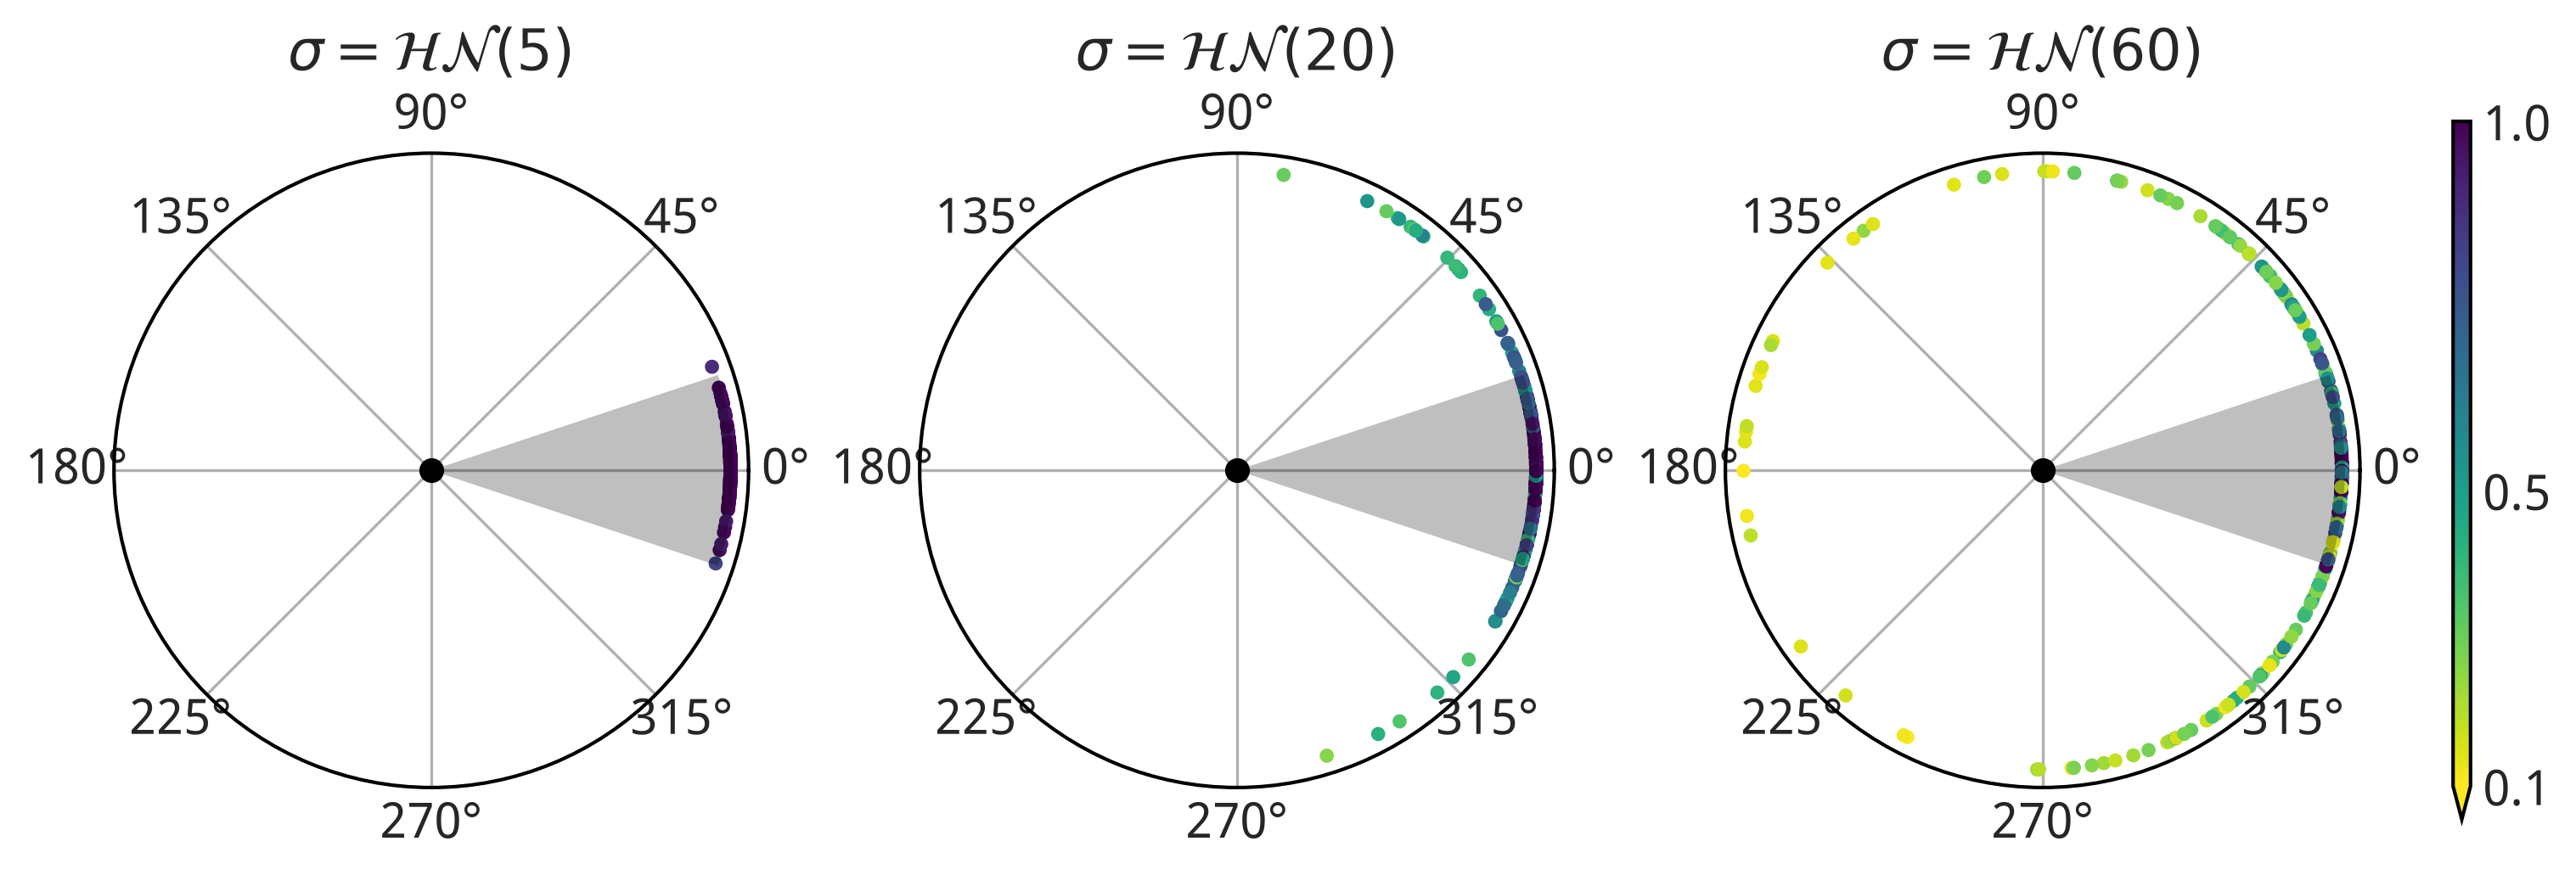

In [4]:
fig, axes = plt.subplots(1, 3, subplot_kw=dict(projection="polar"), figsize=(10, 4))

max_angle = np.arctan(half_length/penalty_point)

for sigma, pps, ax in zip(sigmas_deg, ppss, axes):
    cutoff = pps.prior["p_goal"] > 0.1
    values = pps.prior["α"].where(cutoff)
    cax = ax.scatter(values, np.ones_like(values), c=pps.prior["p_goal"].where(cutoff),
               marker=".", cmap="viridis_r", vmin=0.1)
    ax.fill_between(np.linspace(-max_angle, max_angle, 100), 0, 1.01, alpha=0.25)
    ax.set_yticks([])
    ax.set_title(fr"$\sigma = \mathcal{{HN}}({sigma})$")
    ax.plot(0,0, 'o')
fig.colorbar(cax, extend="min", ticks=[1, 0.5, 0.1], shrink=0.7, aspect=40)

plt.savefig("img/chp02/prior_predictive_distributions_00.png", bbox_inches="tight")



到这一步,我们有几种选择:可以重新思考模型,纳入更多几何学上的考量;也可以换一个能降低出现
荒谬结果概率(即便不能完全排除)的先验;或者干脆先拟合数据,看看数据本身是否足够有信息量,
让后验自动排除掉那些荒谬的取值。下图展示了另一个"意料之外的结果"的例子:一个带二元预测变量
的逻辑回归模型,回归系数的先验是 $\mathcal{N}(0, 1)$。随着预测变量数量增加,先验预测分布的
均值,会从集中在 0.5 附近(第一幅图),逐渐变为均匀分布(中间),再到偏向极端值 0 或 1(最后
一幅图)。这个例子告诉我们:随着预测变量数量增多,由此诱导出的先验预测分布会把更多概率质量
堆积到极端值上。因此我们需要更强的正则化先验(例如拉普拉斯分布),才能让模型远离这些极端值。


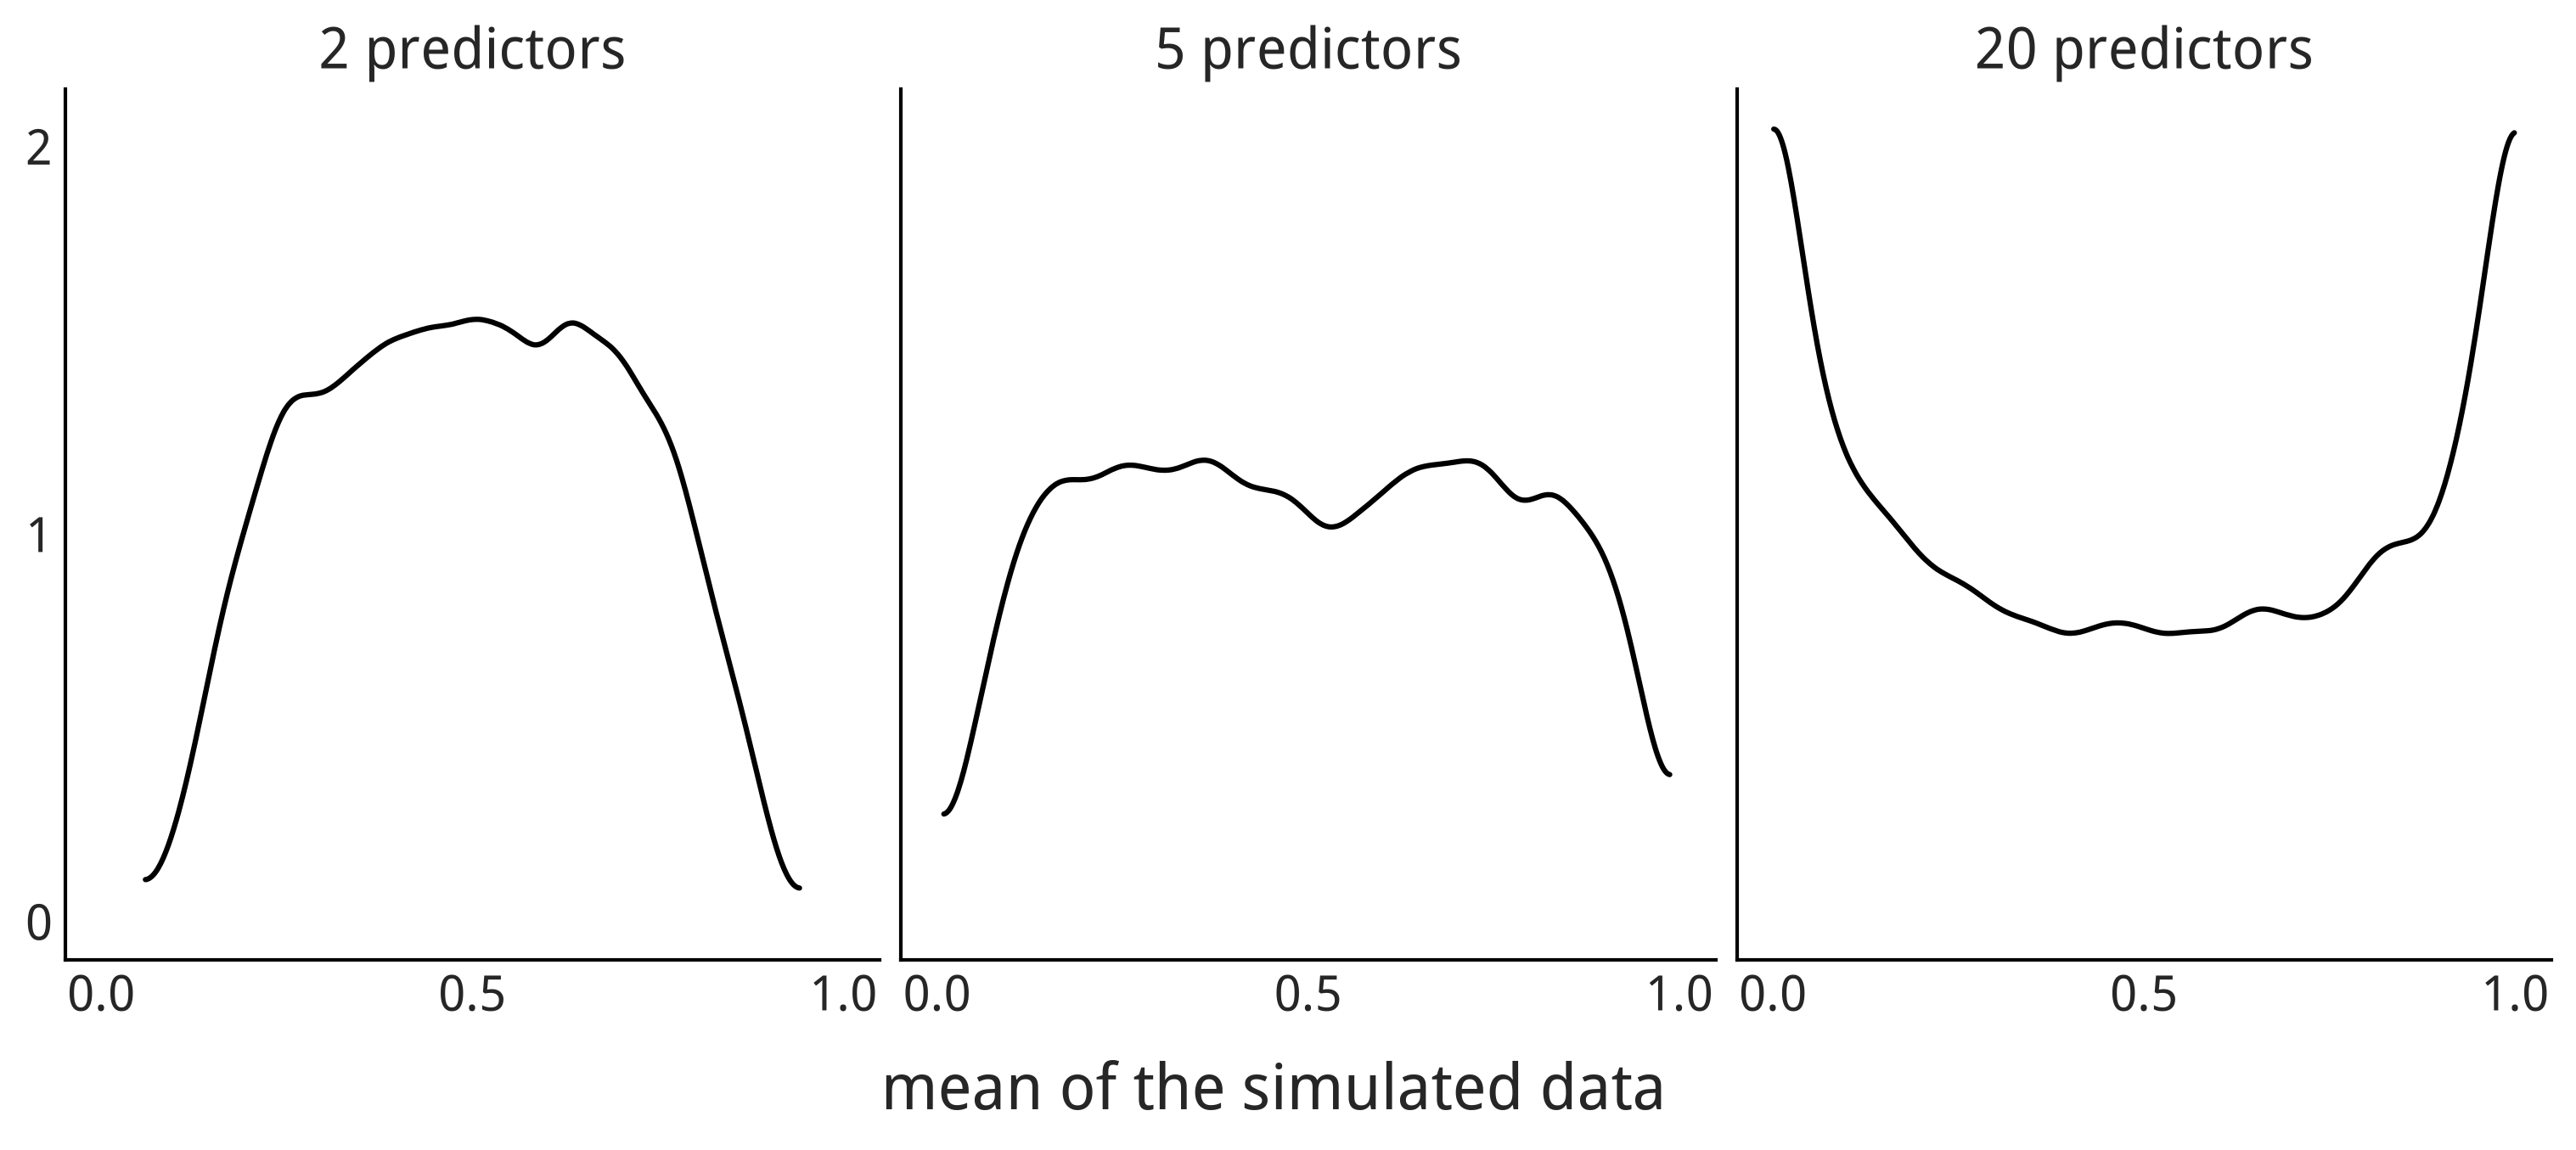

In [5]:
from scipy.special import expit
fig, axes = plt.subplots(1, 3, figsize=(10, 4), sharex=True,  sharey=True)
axes = np.ravel(axes)

for dim, ax in zip([2, 5, 20], axes):
    β = np.random.normal(0, 1, size=(10000, dim))
    X = np.random.binomial(n=1, p=0.75, size=(dim, 500))
    az.plot_kde(expit(β @ X).mean(1), ax=ax)
    ax.set_title(f"{dim} predictors")
    ax.set_xticks([0, 0.5, 1])
    ax.set_yticks([0, 1, 2])

fig.text(0.34, -0.075, size=18, s="mean of the simulated data")
plt.savefig("img/chp02/prior_predictive_distributions_01.png", bbox_inches="tight")



这两个例子都说明,先验不能脱离具体模型来孤立地理解,我们需要把先验放在特定模型的语境中来看。
由于用观测值的语言思考,通常比用模型参数的语言思考更容易,先验预测分布能让模型评估变得更
简单。对于参数要经过多次数学变换、或多个先验相互作用的复杂模型来说,这一点尤其有用。此外,
先验预测分布还可以用一种更直观的方式,向更广泛的受众展示、讨论模型。领域专家可能并不熟悉
统计记号或代码,直接用这些工具沟通未必高效,但如果你把一个或多个模型的推论展示给他们看,
就为讨论提供了更多素材。这对你的领域合作伙伴和你自己都很有价值。而且计算先验预测分布还有
其他好处,比如帮助我们调试模型、确保模型被正确地写出来、并且能在我们的计算环境中正常运行。

## 理解你的预测

正如我们可以用先验预测分布生成的合成数据来检查模型,我们同样可以对后验预测分布做类似的
分析,这个过程通常被称为**后验预测检验(posterior predictive checks)**。基本思路是评估
合成观测值与真实观测值之间有多接近。理想情况下,"接近"的衡量方式应该依赖具体问题,但我们
也可以借助一些通用的规则。我们甚至可能想同时使用多种指标,来从不同角度评估模型与数据的
(不)匹配程度。

下图展示了一个二项模型和数据的简单例子。左图比较了数据中观测到的成功次数(蓝线)与后验预测
分布 1000 个样本给出的预测成功次数。右图是另一种呈现方式,这次展示的是数据中成功/失败的
比例(蓝线)与后验分布 1000 个样本的对比。可以看到,在这个例子中模型很好地捕捉到了均值,
即便模型本身也承认存在相当大的不确定性。模型能很好地捕捉均值并不令人意外,因为我们本来就是
在直接为二项分布的均值建模。在后面的章节里,我们会看到后验预测检验揭示出不那么显而易见、
因而也更有价值的模型拟合信息的例子。


In [6]:
Y = stats.bernoulli(0.7).rvs(100)
with pm.Model() as model:
    θ = pm.Beta("θ", 1, 1)
    y_obs = pm.Binomial("y_obs",n=1, p=θ, observed=Y)
    idata_b = pm.sample(
        draws=DRAWS, tune=TUNE, chains=CHAINS, cores=1,
        random_seed=RANDOM_SEED)
    idata_b.extend(pm.sample_posterior_predictive(
        idata_b, random_seed=RANDOM_SEED))


Initializing NUTS using jitter+adapt_diag...


Sequential sampling (4 chains in 1 job)


NUTS: [θ]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 34 seconds.


Sampling: [y_obs]


Output()

In [7]:
pred_dist = az.extract(
    idata_b, group="posterior_predictive", num_samples=PREDICTIVE_SAMPLES,
    rng=RANDOM_SEED)["y_obs"].values
pred_dist.sum(0).shape


(1000,)

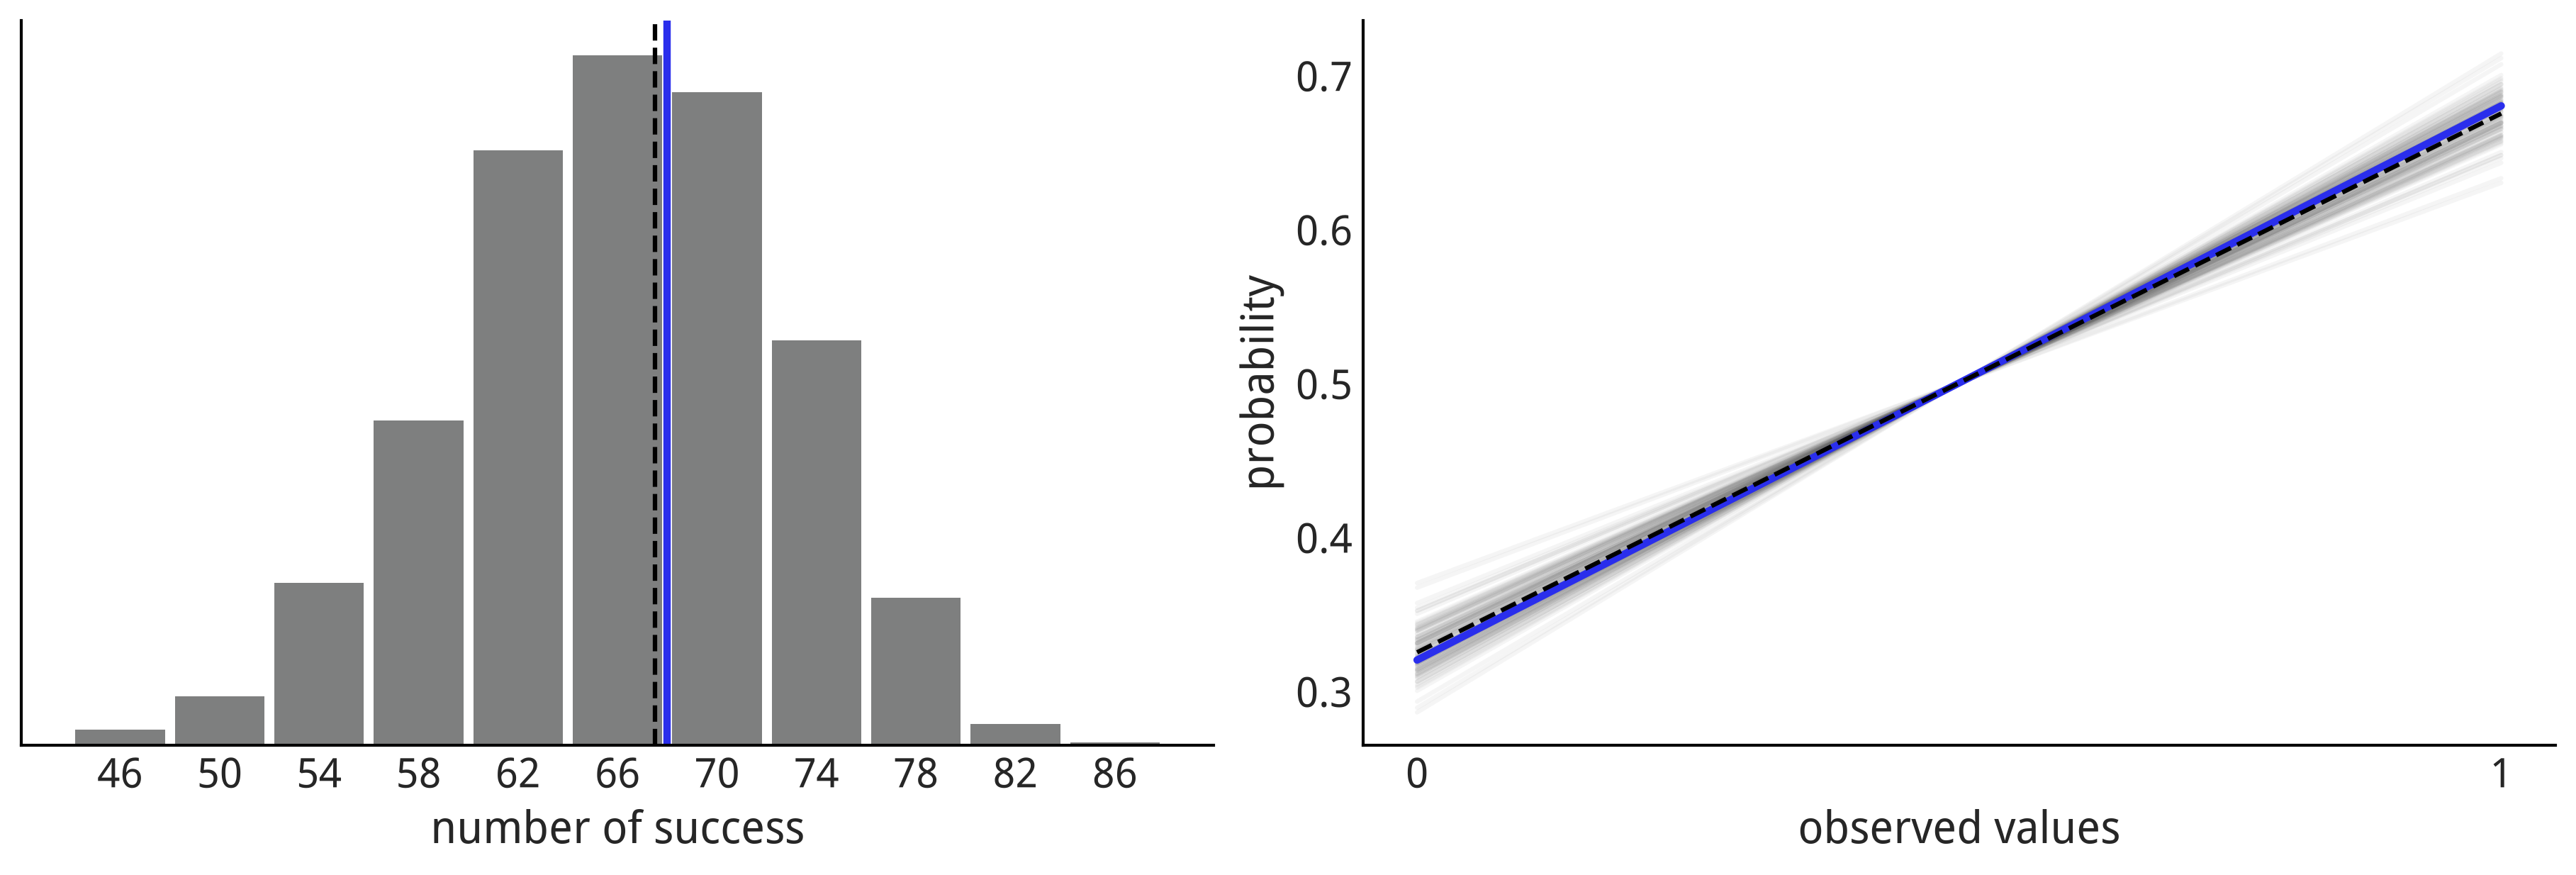

In [8]:
_, ax = plt.subplots(1, 2, figsize=(12, 4), constrained_layout=True)

az.plot_dist(pred_dist.sum(0),
             hist_kwargs={"color":"C2"}, ax=ax[0])
ax[0].axvline(Y.sum(), color="C4", lw=2.5)
ax[0].axvline(pred_dist.sum(0).mean(), color="k", ls="--")
ax[0].set_yticks([])
ax[0].set_xlabel("number of success")

pps_ = pred_dist.mean(1)
ax[1].plot((np.zeros_like(pps_), np.ones_like(pps_)), (1-pps_, pps_), 'C1', alpha=0.05)

ax[1].plot((0, 1), (1-Y.mean(), Y.mean()), 'C4', lw=2.5)
ax[1].plot((0, 1), (1-pps_.mean(), pps_.mean()), 'k--')
ax[1].set_xticks((0,1))
ax[1].set_xlabel("observed values")
ax[1].set_ylabel("probability")
plt.savefig("img/chp02/posterior_predictive_check.png")



后验预测检验并不局限于画图,我们也可以做数值检验。一种做法是计算:

$$
p_{B} = p(T_{sim} \leq T_{obs} \mid \tilde Y)
$$

这里 $p_{B}$ 被称为**贝叶斯 p 值**,定义为"模拟出的检验统计量 $T_{sim}$ 小于等于观测统计量
$T_{obs}$"这一事件的概率。统计量 $T$ 基本上可以是我们想用来评估模型拟合数据程度的任何指标。
沿用二项分布的例子,我们可以把 $T_{obs}$ 取为观测到的成功率,再用它和后验预测分布给出的
$T_{sim}$ 做比较。理想情况下 $p_{B}=0.5$,意味着算出的 $T_{sim}$ 统计量,一半时间落在观测
统计量 $T_{obs}$ 之下、一半时间落在其上——这正是模型拟合良好时我们期望看到的结果。

由于我们钟爱画图,贝叶斯 p 值当然也可以画出来。下图第一幅子图展示了贝叶斯 p 值分布的黑色
实线,虚线代表相同大小数据集所期望的分布;可以用 ArviZ 的 `az.plot_bpv(., kind="p_value")`
得到这幅图。第二幅子图在概念上类似,区别在于:这次我们是"逐个观测值"地评估有多少模拟结果
低于(或高于)对应的观测值。对一个校准良好的模型来说,所有观测值应该被同等地预测好,也就是
说高于/低于观测值的预测数量应该大致相等,因此我们应该得到一个均匀分布。而对任何有限数据集
而言,即便模型完全校准良好,也依然会与均匀分布存在偏差,因此图上画了一条我们预期能包含 94%
"类均匀"曲线的带状区域。

> **贝叶斯 p 值**:我们之所以把 $p_{B}$ 称为贝叶斯 p 值,是因为上式本质上就是 p 值的定义,
> 而"贝叶斯"体现在:我们用的不是原假设下统计量 $T$ 的抽样分布,而是后验预测分布。注意,
> 这里我们并没有对任何原假设做条件化,也没有用任何预先设定的阈值来宣布"统计显著"或做假设
> 检验。


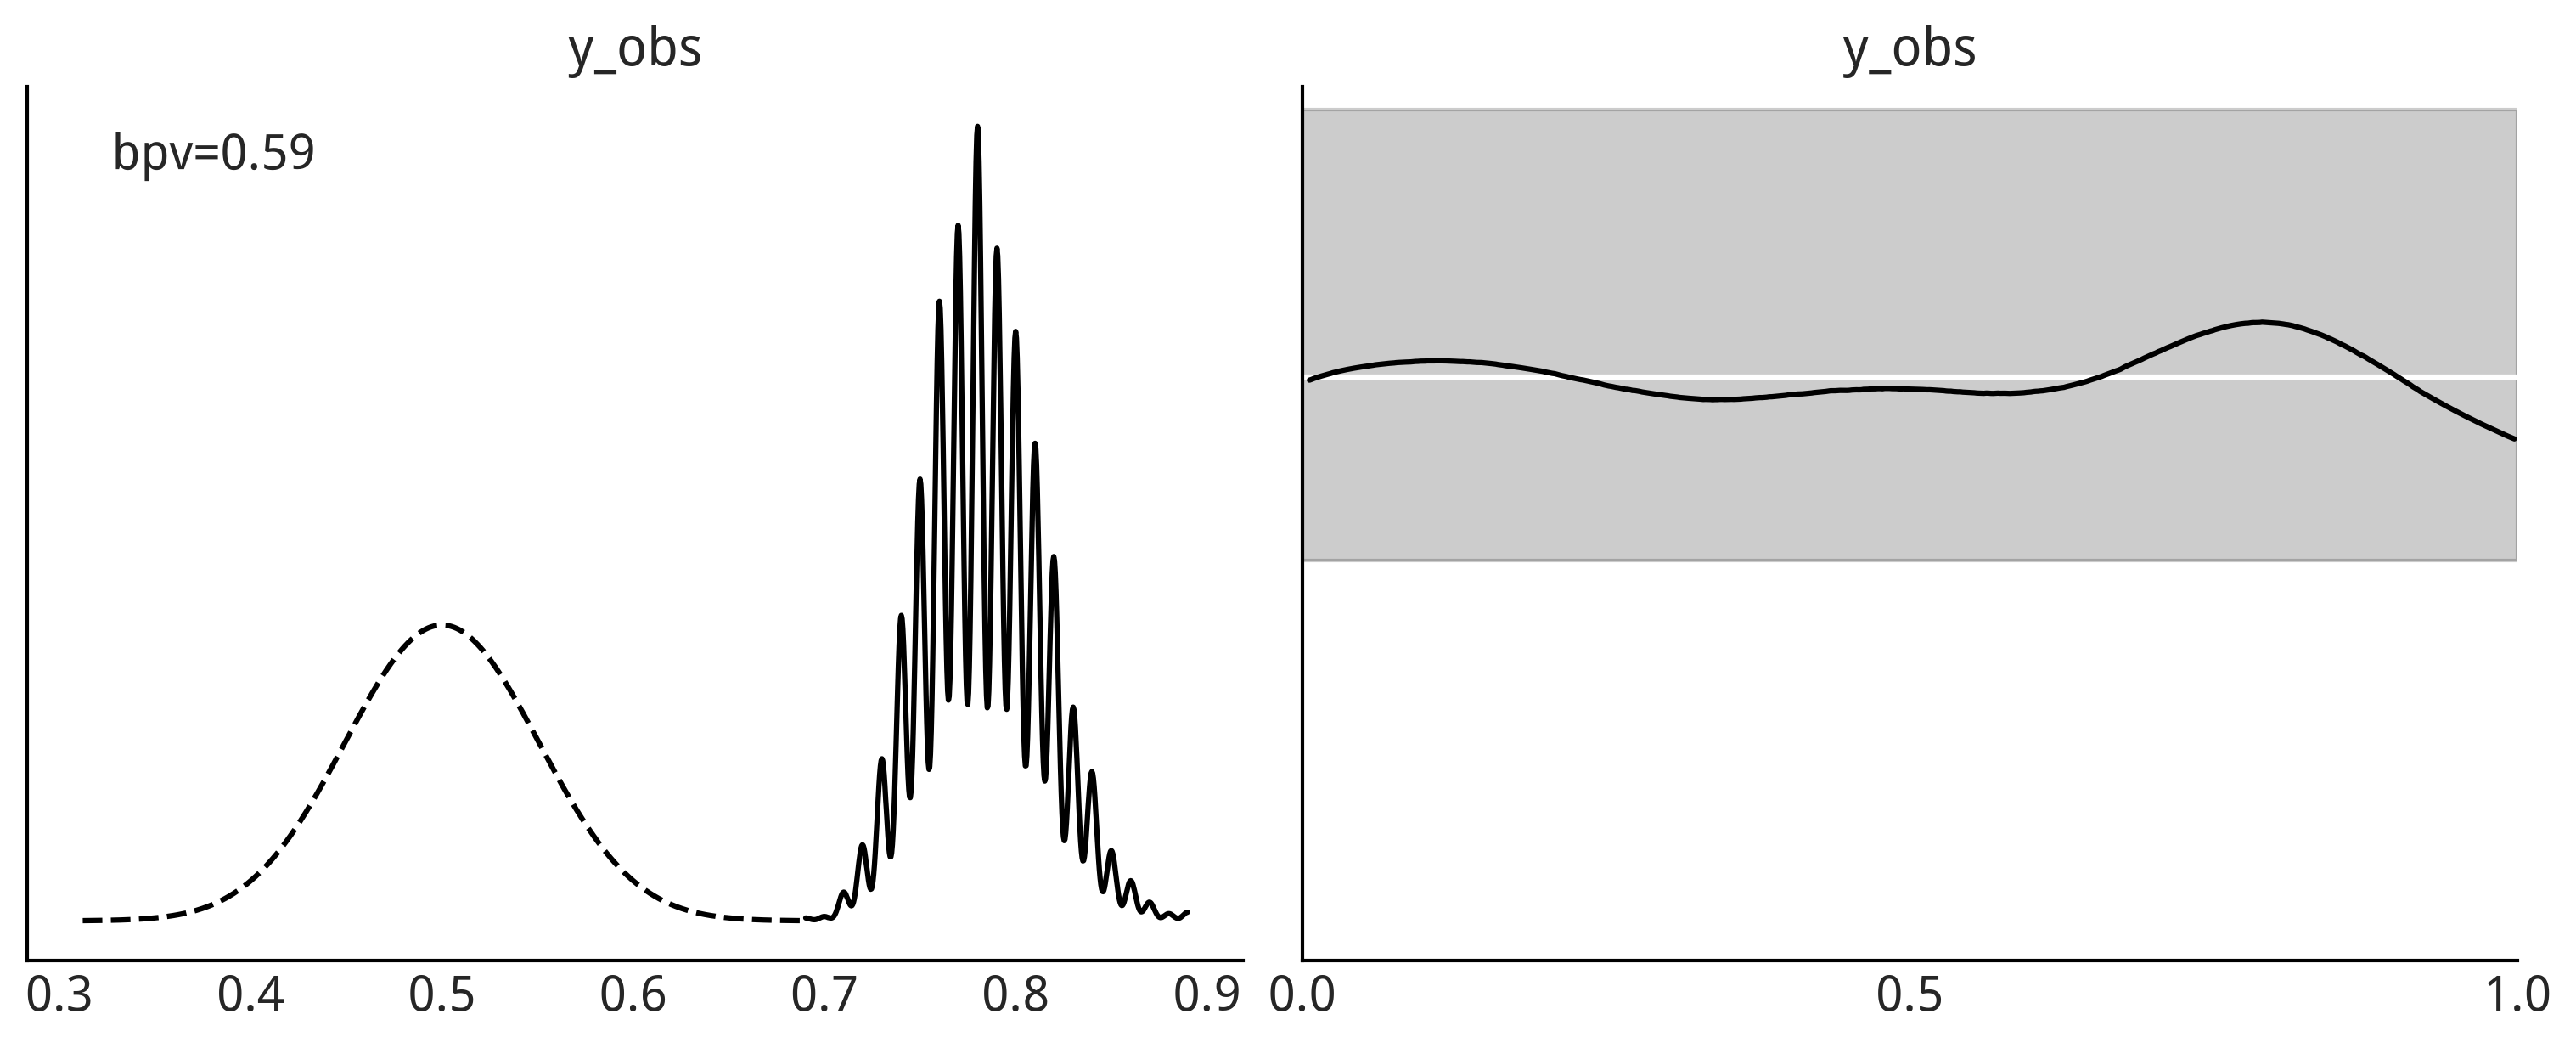

In [9]:
_, ax = plt.subplots(1, 2, figsize=(10, 4))
az.plot_bpv(idata_b, kind="p_value", ax=ax[0])
ax[0].legend([f"bpv={(Y.mean() > pred_dist.mean(1)).mean():.2f}"], handlelength=0)
az.plot_bpv(idata_b, kind="u_value", ax=ax[1])
ax[1].set_yticks([])
ax[1].set_xticks([0., 0.5, 1.])
plt.savefig("img/chp02/posterior_predictive_check_pu_values.png")



正如前面所说,我们可以选用许多不同的 $T$ 统计量来汇总观测值和预测值。下图给出两个例子:
第一幅子图中 $T$ 是均值,第二幅子图中 $T$ 是标准差。图中的曲线是后验预测分布给出的 $T$
统计量的 KDE,点则代表观测数据对应的取值。


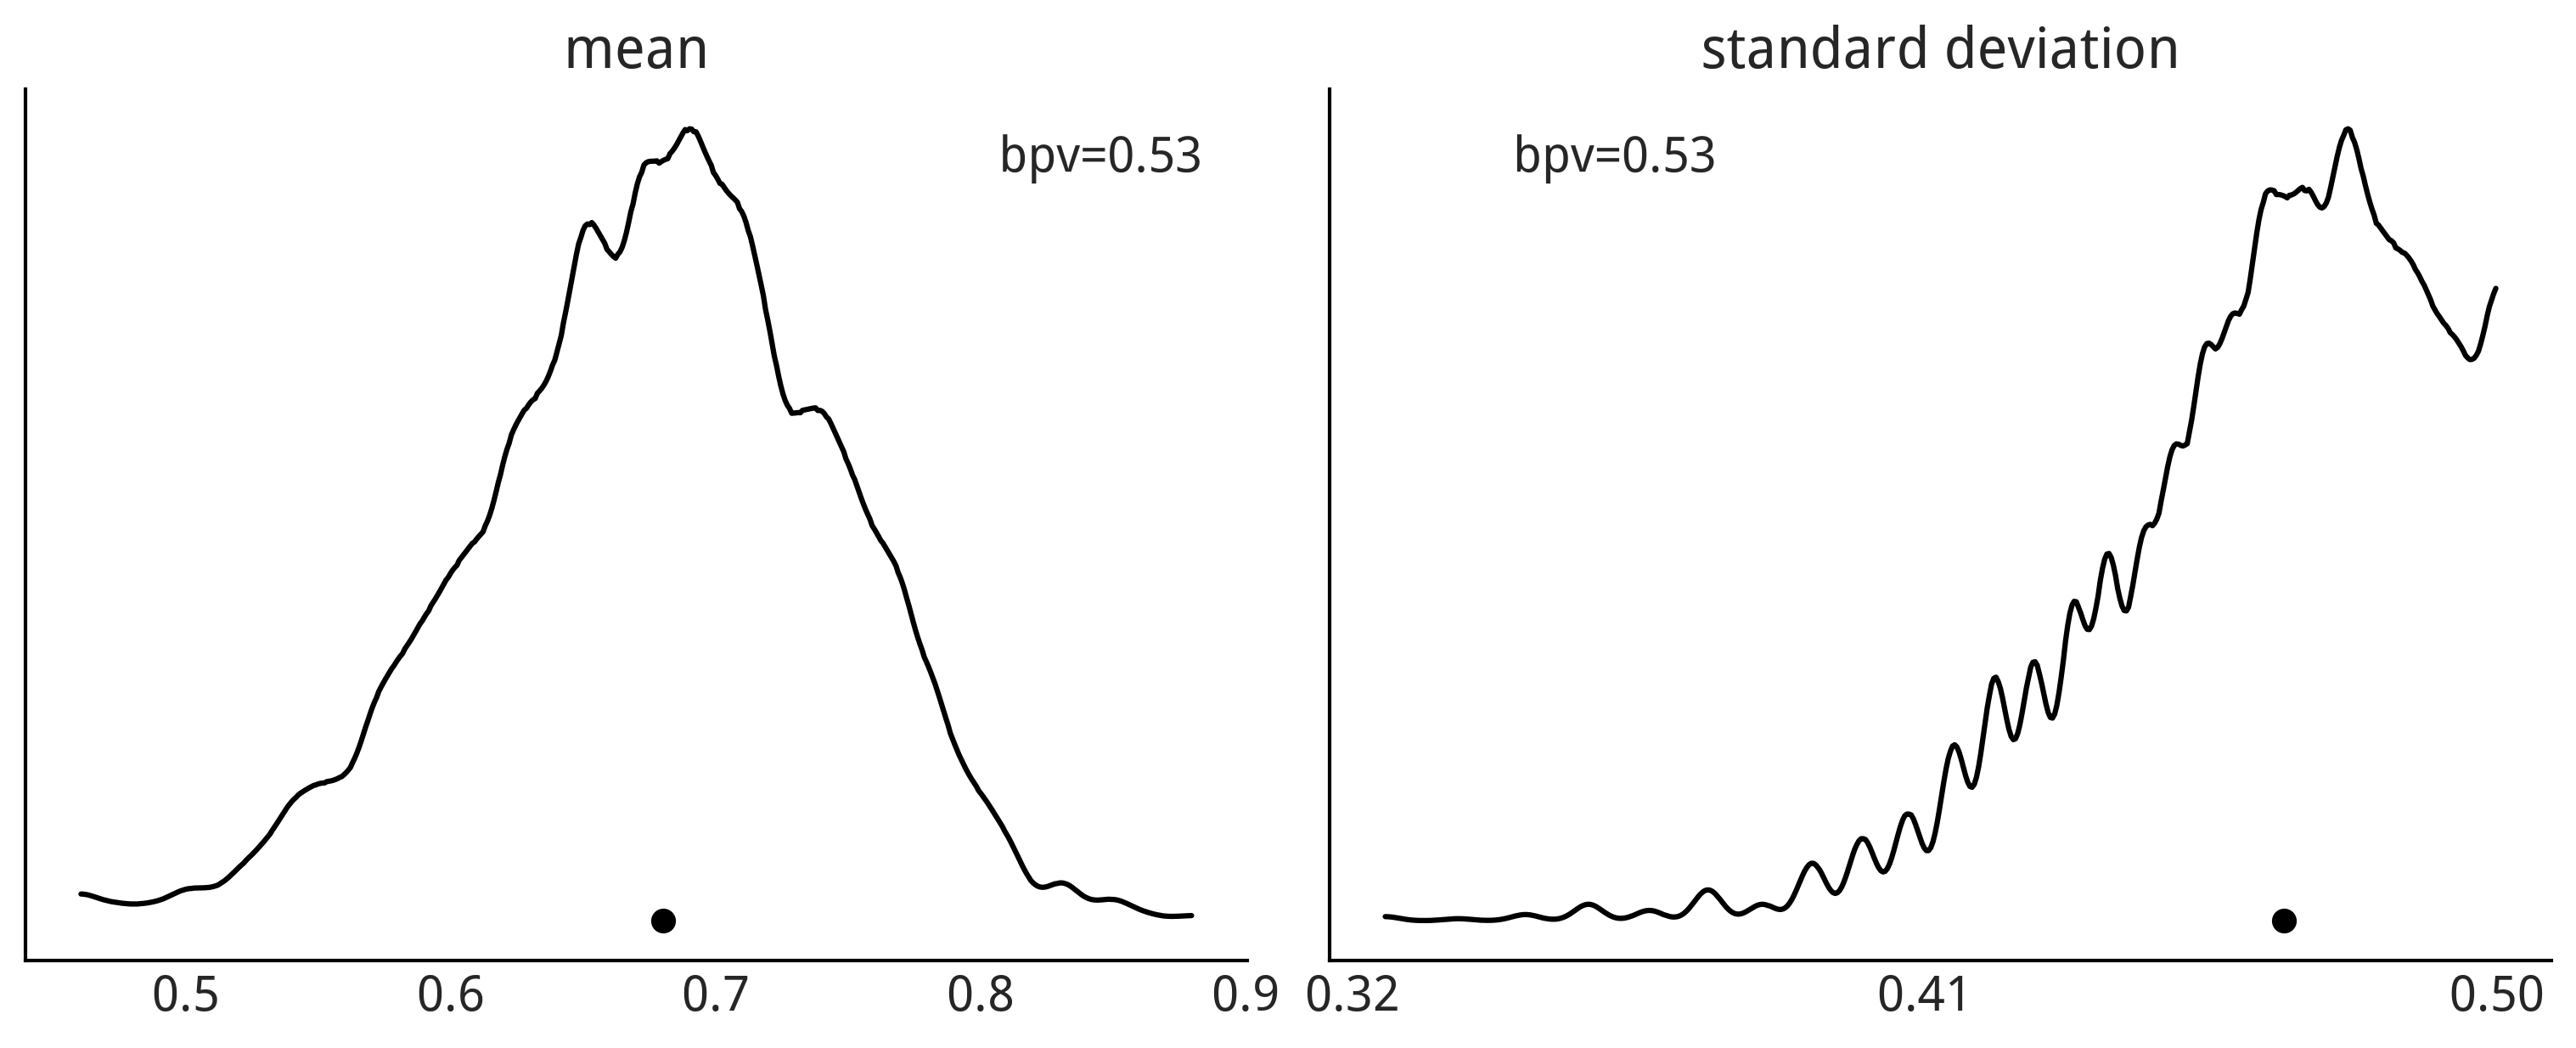

In [10]:
_, ax = plt.subplots(1, 2, figsize=(10, 4))
az.plot_bpv(idata_b, kind="t_stat", t_stat="mean", ax=ax[0])
ax[0].set_title("mean")
az.plot_bpv(idata_b, kind="t_stat", t_stat="std", ax=ax[1])
ax[1].set_title("standard deviation")
ax[1].set_xticks([0.32, 0.41, 0.5])
plt.savefig("img/chp02/posterior_predictive_check_tstat.png")



在继续往下读之前,不妨花点时间仔细端详下图,试着理解为什么这些图会长成这个样子。下图给出
一系列简单的例子,帮助我们建立解读后验预测检验图的直觉。在这些例子里,观测数据(蓝色)全部
服从高斯分布:

1. 第一行:模型的预测系统性地偏向比观测数据更大的值。
2. 第二行:模型预测的离散程度比观测数据更大。
3. 第三行:与第二行相反,模型在尾部生成的预测不够多。
4. 最后一行:模型的预测服从一个高斯混合分布。

现在我们特别关注下图的第三列。这一列的图很有用,但初看可能会有点让人困惑。从上到下依次可以
这样解读:

1. 模型在左尾缺失了一些观测(而在右尾生成了更多)。
2. 模型在中部生成的预测偏少(而在两个尾部偏多)。
3. 模型在两个尾部生成的预测都偏少。
4. 模型的预测大体上算是校准良好的,但我生性多疑,所以还是应该再做一次后验预测检验来确认。

如果这种读图方式对你来说还是有点绕,我们可以换一个完全等价、但可能更直观的角度来解读——
前提是你要记住:你能改变的是**模型**,而不是观测数据 [^8]。同样从上到下:

1. 左侧有更多观测。
2. 中间有更多观测。
3. 两个尾部有更多观测。
4. 观测看起来分布得还不错(至少在预期范围内),但你不该轻信我说的话——毕竟我只是一个活在
   柏拉图世界里的模型。

希望下图以及配套的讨论,能给你足够的直觉,帮助你在真实场景中做好模型检查。


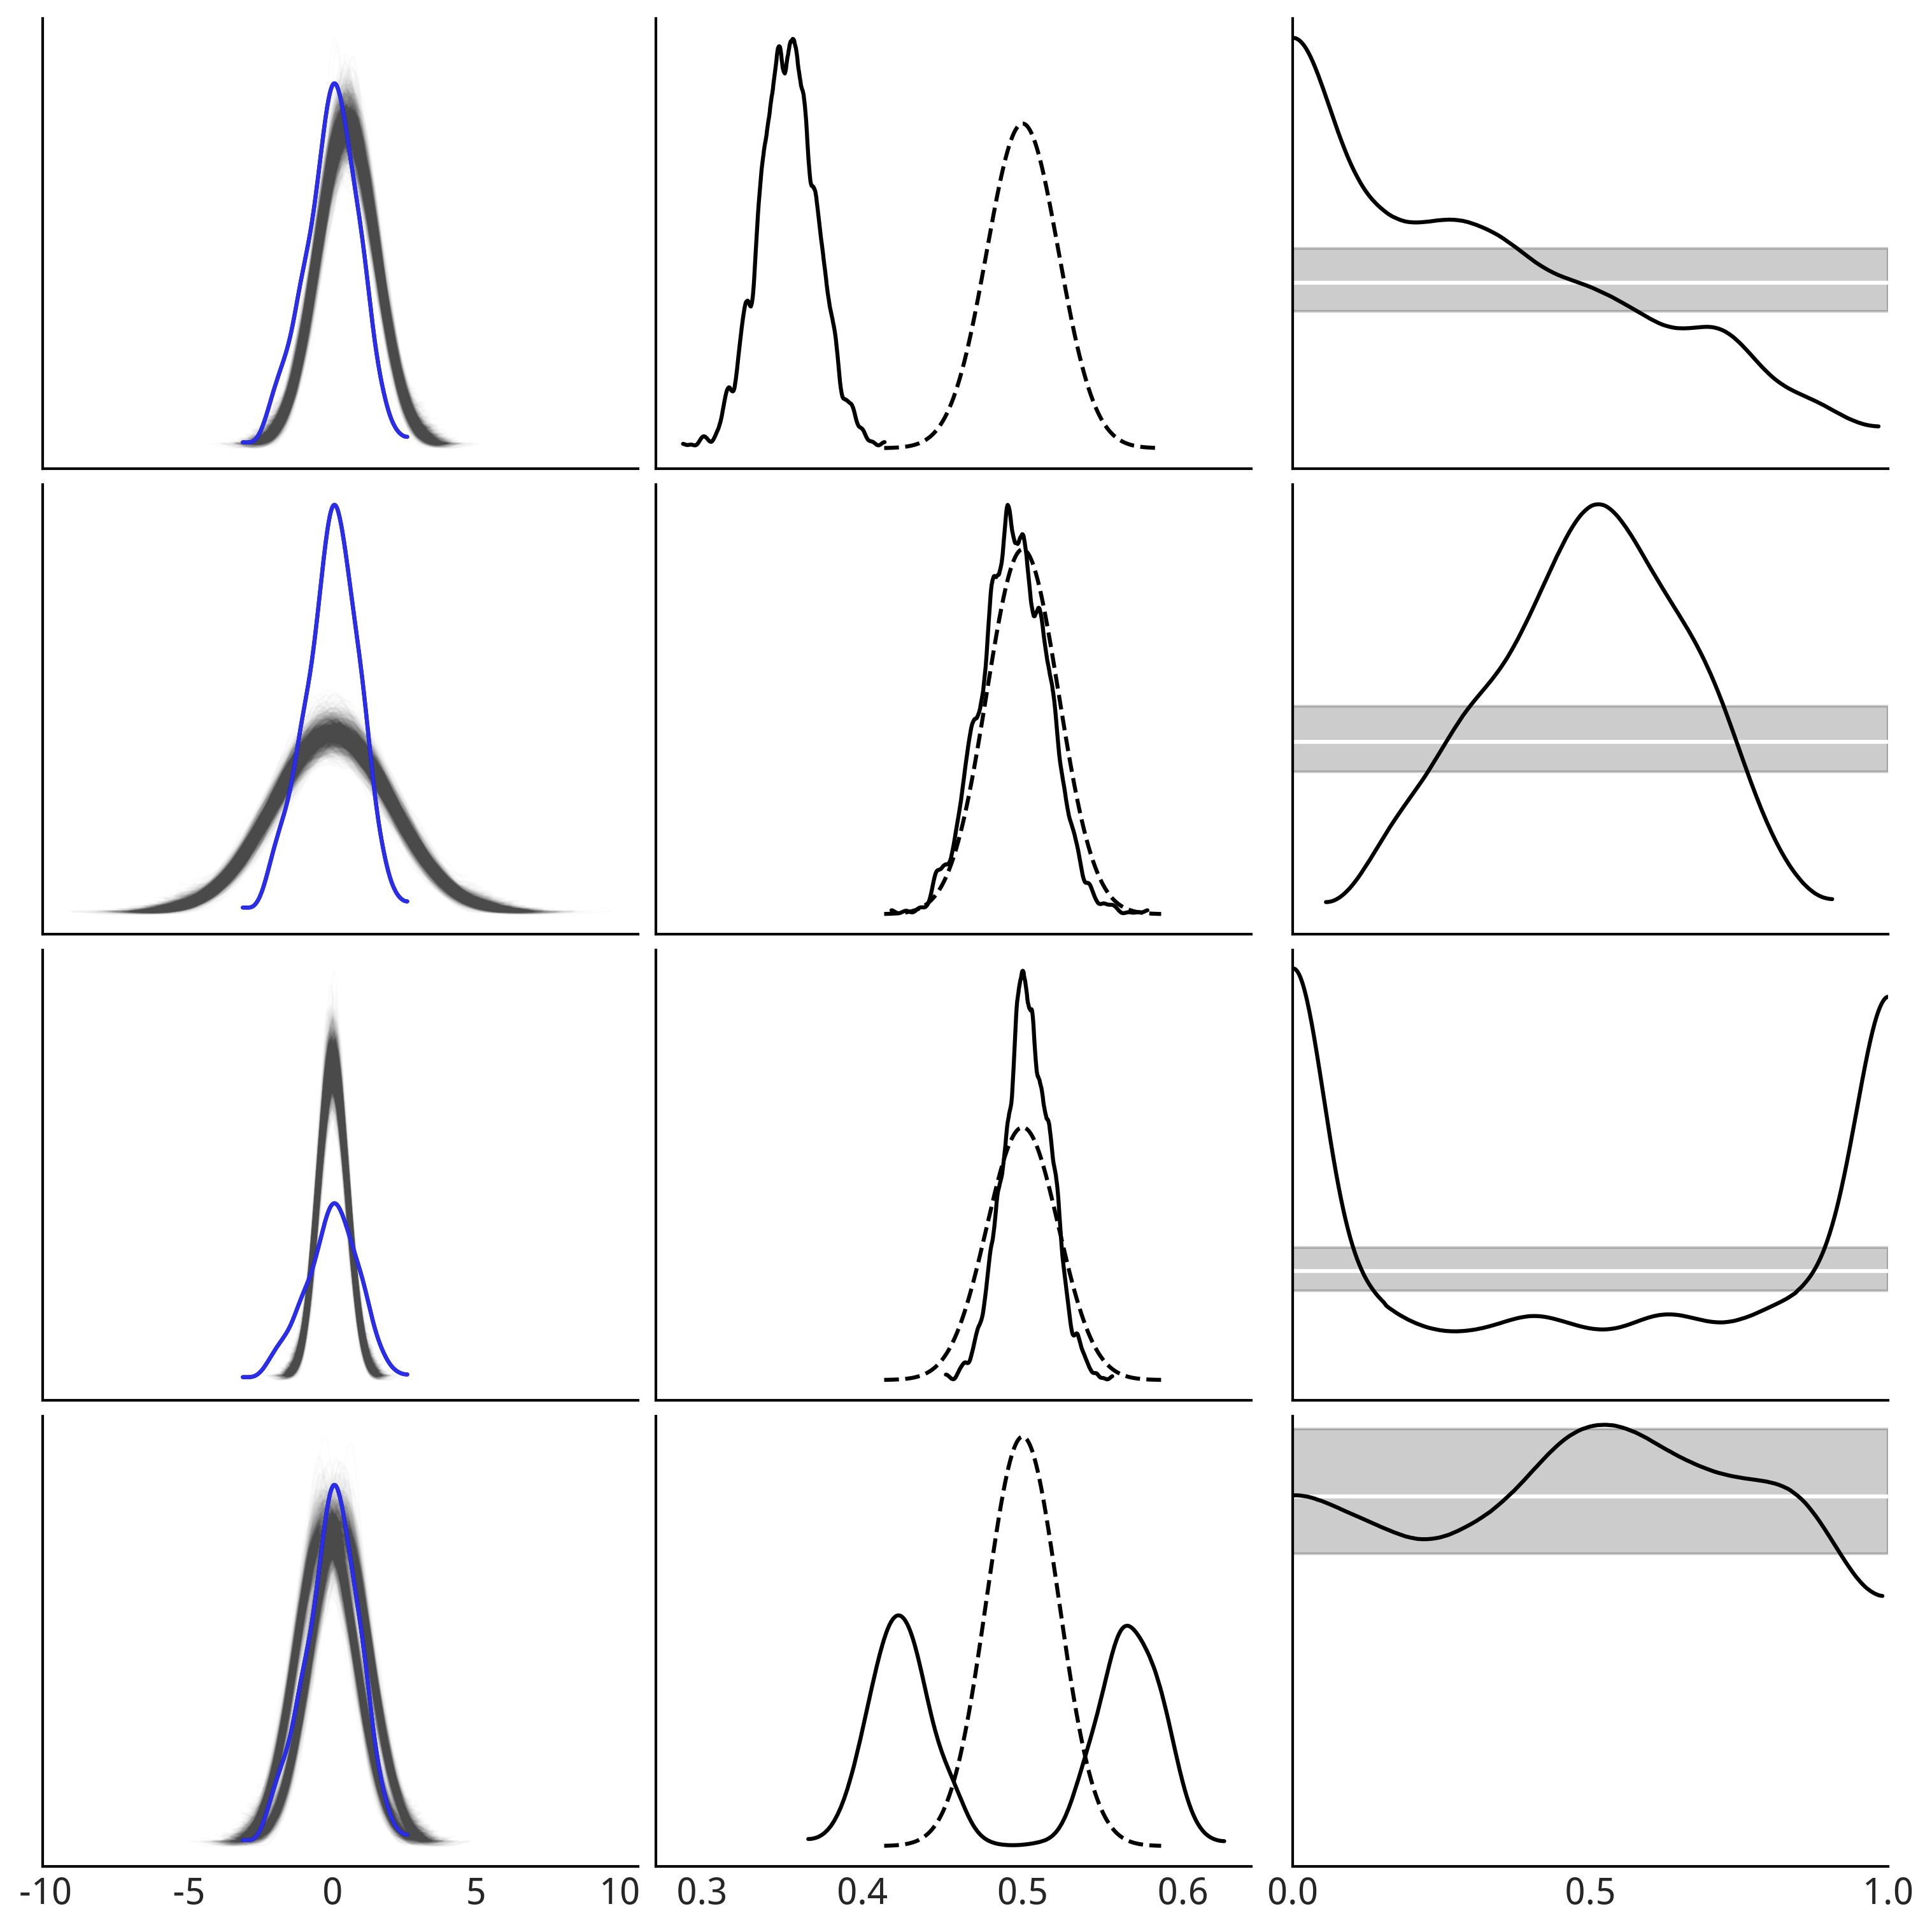

In [11]:
n_obs = 500
samples = 2000
y_obs = np.random.normal(0, 1, size=n_obs)

idata1 = az.from_dict(posterior_predictive={"y":np.random.normal(0.5, 1, size=(1, samples, n_obs))},
                      observed_data={"y":y_obs})

idata2 = az.from_dict(posterior_predictive={"y":np.random.normal(0, 2, size=(1, samples, n_obs))},
                      observed_data={"y":y_obs})

idata3 = az.from_dict(posterior_predictive={"y":np.random.normal(0, 0.5, size=(1, samples,n_obs))},
                      observed_data={"y":y_obs})

idata4 = az.from_dict(posterior_predictive={"y":np.concatenate(
                                                [np.random.normal(-0.25, 1, size=(1, samples//2, n_obs)),
                                                 np.random.normal(0.25, 1, size=(1, samples//2, n_obs))]
                                                                )},
                      observed_data={"y":y_obs})

idatas = [idata1,
          idata2,
          idata3,
          idata4,
]

_, axes = plt.subplots(len(idatas), 3, figsize=(10, 10), sharex="col")

for idata, ax in zip(idatas, axes):
    az.plot_ppc(
        idata, ax=ax[0], colors=["C1", "k", "C0"],
        alpha=0.01, mean=False, legend=False)
    az.plot_kde(idata.observed_data["y"].values, ax=ax[0], plot_kwargs={"color":"C4", "zorder":3})
    ax[0].set_xlabel("")
    az.plot_bpv(idata, kind="p_value", ax=ax[1])
    az.plot_bpv(idata, kind="u_value", ax=ax[2])
    ax[2].set_yticks([])
    ax[2].set_xticks([0., 0.5, 1.])
    for ax_ in ax:
        ax_.set_title("")

plt.savefig("img/chp02/posterior_predictive_many_examples.png")



不管是用图还是用数值汇总,又或者两者结合,后验预测检验都是一个非常灵活的思路。这个概念足够
通用,允许实践者发挥想象力,设计出各种不同的方式来探索、评估模型,并通过预测更好地理解模型
(们)在特定问题上的表现。

## 诊断数值推断

用数值方法近似后验分布,让我们能够求解那些用纸笔求解会很繁琐、甚至在数学上根本不可解的贝叶斯
模型。不幸的是,这些方法并不总能如预期般奏效。正因如此,我们必须始终评估它们给出的结果是否
真的可用。为此我们可以借助一整套数值和可视化诊断工具。本节会讨论马尔可夫链蒙特卡洛方法中最
常见、也最有用的一些诊断工具。

为了帮助理解这些诊断工具,我们先构造 3 个**合成后验(synthetic posteriors)**。第一个是从
$\text{Beta}(2, 5)$ 中抽取的样本,我们用 SciPy 生成,称之为 `good_chains`。这是一个"好"样本
的例子,因为我们生成的是独立同分布(iid)的抽样,这正是我们希望从后验近似中得到的理想状态。
第二个叫 `bad_chains0`,代表一个很差的后验样本。我们的生成方式是:先对 `good_chains` 排序,
再加上一点小的高斯噪声。`bad_chains0` 之所以差,有两个原因:

- 数值之间并不独立,恰恰相反,它们高度自相关——也就是说,给定序列中任意位置的一个数值,我们
  都能相当精确地推算出它前后的数值。
- 数值也不是同分布的,因为我们是把一个先展平又排序过的数组,重新塑形成了一个代表两条链的
  二维数组。

第三个合成后验叫 `bad_chains1`,同样由 `good_chains` 生成,但我们通过随机引入一些"连续样本
高度相关"的片段,把它变成了一个差样本的代表。`bad_chains1` 代表一种很常见的场景:采样器能
很好地探索参数空间的某个区域,但在一个或多个其他区域却采样困难。


In [12]:
np.random.seed(5201)


In [13]:
good_chains = stats.beta.rvs(2, 5,size=(2, 2000))
bad_chains0 = np.random.normal(np.sort(good_chains, axis=None), 0.05,
                               size=4000).reshape(2, -1)

bad_chains1 = good_chains.copy()
for i in np.random.randint(1900, size=4):
    bad_chains1[i%2:,i:i+100] = np.random.beta(i, 950, size=100)

chains = {"good_chains":good_chains,
          "bad_chains0":bad_chains0,
          "bad_chains1":bad_chains1}



注意,这 3 个合成后验都是标量(单参数)后验分布的样本。这对我们目前的讨论已经足够,因为
我们要介绍的所有诊断指标,都是针对模型中的每个参数分别计算的。

### 有效样本量(Effective Sample Size)

在使用 MCMC 采样方法时,我们很自然会想知道:某个具体样本是否大到足以让我们有信心地计算出
均值、HDI 等感兴趣的量?仅凭样本数量本身是无法直接回答这个问题的,原因是 MCMC 方法产生的
样本总会带有一定程度的**自相关**,因此该样本实际包含的"信息量",会少于同样大小的 iid 样本
所包含的信息量。如果两个值之间的相似程度是它们之间时间间隔的函数,我们就说这个序列存在
自相关。举个例子,如果今天日落是 6 点 03 分,你就知道明天的日落时间也大致在这个附近。事实上,
越靠近赤道,你就能越准确地根据今天的数据预测未来的日落时间——也就是说,赤道附近的自相关性
比两极附近更强 [^9]。

我们可以把有效样本量(ESS)理解为:一个考虑了自相关性的估计量,它给出的是"如果我们的样本
真的是 iid 的,那么应该有多少个样本"。这个解释很吸引人,但我们后面会看到,不应该对它做过度
解读。

用 ArviZ 我们可以用 `az.ess()` 计算均值的有效样本量:


In [14]:
az.ess(chains)


<xarray.Dataset> Size: 24B
Dimensions:      ()
Data variables:
    bad_chains0  float64 8B 2.436
    bad_chains1  float64 8B 111.1
    good_chains  float64 8B 4.389e+03
Attributes:
    created_at:     2026-08-23T08:21:24.561255+00:00
    arviz_version:  0.23.4


可以看到,尽管我们每个合成后验的实际样本数都是 4000,`bad_chains0` 的有效性却只相当于一个
大小约为 2 的 iid 样本!这是一个非常低的数字,说明采样器出了问题。考虑到 ArviZ 计算 ESS 的
方法,以及我们构造 `bad_chains0` 的方式,这个结果完全符合预期——`bad_chains0` 是一个双峰
分布,每条链各自卡在一个峰里。对这类情形,ESS 大致会等于 MCMC 链实际探索到的峰的数量。对
`bad_chains1`,我们同样得到一个偏低的数字(约 111);只有 `good_chains` 的 ESS 接近实际
样本数。

> **关于"有效"样本的一点提醒**:如果你换一个随机种子重新生成这些合成后验,会发现每次算出的
> 有效样本量都不一样——这是预料之中的,因为样本本身也会不同(它们终究只是样本)。对
> `good_chains` 而言,有效样本量平均会低于实际样本数,但注意 ESS 其实**也可能大于实际样本
> 数**!当使用 NUTS 采样器时,对那些后验接近高斯、且与模型中其他参数几乎独立的参数,是有
> 可能出现 ESS 大于总抽样数这种情况的。

马尔可夫链的收敛程度在参数空间中并不是均匀的——直觉上讲,从分布的主体部分获得好的近似,要
比从尾部获得好的近似容易得多,原因很简单,尾部主要由罕见事件主导。`az.ess()` 默认返回的是
`bulk-ESS`,主要评估分布**中心**部分的解析质量。如果你还想报告后验区间,或者你关心的是罕见
事件,就应该检查 `tail-ESS`,它对应第 5 和第 95 百分位处的最小 ESS。如果你关心特定分位数,
可以用 `az.ess(., method='quantile')` 向 ArviZ 请求这些具体数值。

由于 ESS 的取值在参数空间中会发生变化,把这种变化可视化出来往往很有用。我们至少有两种方式
可以做到这一点:用 `az.plot_ess(., kind="quantiles")` 画出特定分位数处的 ESS,或者用
`az.plot_ess(., kind="local")` 画出两个分位数之间小区间的 ESS,如下图所示。


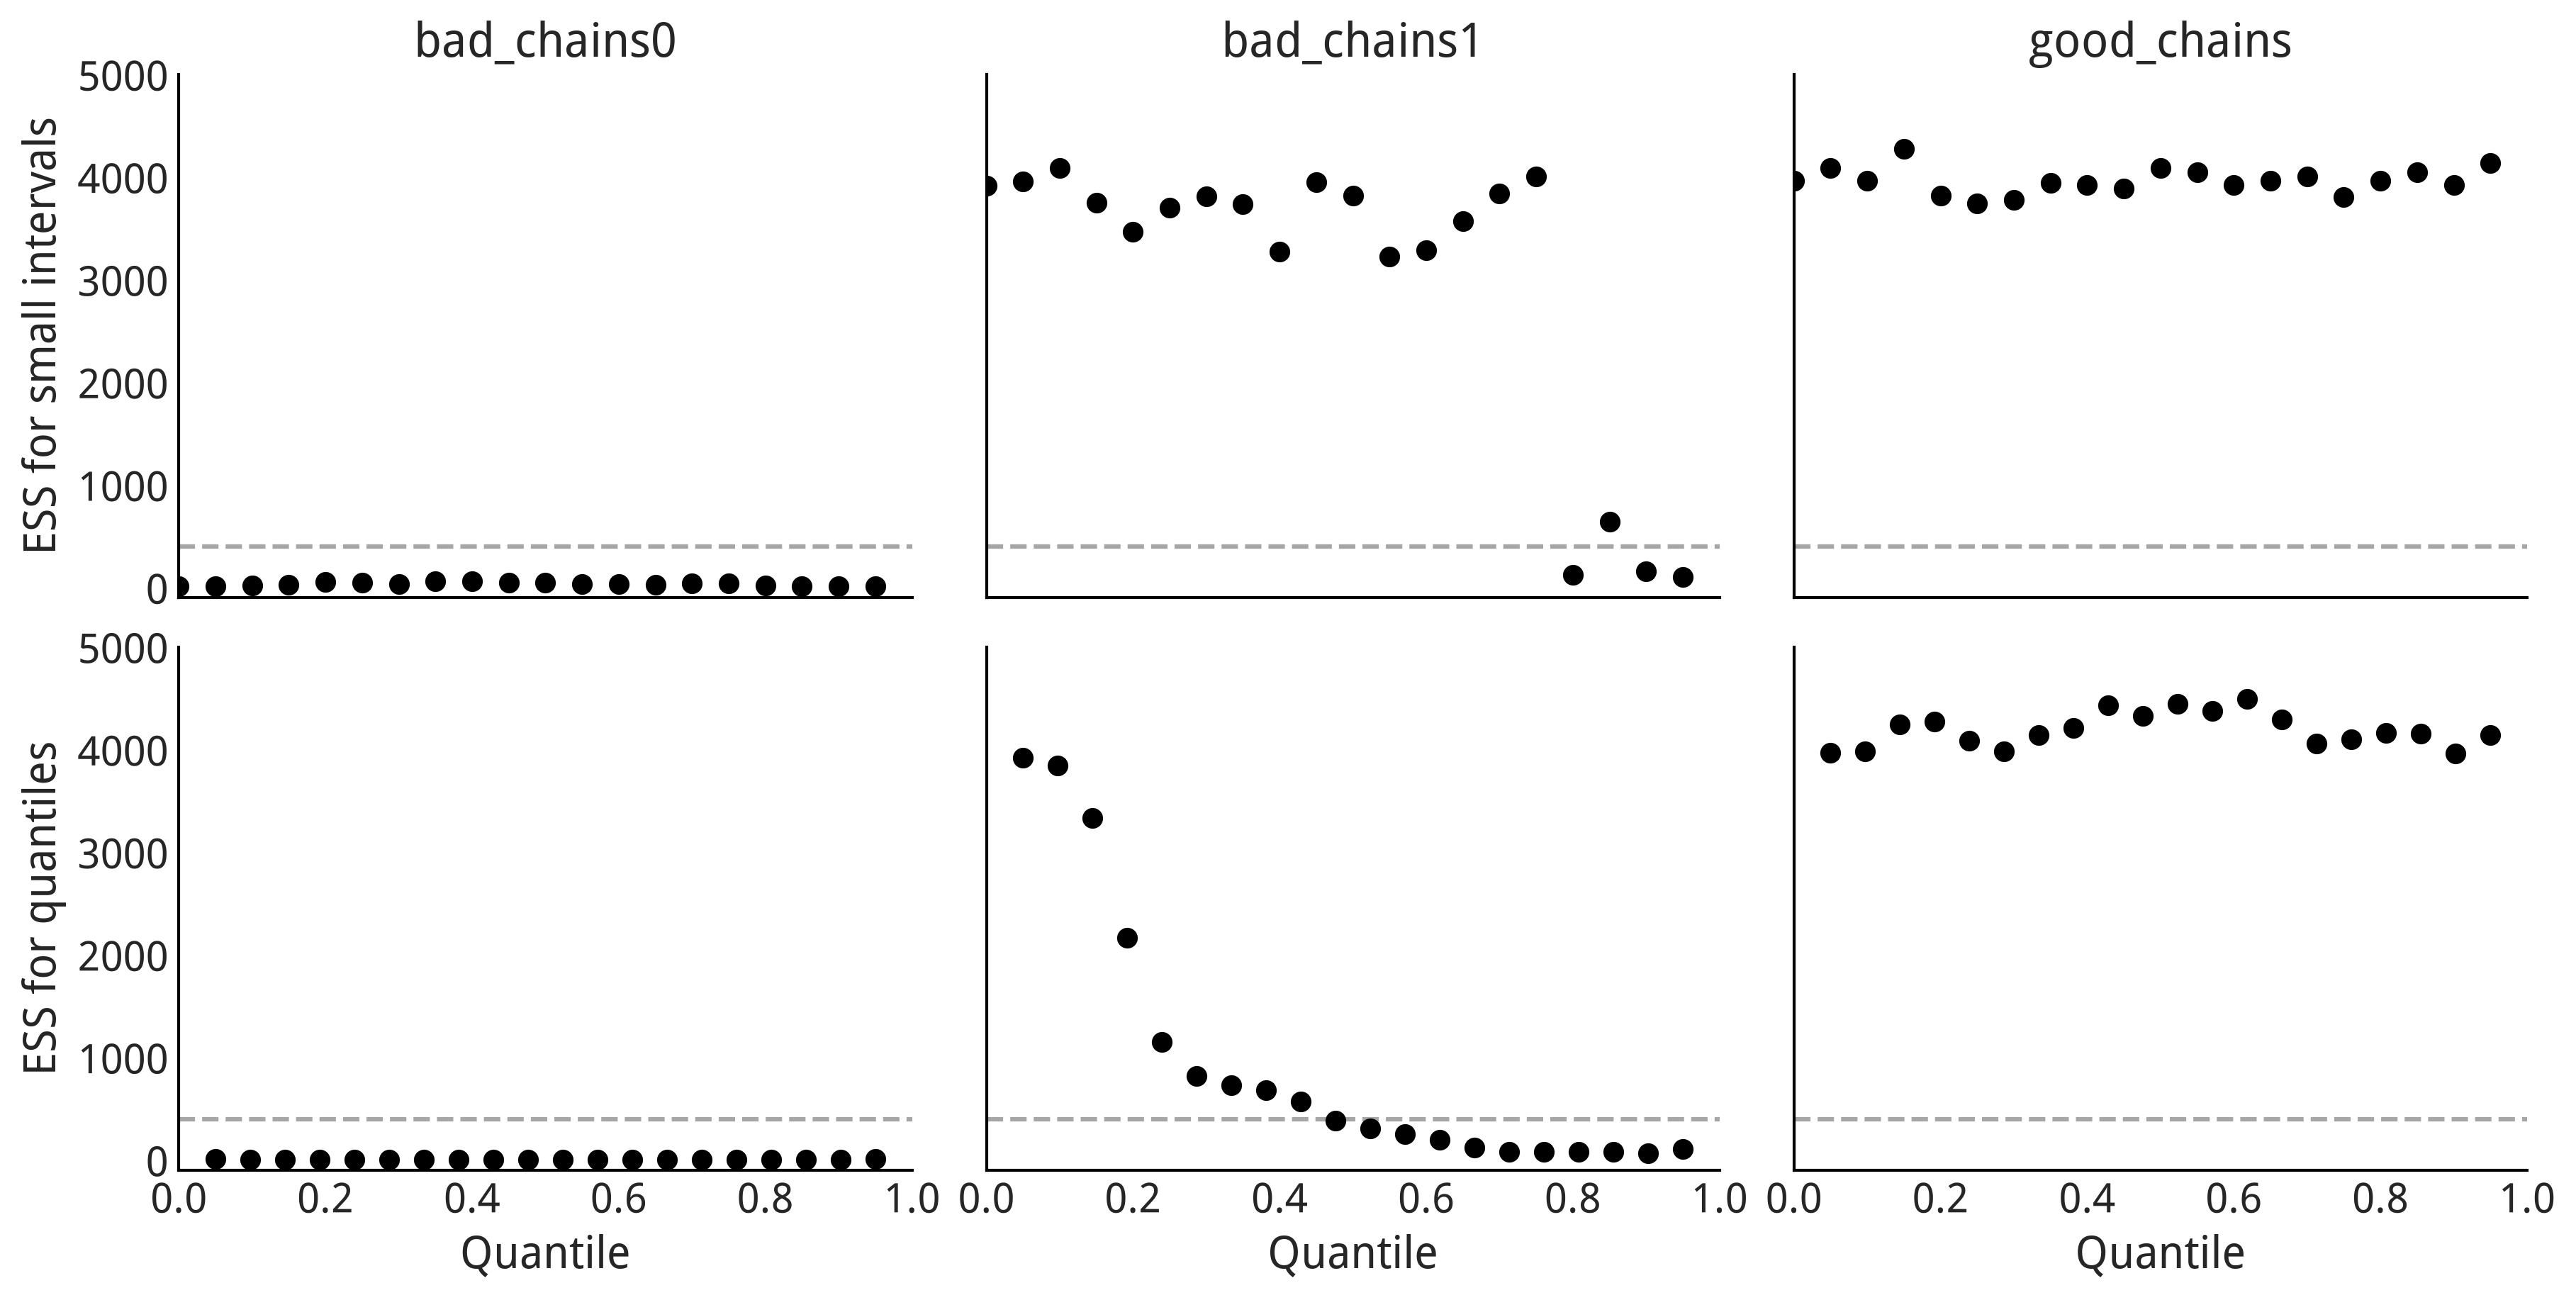

In [15]:
_, axes = plt.subplots(2, 3, figsize=(12, 6), sharey=True, sharex=True)
az.plot_ess(chains, kind="local", ax=axes[0])
az.plot_ess(chains, kind="quantile", ax=axes[1])

for ax_ in axes[0]:
    ax_.set_xlabel("")
for ax_ in axes[1]:
    ax_.set_title("")

for ax_ in axes[:,1:].ravel():
    ax_.set_ylabel("")
plt.ylim(-100, 5000)
plt.savefig("img/chp02/plot_ess.png")



图中的虚线代表建议的最低阈值 400。作为一般经验法则,我们建议 ESS 至少要大于 400,否则 ESS
本身以及后面会介绍的 $\hat R$ 等其他量的估计都会变得不可靠。最后重申一下,我们说 ESS 给出的
是"如果样本真的是 iid,应该有多少个样本",但要小心的是,参数空间不同区域的实际 ESS 值并不
相同——考虑到这个细节,这种直觉理解依然是有用的。

### 潜在尺度缩减因子 $\hat R$

在相当一般的条件下,MCMC 方法在理论上能够保证:不管从哪个起点出发,最终都能得到正确答案。
不幸的是,这个保证的"小字条款"是:它只在样本数趋于无穷时才成立。因此实践中,我们需要一些
方法来评估**有限**样本下的收敛情况。一个普遍的思路是:从差异很大的多个起点分别启动多条链,
然后检查得到的这些链彼此看起来是否"相似"。这种直觉可以被形式化成一个数值诊断指标,叫做
$\hat R$。多年来这个估计量已经过多次改进,存在很多版本。最初 $\hat R$ 被解读为"由于 MCMC
有限采样导致的方差高估程度"——也就是说,如果你继续无限地采样下去,估计的方差应该会以
$\hat R$ 这个倍数继续下降。这也是它"潜在尺度缩减因子"这个名字的由来:目标值是 1,意味着
继续增加样本数,已经无法进一步降低估计的方差。不过在实践中,最好把它单纯当作一个诊断工具
来看待,不必过度解读。

参数 $\theta$ 的 $\hat R$,计算方式大致是:把所有链的样本合在一起算出的标准差,除以各条链
分别算出的链内标准差的均方根。实际计算会更复杂一些,但整体思路是一致的。理想情况下我们应该
得到 1,因为链间方差应该和链内方差相等。从实用角度看,$\hat R \lessapprox 1.01$ 通常被认为
是安全的。

用 ArviZ 的 `az.rhat()` 函数可以计算 $\hat R$ 诊断值:


In [16]:
az.rhat(chains)


<xarray.Dataset> Size: 24B
Dimensions:      ()
Data variables:
    bad_chains0  float64 8B 2.408
    bad_chains1  float64 8B 1.033
    good_chains  float64 8B 1.0
Attributes:
    created_at:     2026-08-23T08:21:27.880161+00:00
    arviz_version:  0.23.4


从结果可以看到,$\hat R$ 正确地把 `good_chains` 识别为好样本,而把 `bad_chains0` 和
`bad_chains1` 识别为存在不同程度问题的样本。`bad_chains0` 完全是一场灾难,而 `bad_chains1`
看起来更接近"勉强合格"的状态,但依然有差距。

### 蒙特卡洛标准误(Monte Carlo Standard Error)

使用 MCMC 方法时,我们引入了额外一层不确定性,因为我们是在用有限数量的样本来近似后验。我们
可以用蒙特卡洛标准误(MCSE)来估计这种误差的大小,它基于马尔可夫链中心极限定理。MCSE 考虑
了样本并非真正相互独立这一事实,实际上是基于 ESS 计算出来的。ESS 和 $\hat R$ 的取值与参数
本身的尺度无关,但要判断 MCSE 是否"足够小",则需要结合领域知识。如果我们想把某个参数估计值
报告到小数点后两位,就需要确保 MCSE 低于第二位小数,否则我们就是在错误地报告一个比实际精度
更高的结果。只有在确认 ESS 足够高、$\hat R$ 足够低之后,才应该去检查 MCSE,否则 MCSE 本身
是没有意义的。

用 ArviZ 的 `az.mcse()` 函数可以计算 MCSE:


In [17]:
az.mcse(chains)


<xarray.Dataset> Size: 24B
Dimensions:      ()
Data variables:
    bad_chains0  float64 8B 0.1077
    bad_chains1  float64 8B 0.01781
    good_chains  float64 8B 0.002381
Attributes:
    created_at:     2026-08-23T08:21:27.914988+00:00
    arviz_version:  0.23.4


和 ESS 一样,MCSE 在参数空间中也会变化,因此我们可能也想对不同区域(比如特定分位数)分别
评估它。此外我们也可能想一次性可视化多个数值,如下图所示。


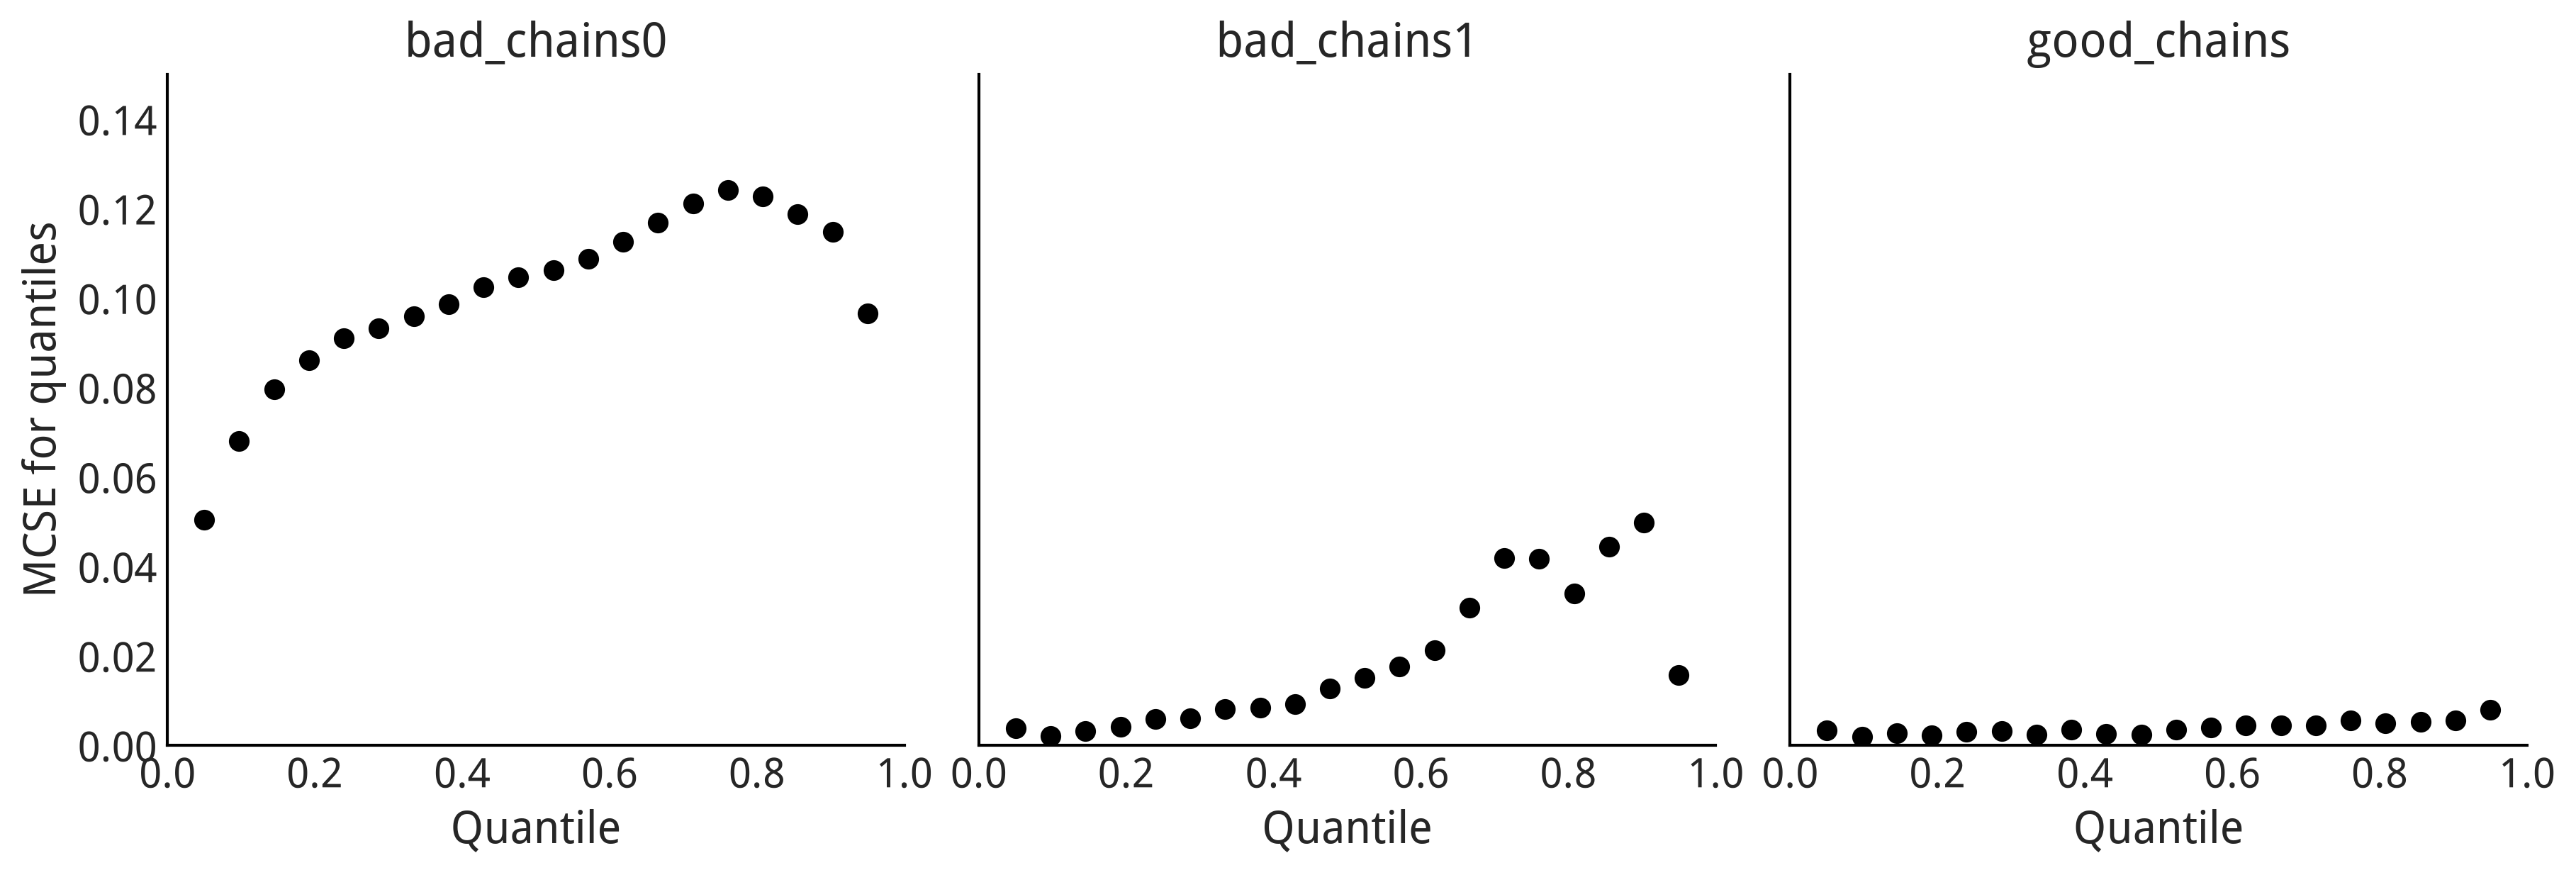

In [18]:
_, axes = plt.subplots(1, 3, figsize=(12, 4), sharey=True)
az.plot_mcse(chains, ax=axes)
for ax_ in axes[1:]:
    ax_.set_ylabel("")
    ax_.set_ylim(0, 0.15)

plt.savefig("img/chp02/plot_mcse.png")



最后,ESS、$\hat R$ 和 MCSE 都可以通过一次调用 `az.summary(.)` 函数得到:


In [19]:
az.summary(chains, kind="diagnostics")


,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
bad_chains0,0.108,0.051,2.0,11.0,2.41
bad_chains1,0.018,0.009,111.0,105.0,1.03
good_chains,0.002,0.002,4389.0,3966.0,1.00



表格第一列是均值(期望)的蒙特卡洛标准误,第二列是标准差的蒙特卡洛标准误 [^10]。接下来是
bulk 和 tail 有效样本量,最后是 $\hat R$ 诊断值。

### 迹图(Trace Plots)

迹图可能是贝叶斯文献里最常见的图了。它们往往是我们做完推断之后画的第一张图,用来直观地检查
"我们得到了什么"。迹图是把每次迭代采样得到的值画出来。从这些图里,我们应该能看出不同的链
是否收敛到了同一个分布,大致感受一下自相关的程度等等。在 ArviZ 中,调用 `az.plot_trace(.)`
函数,右边会得到一张迹图,左边则是样本值分布的表示——连续变量用 KDE,离散变量用直方图。


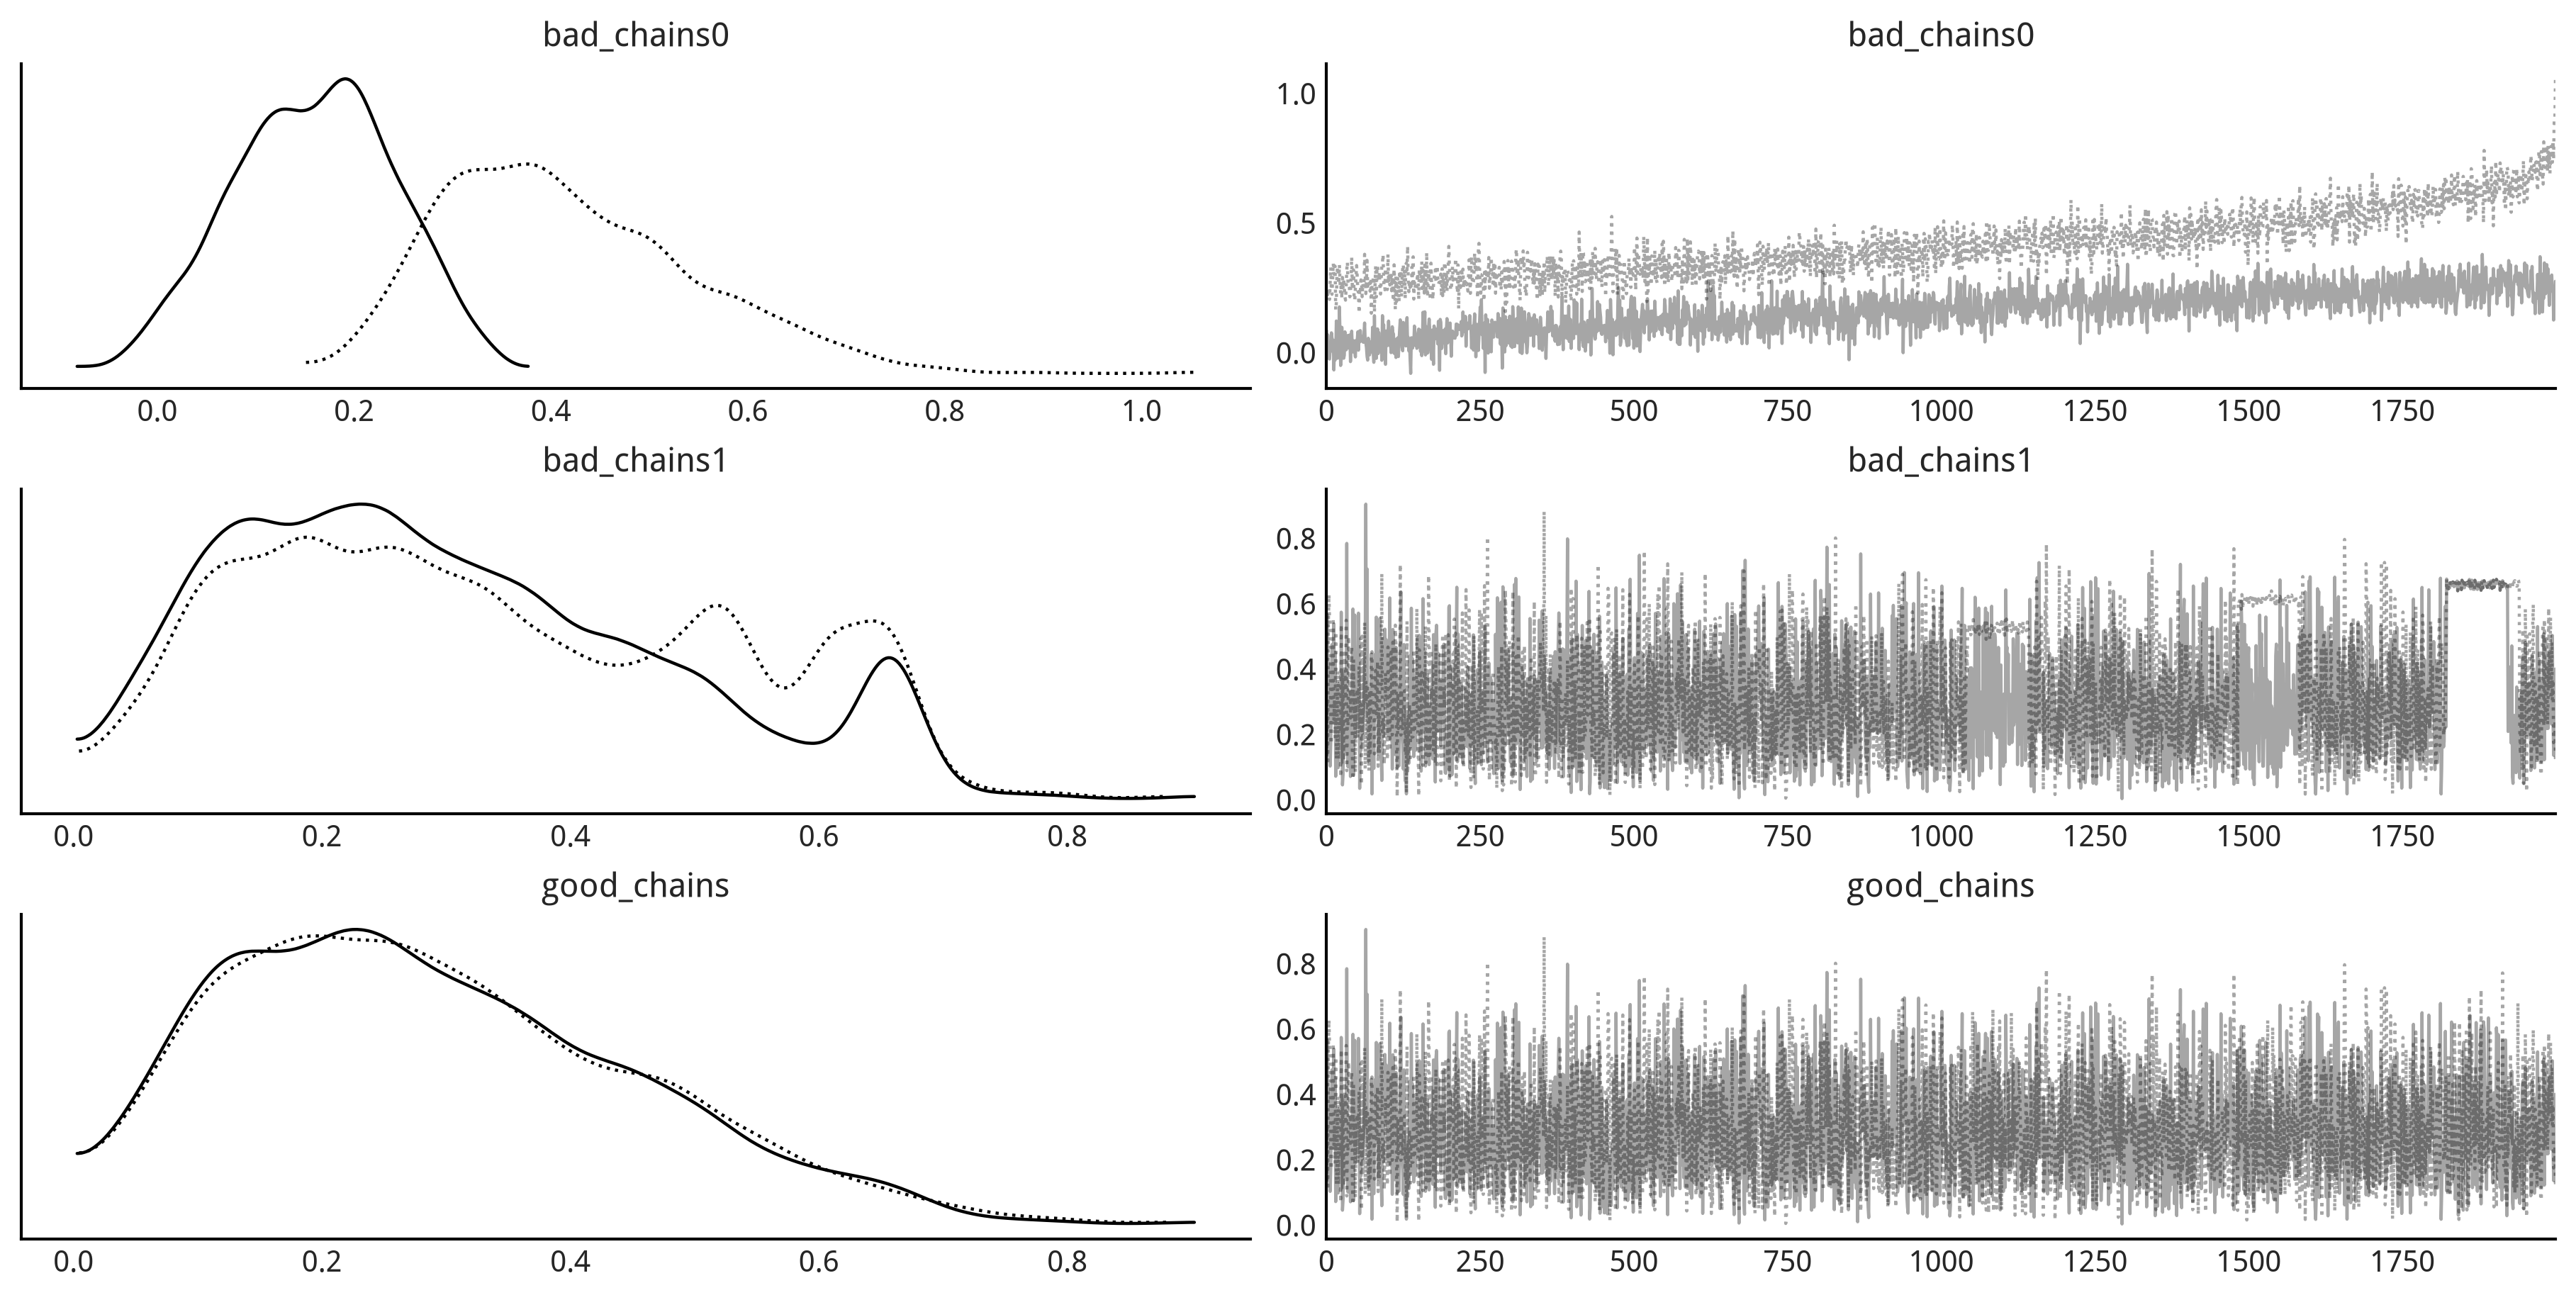

In [20]:
az.plot_trace(chains)
plt.savefig("img/chp02/trace_plots.png")



上图展示了 `chains` 的迹图。从中可以看到,`good_chains` 中的抽样属于同一个分布,两条链之间
只有微小的(随机)差异。当我们按迭代顺序观察抽样值(也就是迹本身)时,可以看到链看起来相当
"嘈杂",没有明显的趋势或规律,也很难分辨出哪条是哪条链——这和 `bad_chains0` 形成了鲜明对比。
对这个样本,我们能清楚地看到两个只有少量重叠的不同分布,从 KDE 和迹图都能一眼看出:两条链在
探索参数空间中两个不同的区域。`bad_chains1` 的情况则更微妙一些。它的 KDE 看起来和
`good_chains` 相似,但两条链之间的差异更明显——到底是 2 个峰还是 3 个峰?两条链给出的分布
似乎并不一致,也许其实只有一个众数,多出来的峰只是伪影!除非我们有理由相信数据中确实存在
(比如由于子群体导致的)多峰分布,否则多出来的峰通常都值得怀疑。它的迹图也和 `good_chains`
有些相似,但仔细观察会发现存在一段段与 x 轴平行的长区间(即长时间保持单调不变)。这清楚地
表明采样器在参数空间的某些区域卡住了,可能是因为后验是多峰的、且峰间存在一段概率极低的
"屏障",也可能是因为参数空间某些区域的曲率与其他区域差异过大。

### 自相关图(Autocorrelation Plots)

正如我们在讨论有效样本量时提到的,自相关会降低样本中实际包含的信息量,因此是我们希望尽量
降低的东西。我们可以用 `az.plot_autocorr` 直接查看自相关情况。


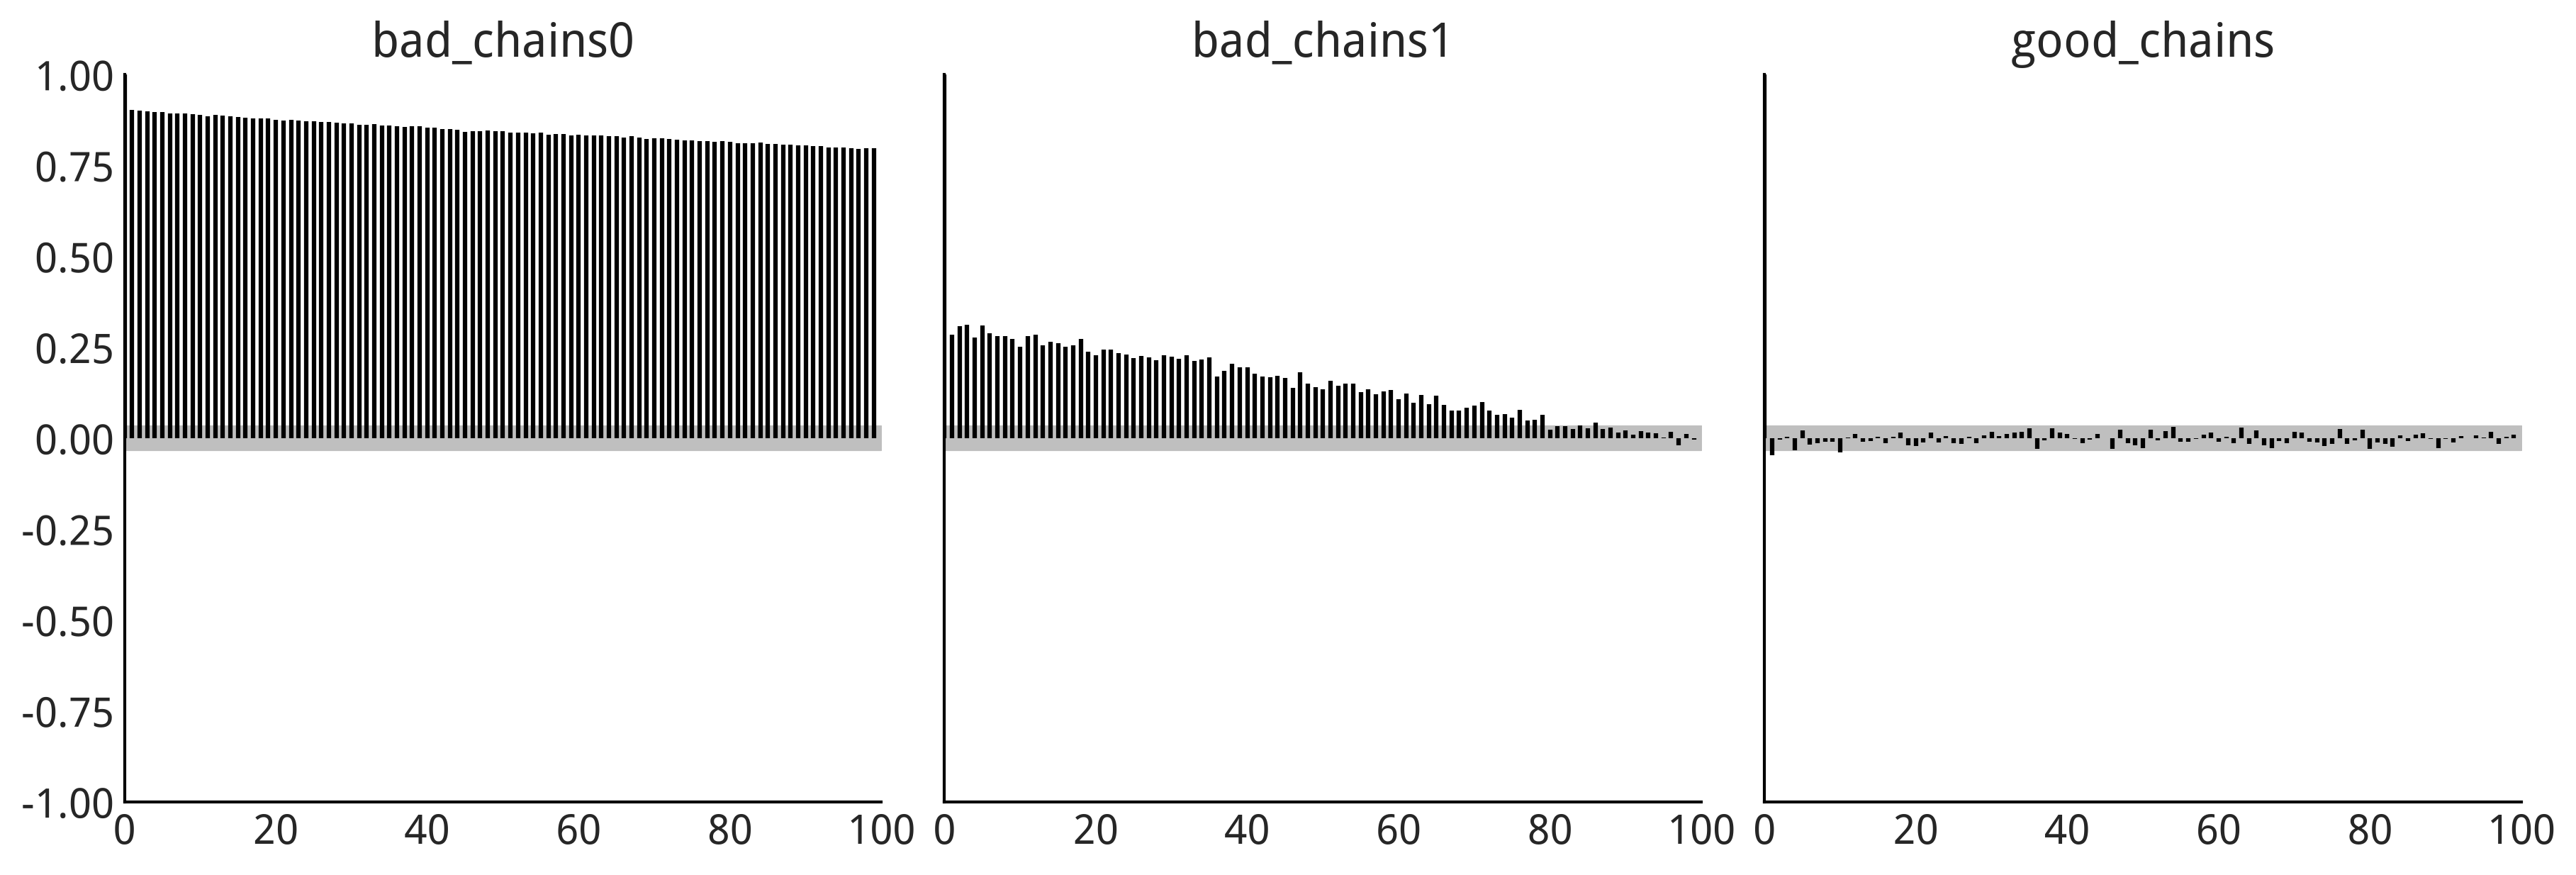

In [21]:
az.plot_autocorr(chains, combined=True, figsize=(12, 4))
plt.savefig('img/chp02/autocorrelation_plot.png')



上图展示的结果,和我们从 `az.ess` 结果中获得的直觉,至少在定性上是吻合的:`good_chains` 的
自相关基本为零,`bad_chains0` 高度相关,`bad_chains1` 虽然没有那么糟糕,但自相关依然明显,
而且是长程的——也就是说,它不会很快衰减到零。

### 秩图(Rank Plots)

秩图是另一种可视化诊断工具,可以用来比较链内和链间的采样表现。简单来说,秩图就是"排过秩的
样本"的直方图。具体做法是:先把所有链合并在一起计算秩次,然后再针对每条链分别画出结果。如果
所有链的目标分布相同,我们期望秩次应该服从均匀分布。此外,如果各条链的秩图看起来彼此相似,
就说明链的混合(mixing)情况良好。


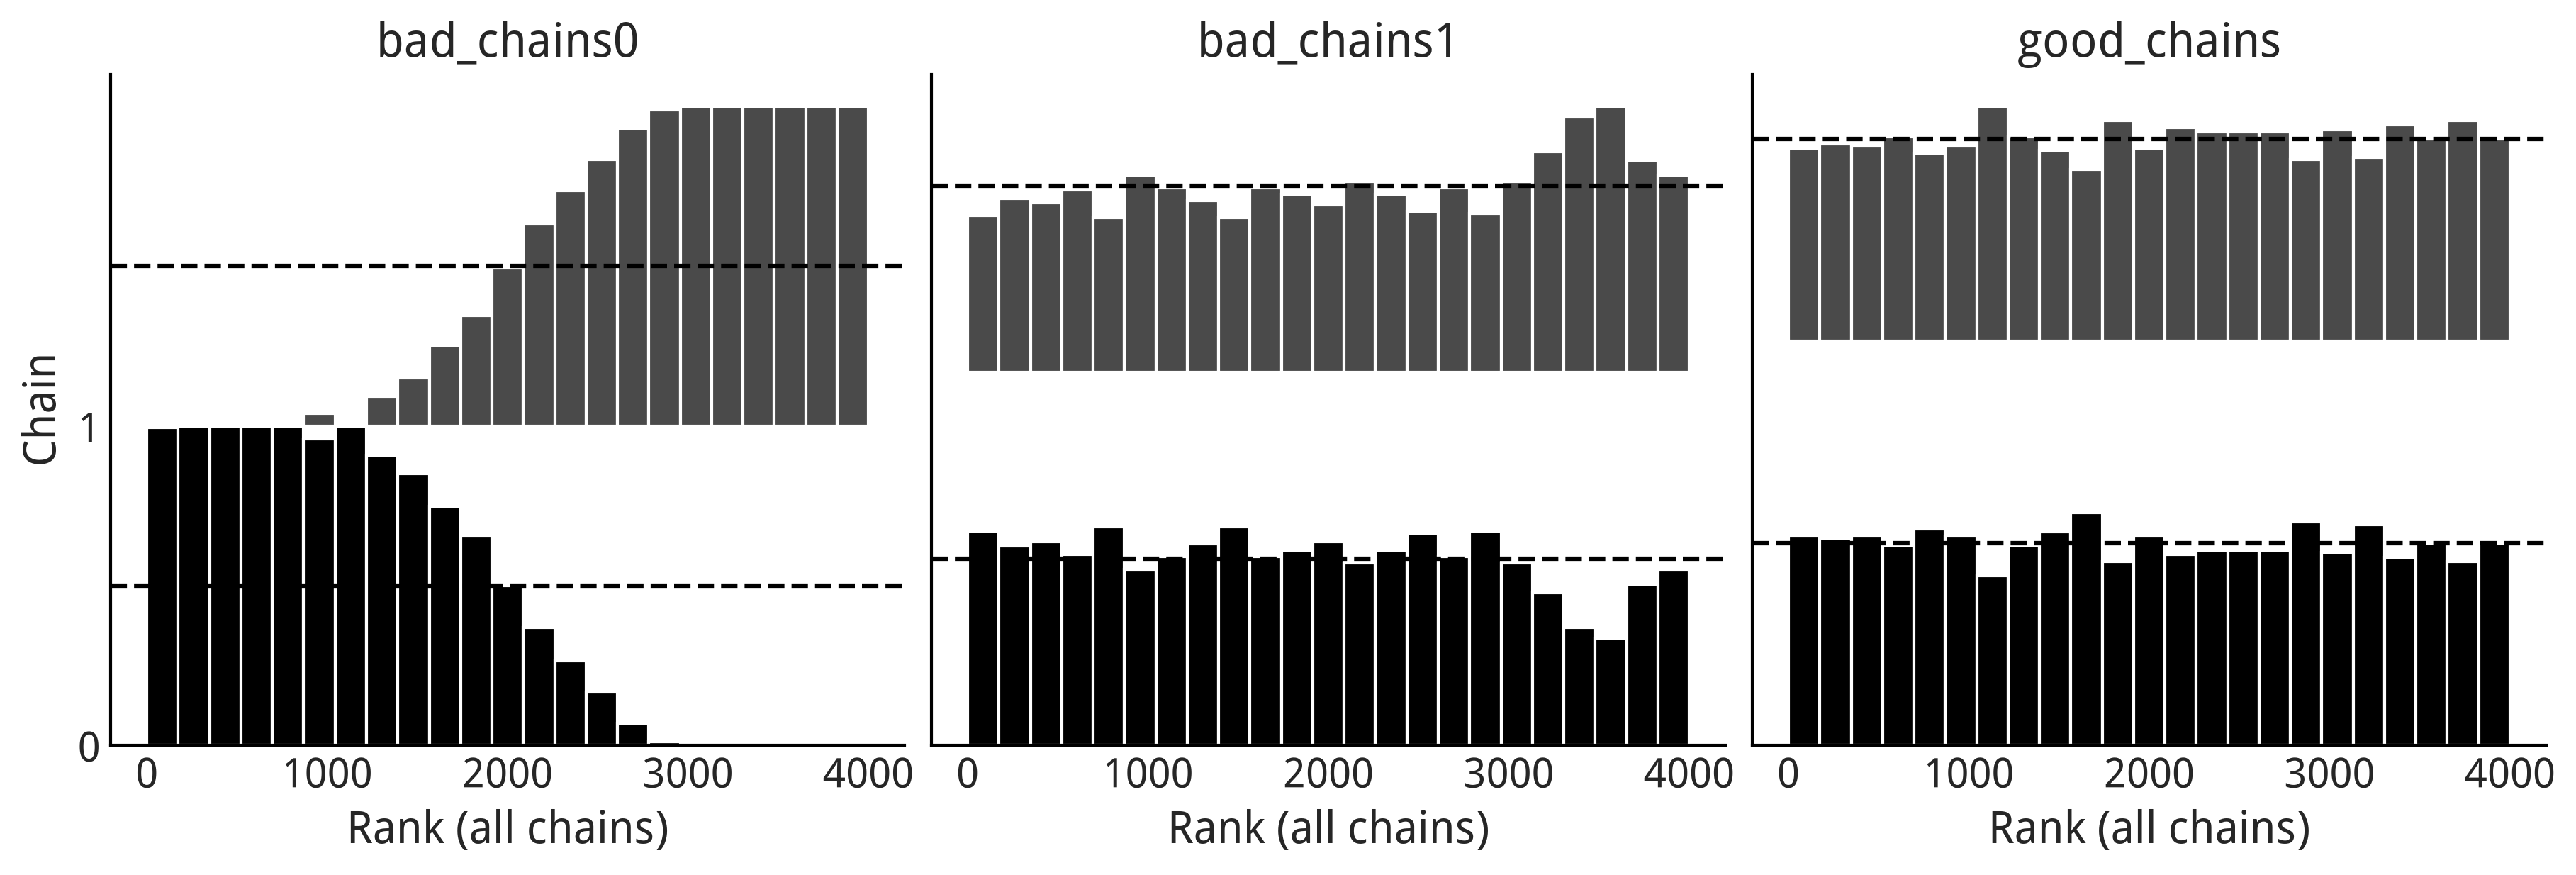

In [22]:
_, axes = plt.subplots(1, 3, figsize=(12, 4))
az.plot_rank(chains, kind="bars", ax=axes)
for ax_ in axes[1:]:
    ax_.set_ylabel("")
    ax_.set_yticks([])

plt.savefig('img/chp02/rank_plot_bars.png')



"柱状"表示法之外的一种替代方案,是用竖线来表示,简称"vlines"。


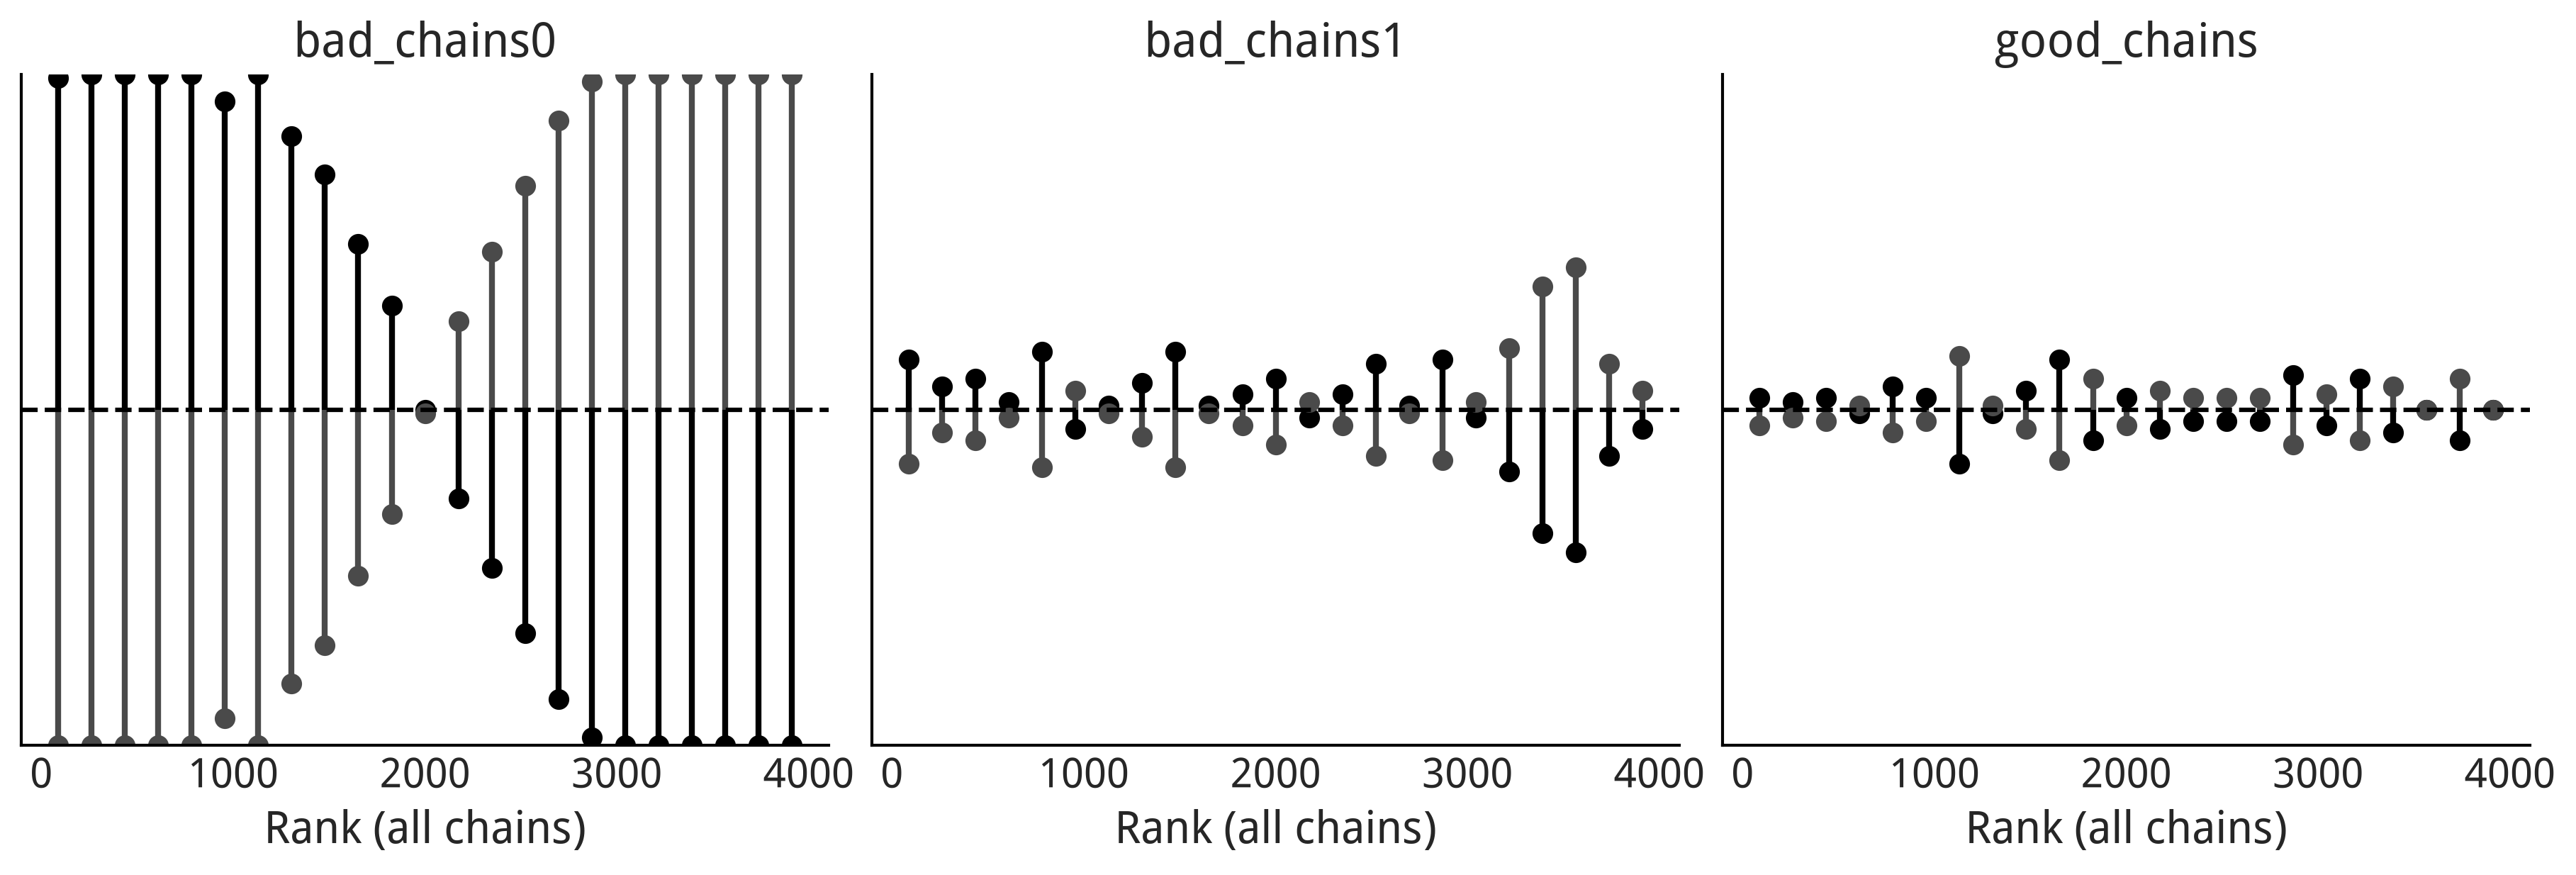

In [23]:
az.plot_rank(chains, kind="vlines", figsize=(12, 4))
plt.savefig('img/chp02/rank_plot_vlines.png')



从上面两幅图可以看到:对 `good_chains`,秩次非常接近均匀分布,两条链看起来彼此相似,没有
明显的规律差异。这和 `bad_chains0` 的结果形成鲜明对比——它的链明显偏离了均匀性,在探索两组
分开的取值,中间秩次附近有一些重叠。注意这和我们构造 `bad_chains0` 的方式、以及它的迹图
所反映的情况是一致的。`bad_chains1` 大体上算是均匀的,但这里那里会有一些较大的偏差,反映出
它的问题比 `bad_chains0` 更"局部化"。

秩图往往比迹图更敏感,因此我们推荐优先使用秩图而不是迹图。可以用
`az.plot_trace(., kind="rank_bars")` 或 `az.plot_trace(., kind="rank_vlines")` 来同时得到
秩图和后验的边缘分布。这类图能帮助我们快速感受后验"长什么样",这在很多情况下有助于发现
采样或模型定义方面的问题——尤其是在建模的早期阶段,当我们对自己到底想要什么还不太确定、
因此需要探索很多不同方案的时候。随着模型逐渐变得合理,我们就可以检查 ESS、$\hat R$ 和 MCSE
是否达标;如果没有达标,就知道模型还需要进一步打磨。

### 发散(Divergences)

到目前为止,我们都是通过研究生成的样本来诊断采样器的表现。另一种诊断方式,是监控采样方法
内部工作机制的行为。其中一个突出的例子,就是某些**哈密顿蒙特卡洛(HMC)**方法中"发散"这一
概念 [^11]。发散(更准确地说是"发散转移",divergent transitions),是诊断样本的一种强大而
敏感的方式,可以作为前面几节介绍的诊断方法的补充。

我们用一个非常简单的模型来讨论发散,书中后面会给出更贴近实际的例子。这个模型由参数 $\theta2$
构成,它服从区间 $[-\theta1, \theta1]$ 上的均匀分布,而 $\theta1$ 本身是从正态分布中采样
得到的。当 $\theta1$ 较大时,$\theta2$ 服从的均匀分布跨度也会很宽;当 $\theta1$ 趋近于零时,
$\theta2$ 的跨度也会趋近于零。用 PyMC 我们可以这样写这个模型(为兼容当前 PyMC 版本,以下把
原书使用的 `testval` 参数换成了等价的 `initval`,并去掉了已被移除的
`return_inferencedata=True` 关键字——PyMC 5.x 起 `pm.sample()` 默认就直接返回
`InferenceData`):


In [24]:
with pm.Model() as model_0:
    θ1 = pm.Normal("θ1", 0, 1, initval=0.1)
    θ2 = pm.Uniform("θ2", -θ1, θ1)
    idata_0 = pm.sample(
        draws=DRAWS, tune=TUNE, chains=CHAINS, cores=1,
        random_seed=RANDOM_SEED)

with pm.Model() as model_1:
    θ1 = pm.HalfNormal("θ1", 1 / (2/np.pi)**0.5)
    θ2 = pm.Uniform("θ2", -θ1, θ1)
    idata_1 = pm.sample(
        draws=DRAWS, tune=TUNE, chains=CHAINS, cores=1,
        random_seed=RANDOM_SEED)

with pm.Model() as model_1bis:
    θ1 = pm.HalfNormal("θ1", 1 / (2/np.pi)**0.5)
    θ2 = pm.Uniform("θ2", -θ1, θ1)
    idata_1bis = pm.sample(
        draws=DRAWS, tune=DIAGNOSTIC_TUNE, chains=CHAINS, cores=1,
        target_accept=0.99, random_seed=RANDOM_SEED)

idatas = [idata_0, idata_1, idata_1bis]


Initializing NUTS using jitter+adapt_diag...


Sequential sampling (4 chains in 1 job)


NUTS: [θ1, θ2]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 119 seconds.


...

Initializing NUTS using jitter+adapt_diag...


Sequential sampling (4 chains in 1 job)


NUTS: [θ1, θ2]


Output()

Sampling 4 chains for 1_500 tune and 1_000 draw iterations (6_000 + 4_000 draws total) took 236 seconds.



> **ArviZ 的 InferenceData 格式**:`az.InferenceData` 是专为 MCMC 贝叶斯用户设计的一种
> 数据格式,基于灵活的多维数组库 xarray 构建。它的主要目的,是提供一种便捷的方式来存储和
> 操作贝叶斯工作流中产生的各类信息,包括来自后验、先验、后验预测、先验预测等各种分布的样本,
> 以及采样过程中产生的其他信息和诊断量。`InferenceData` 用"组(groups)"这个概念,把所有
> 这些信息组织起来。本书会大量使用 `az.InferenceData`,用它来存储贝叶斯推断结果、计算诊断量、
> 生成图表,以及读写磁盘文件。完整的技术规范和 API,请参阅 ArviZ 官方文档。

注意,`model_0` 中的模型并没有对任何观测数据做条件化,这意味着 `model_0` 描述的是一个由
`θ1` 和 `θ2` 两个未知量参数化的(先验)分布。你可能还注意到我们加上了参数 `initval=0.1`
(对应原书中已废弃的 `testval` 参数)。这是为了告诉 PyMC 从某个特定的值($0.1$)开始采样,
而不是用默认值。默认情况下 $\theta1 = 0$,而在这个值上 $\theta2$ 的概率密度函数是一个狄拉克
delta 函数 [^12],会产生错误。使用 `initval=0.1` 只影响采样的初始化方式。

在下图中,可以看到 `model_0` 的 KDE 底部有一些竖直的短线,每一条都代表一次发散,意味着采样
过程中出了问题。用 `az.plot_pair(., divergences=True)` 也能看到类似的现象,如下下图所示,
发散点用蓝色圆点表示——而且这里到处都是!


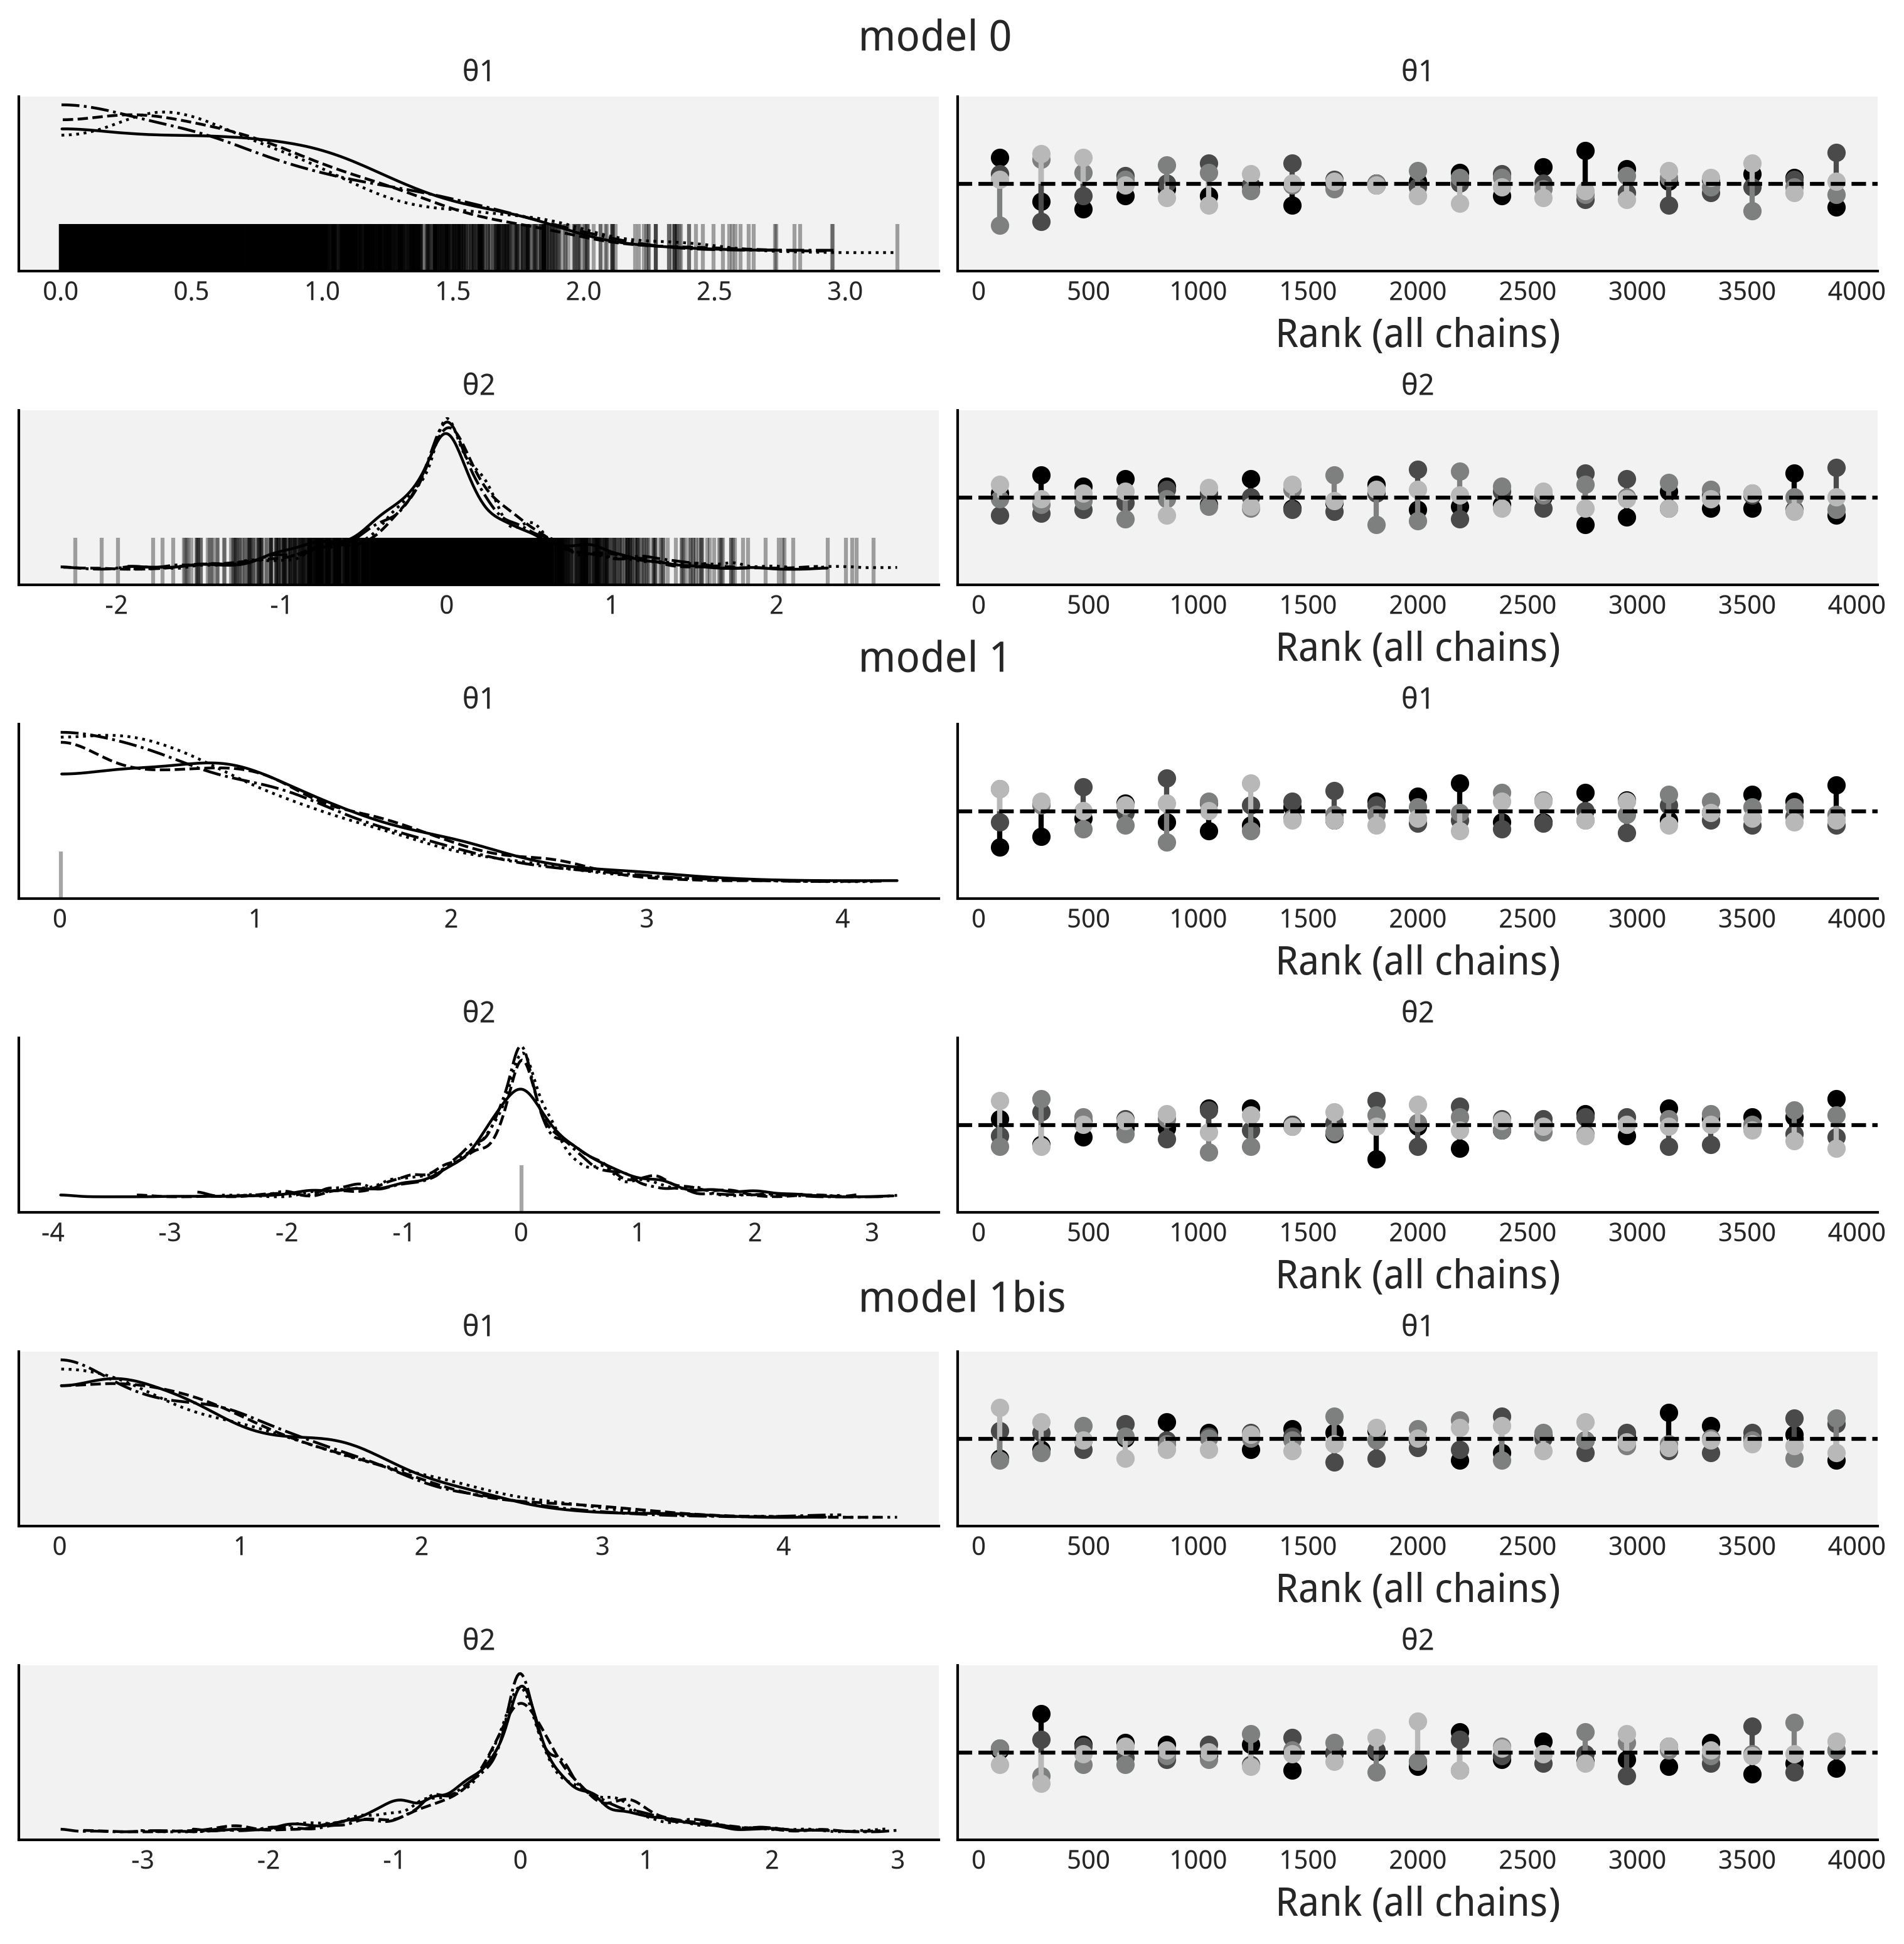

In [25]:
fig, axes = plt.subplots(6, 2, figsize=(10, 10))

axes = axes.reshape(3, 2, 2)
for idata, ax, color in zip(idatas, axes, ["0.95", "1", "0.95"]):
    az.plot_trace(idata, kind="rank_vlines", axes=ax);
    [ax_.set_facecolor(color) for ax_ in ax.ravel()]
fig.text(0.45, 1, s="model 0", fontsize=16)
fig.text(0.45, 0.67, s="model 1", fontsize=16)
fig.text(0.45, 0.33, s="model 1bis", fontsize=16)
plt.savefig("img/chp02/divergences_trace.png", bbox_inches="tight")


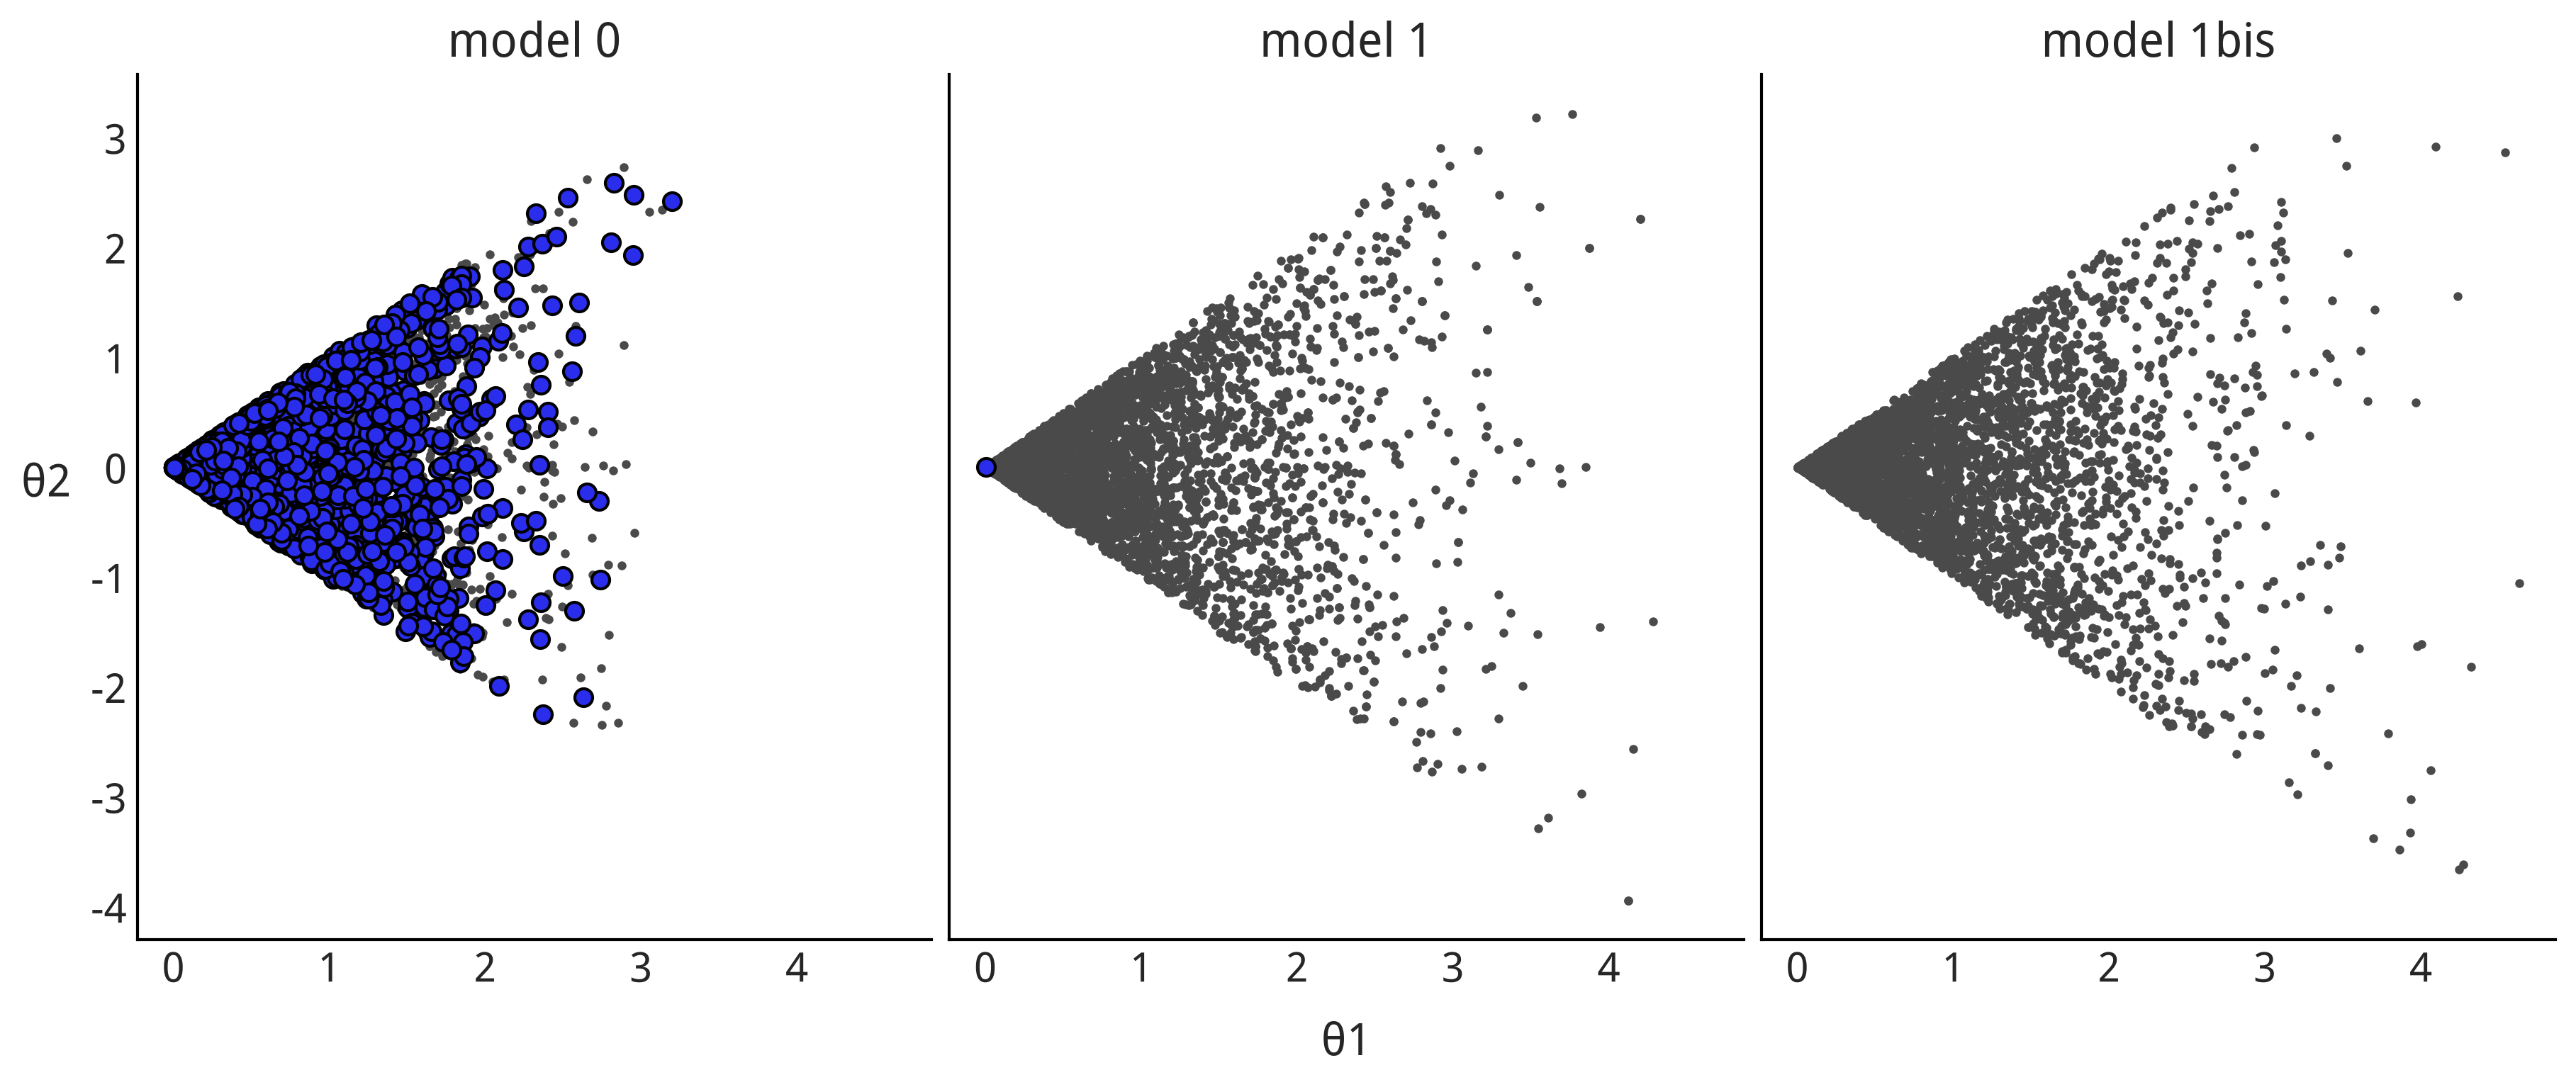

In [26]:
_, axes = plt.subplots(1, 3, figsize=(12, 5), sharex=True, sharey=True)

for idata, ax, model in zip(idatas, axes, ["model 0", "model 1", "model 1bis"]):
    az.plot_pair(idata, divergences=True, scatter_kwargs={"color":"C1"}, divergences_kwargs={"color":"C4"}, ax=ax)
    ax.set_xlabel("")
    ax.set_ylabel("")
    ax.set_title(model)
axes[0].set_ylabel('θ2', rotation=0, labelpad=15)
axes[1].set_xlabel('θ1', labelpad=10)
plt.savefig("img/chp02/divergences_pair.png")



`model_0` 显然存在问题。仔细看一下 `model_0` 的定义就会发现,我们把它写得有点古怪:$\theta1$
是一个以 0 为中心的正态分布,因此我们应该预期大约一半的取值会是负数,但对负值而言,$\theta2$
就会被定义在区间 $[\theta1, -\theta1]$ 上,这至少有点奇怪。于是我们尝试对模型做**重参数化**
(reparameterize),也就是用一种不同但数学上等价的方式来表达模型——比如可以这样写(即
`model_1`):把 $\theta1$ 换成半正态分布,这样它就永远会给出合理的值,可以放心地用来定义
$\theta2$。注意我们把 $\theta1$ 的标准差参数设为 $\frac{1}{\sqrt{(1-\frac{2}{\pi})}}$
而不是直接用 1,原因是半正态分布的标准差是 $\sigma \sqrt{(1-\frac{2}{\pi})}$,其中 $\sigma$
是半正态分布的尺度参数——换句话说,$\sigma$ 是"展开前"那个正态分布的标准差,而不是半正态
分布本身的标准差。

上面已经用重参数化后的 `model_1`(以及进一步调大 `target_accept` 的 `model_1bis`)重新
拟合了模型。从上面两幅图可以看到,`model_1` 的发散数量已经大幅减少,但依然能看到零星几个。
一个可以尝试减少发散的简单办法,是调高 `target_accept` 的值——默认是 0.8,合法的最大值是 1。
`model_1bis` 和 `model_1` 的区别,是进一步增加调优步数,并把这个采样参数改成了
`pm.sample(., target_accept=0.99)`。

> **中文版现代化说明**: 原书示例使用 `target_accept=0.95`;在当前 PyMC 与本书固定随机种子的
> 发布执行中,该设置仍偶尔产生少量发散。中文版采用 0.99,并在 smoke/release 档分别使用 300/1500
> 次调优迭代,使本例所声称的“消除发散”与实际生成的诊断结果一致。调高该参数不是通用修复方法;
> 真实分析仍应优先检查模型几何、重参数化方式、R-hat 与 ESS。

可以看到,这样一来我们终于把所有发散都消除了。这已经是
好消息了,但要真正信任这些样本,我们仍然需要按前面几节的方法检查 $\hat R$ 和 ESS。

> **重参数化**:重参数化可以把一个难以采样的后验几何形状,转变成一个更容易采样的形状。这样
> 做有助于消除发散,但即便没有发散,重参数化也同样有用——例如可以用它来加快采样速度,或者
> 在不增加计算成本的前提下提高有效样本数。此外,重参数化还有助于更好地解释或传达模型及其
> 结果(可以回想一下"共轭先验"一节里 Alice 和 Bob 的例子)。

### 采样器参数与其他诊断

大多数采样方法都有影响采样表现的超参数。虽然大多数概率编程语言都会尽量选用合理的默认值,但
实践中,默认值并不会对所有数据和模型的组合都奏效。正如前面几节所见,有时候调大 `target_accept`
参数就能消除发散(比如发散是由数值精度问题引起的时候)。还有一些其他的采样器参数,也可能对
采样问题有帮助,比如我们可能想增加用于调优 MCMC 采样器的迭代次数。PyMC 中默认是
`pm.sample(., tune=1000)`。在调优阶段,采样器的参数会被自动调整。有些模型更复杂,需要更多
轮次的迭代,采样器才能学到更好的参数。因此增加调优步数,有助于提高 ESS 或降低 $\hat R$。增加
抽样数量也可能有助于收敛,但一般来说其他途径往往更有效果。如果一个模型用几千次抽样都无法
收敛,那么用 10 倍的抽样量通常依然会失败,或者即便有改善也很难值回额外的计算成本。重参数化、
改进模型结构、使用信息量更大的先验,乃至干脆更换模型,往往会更有效 [^13]。值得一提的是,在
建模的早期阶段,我们完全可以用相对较少的抽样次数,先测试模型能否跑通、我们是否真的写出了
想要的模型、结果是否大致合理——这种初步检查一般 200 到 300 次抽样就够了。等我们对模型更有
信心之后,再把抽样数增加到几千(比如 2000 或 4000)。

除了本章介绍的这些诊断方法之外,还存在其他诊断工具,比如平行坐标图(parallel plots)和
分离图(separation plots)。这些诊断都各有用武之地,但限于篇幅本节没有展开介绍。想了解更多,
建议查阅 ArviZ 文档和绘图图库(plot gallery),里面有更多例子。

## 模型比较

通常我们想搭建的模型,既不能太简单以至于丢失数据中的有价值信息,也不能太复杂以至于把数据中
的噪声也拟合进去。找到这个"甜蜜点"是一项复杂的任务:一部分原因是并不存在唯一的"最优"判定
标准,一部分原因是这样的最优解可能压根不存在,还有一部分原因是实践中我们只能从有限的一组
模型里、基于有限的数据集来做选择。

不过我们依然可以尝试找到一些通用的好策略。一个有用的方案,是计算**泛化误差(generalization
error)**,也叫**样本外预测精度(out-of-sample predictive accuracy)**——它衡量的是模型
预测"未用于拟合它的数据"的表现有多好。理想情况下,任何预测精度的度量都应该考虑具体问题的
细节,包括模型预测所带来的收益和成本,也就是说应该用一种决策理论的方式来处理。但我们也可以
依赖一些适用于广泛模型和问题的通用工具,这类工具有时被称为"评分规则(scoring rules)",因为
它们帮助我们给模型打分、排序。在众多可能的评分规则中,已有研究表明对数评分规则拥有非常好的
理论性质,因此被广泛使用。在贝叶斯设定下,对数评分规则可以按如下方式计算:

$$
\text{ELPD} = \sum_{i=1}^{n} \int p_t(\tilde y_i) \; \log p(\tilde y_i \mid y_i) \; d\tilde y_i
$$

其中 $p_t(\tilde y_i)$ 是 $\tilde y_i$ 真实数据生成过程的分布,$p(\tilde y_i \mid y_i)$
是后验预测分布。上式定义的量被称为**期望逐点对数预测密度(expected log pointwise
predictive density, ELPD)**——"期望"是因为我们是在对真实数据生成过程积分,也就是对该过程
可能生成的所有数据集积分;"逐点"是因为我们是针对 $n$ 个观测值逐一计算($y_i$)。为简单起见,
不论是连续还是离散模型,我们都统一用"密度"这个词来称呼 [^14]。

在实际问题中,我们并不知道 $p_t(\tilde y_i)$,因此上面这个 ELPD 定义式并不能直接使用。实践
中我们转而计算:

$$
\sum_{i=1}^{n} \log \int \ p(y_i \mid \boldsymbol{\theta}) \; p(\boldsymbol{\theta} \mid y) d\boldsymbol{\theta}
$$

这个量(或者乘以某个常数之后)通常被称为**偏差(deviance)**,在贝叶斯和非贝叶斯语境下都
有使用 [^15]。当似然是高斯分布时,这个量会正比于均方误差。

要计算这个量,我们用的是拟合模型时用过的同一份数据,因此平均而言我们会**高估** ELPD(相对
于前面严格定义的那个式子),这会导致我们倾向于选出容易过拟合的模型。好在有几种方法可以给出
更好的 ELPD 估计,其中之一就是交叉验证,我们下一节会介绍。

### 交叉验证与 LOO

交叉验证(CV)是估计样本外预测精度的一种方法。这个方法需要把模型重新拟合很多次,每次都排除
掉数据中不同的一部分。被排除的那部分随后用来衡量模型的精度。这个过程会重复很多次,模型的
估计精度就是所有轮次结果的平均值。之后再用完整数据集把模型拟合一次,这个最终模型才是用于
后续分析和/或预测的模型。我们可以把 CV 看作是一种在"用上全部数据"的同时,模拟或近似样本外
统计量的方法。

留一交叉验证(Leave-one-out cross-validation, LOO-CV)是交叉验证的一种特殊形式,每次排除的
数据只有单个数据点。用 LOO-CV 计算出的 ELPD 记为 $\text{ELPD}_\text{LOO-CV}$:

$$
\text{ELPD}_\text{LOO-CV} = \sum_{i=1}^{n} \log
    \int \ p(y_i \mid \boldsymbol{\theta}) \; p(\boldsymbol{\theta} \mid y_{-i}) d\boldsymbol{\theta}
$$

直接计算这个式子的代价很容易变得过高,因为实践中我们并不知道 $\boldsymbol{\theta}$,因此
需要计算 $n$ 个后验,也就是和数据集中观测值数量一样多的
$\boldsymbol{\theta_{-i}}$。好在我们可以用一种叫做 Pareto 平滑重要性采样留一交叉验证
(PSIS-LOO-CV)的方法,只用一次拟合就近似出 $\text{ELPD}_\text{LOO-CV}$。为简洁起见,也为了
和 ArviZ 保持一致,本书把这个方法简称为 LOO。需要记住的是,我们讨论的其实是 PSIS-LOO-CV,
除非另有说明,本书提到 ELPD 时,指的都是用这个方法估计出来的 ELPD。

ArviZ 提供了很多与 LOO 相关的函数,用起来很简单,但要理解结果可能需要多留一点心。为了说明
如何解读这些函数的输出,我们用 3 个简单模型来演示:


In [27]:
np.random.seed(90210)


In [28]:
y_obs =  np.random.normal(0, 1, size=100)
idatas_cmp = {}

# 用固定均值、固定偏度、随机标准差的偏正态似然生成数据
with pm.Model() as mA:
    σ = pm.HalfNormal("σ", 1)
    y = pm.SkewNormal("y", mu=0, sigma=σ, alpha=1, observed=y_obs)
    idataA = pm.sample(
        draws=DRAWS, tune=TUNE, chains=CHAINS, cores=1,
        random_seed=RANDOM_SEED,
        idata_kwargs={"log_likelihood": True})
    idataA.extend(pm.sample_posterior_predictive(
        idataA, random_seed=RANDOM_SEED))
    idatas_cmp["mA"] = idataA

# 用固定均值、随机标准差的正态似然生成数据
with pm.Model() as mB:
    σ = pm.HalfNormal("σ", 1)
    y = pm.Normal("y", 0, σ, observed=y_obs)
    idataB = pm.sample(
        draws=DRAWS, tune=TUNE, chains=CHAINS, cores=1,
        random_seed=RANDOM_SEED,
        idata_kwargs={"log_likelihood": True})
    idataB.extend(pm.sample_posterior_predictive(
        idataB, random_seed=RANDOM_SEED))
    idatas_cmp["mB"] = idataB

# 用随机均值、随机标准差的正态似然生成数据
with pm.Model() as mC:
    μ = pm.Normal("μ", 0, 1)
    σ = pm.HalfNormal("σ", 1)
    y = pm.Normal("y", μ, σ, observed=y_obs)
    idataC = pm.sample(
        draws=DRAWS, tune=TUNE, chains=CHAINS, cores=1,
        random_seed=RANDOM_SEED,
        idata_kwargs={"log_likelihood": True})
    idataC.extend(pm.sample_posterior_predictive(
        idataC, random_seed=RANDOM_SEED))
    idatas_cmp["mC"] = idataC


Initializing NUTS using jitter+adapt_diag...


Sequential sampling (4 chains in 1 job)


NUTS: [σ]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 337 seconds.


...

NUTS: [μ, σ]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 41 seconds.


Sampling: [y]


Output()


要计算 LOO,我们只需要后验样本 [^16]。之后就可以调用 `az.loo(.)`,它可以为单个模型计算 LOO。
实践中更常见的是同时对两个或更多模型计算 LOO,因此更常用的是 `az.compare(.)` 函数。下表就是
用 `az.compare(idatas_cmp)` 生成的。


In [29]:
cmp = az.compare(idatas_cmp)
cmp.round(2)


,rank,elpd_loo,p_loo,elpd_diff,weight,se,dse,warning,scale
mB,0,-137.87,0.97,0.00,1.0,7.07,0.00,False,log
mC,1,-138.49,1.91,0.62,0.0,7.02,0.86,False,log
mA,2,-168.07,1.37,30.20,0.0,10.37,6.57,False,log



表中列很多,我们逐一说明含义:

1. 第一列是索引,列出了传给 `az.compare(.)` 的字典中各模型的名字(键)。
2. `rank`:模型的排名,从 0(预测精度最高的模型)到模型总数。
3. `elpd_loo`:ELPD 的取值列表。数据框总是按 ELPD 从优到劣排序。
4. `p_loo`:惩罚项的取值列表。可以粗略地把它理解为"估计的有效参数个数"(但不要太当真)。
   对结构更丰富的模型(比如层级模型),这个值可能低于模型实际的参数个数;而当模型预测能力
   很弱、可能存在严重的模型误设时,这个值也可能远高于实际参数个数。
5. `elpd_diff`:每个模型的 ELPD 值,与排名最高模型的 ELPD 值之间的相对差异列表。因此第一名
   模型这一列必然是 0。
6. `weight`:分配给每个模型的预测组合权重,详见“模型平均”一节。它的具体含义取决于
   `az.compare(.)` 采用的方法;默认的堆叠权重以组合后的样本外预测表现为优化目标,不等同于
   “模型为真”的后验概率。
7. `se`:ELPD 计算的标准误。
8. `dse`:两个模型 ELPD 差值的标准误。`dse` 不一定等于 `se`,因为不同模型之间 ELPD 的不确定
   性可能是相关的。排名最高的模型这一列的 `dse` 恒为 0。
9. `warning`:如果为 `True`,说明 LOO 近似可能不可靠。
10. `scale`:所报告数值的尺度。默认是对数尺度(log)。其他选项包括 deviance(即对数得分
    乘以 -2,这会反转排序方向:ELPD 越低越好)和 negative-log(对数得分乘以 -1,和 deviance
    一样,数值越低越好)。

    中文版现代化说明:较早版本的 ArviZ 把第 5、10 两列分别叫作 `d_loo` 与 `loo_scale`;
    当前 ArviZ（本书使用的版本）已将它们重命名为 `elpd_diff` 与 `scale`，第 3 列也相应地
    叫作 `elpd_loo` 而非 `loo`。下文提到这些列名之处已同步更新。

我们也可以把表格里的部分信息用图形表示出来,如下图所示。模型同样按预测精度从高到低排列。
空心点代表 `elpd_loo` 的值,黑色实心点是未经 `p_loo` 惩罚项调整的预测精度。黑色线段代表 LOO 计算
的标准误 `se`。灰色线段以三角形为中心,代表每个模型与最优模型之间 LOO 差值的标准误 `dse`。
我们可以看到 `mB` $\approx$ `mC` $>$ `mA`。


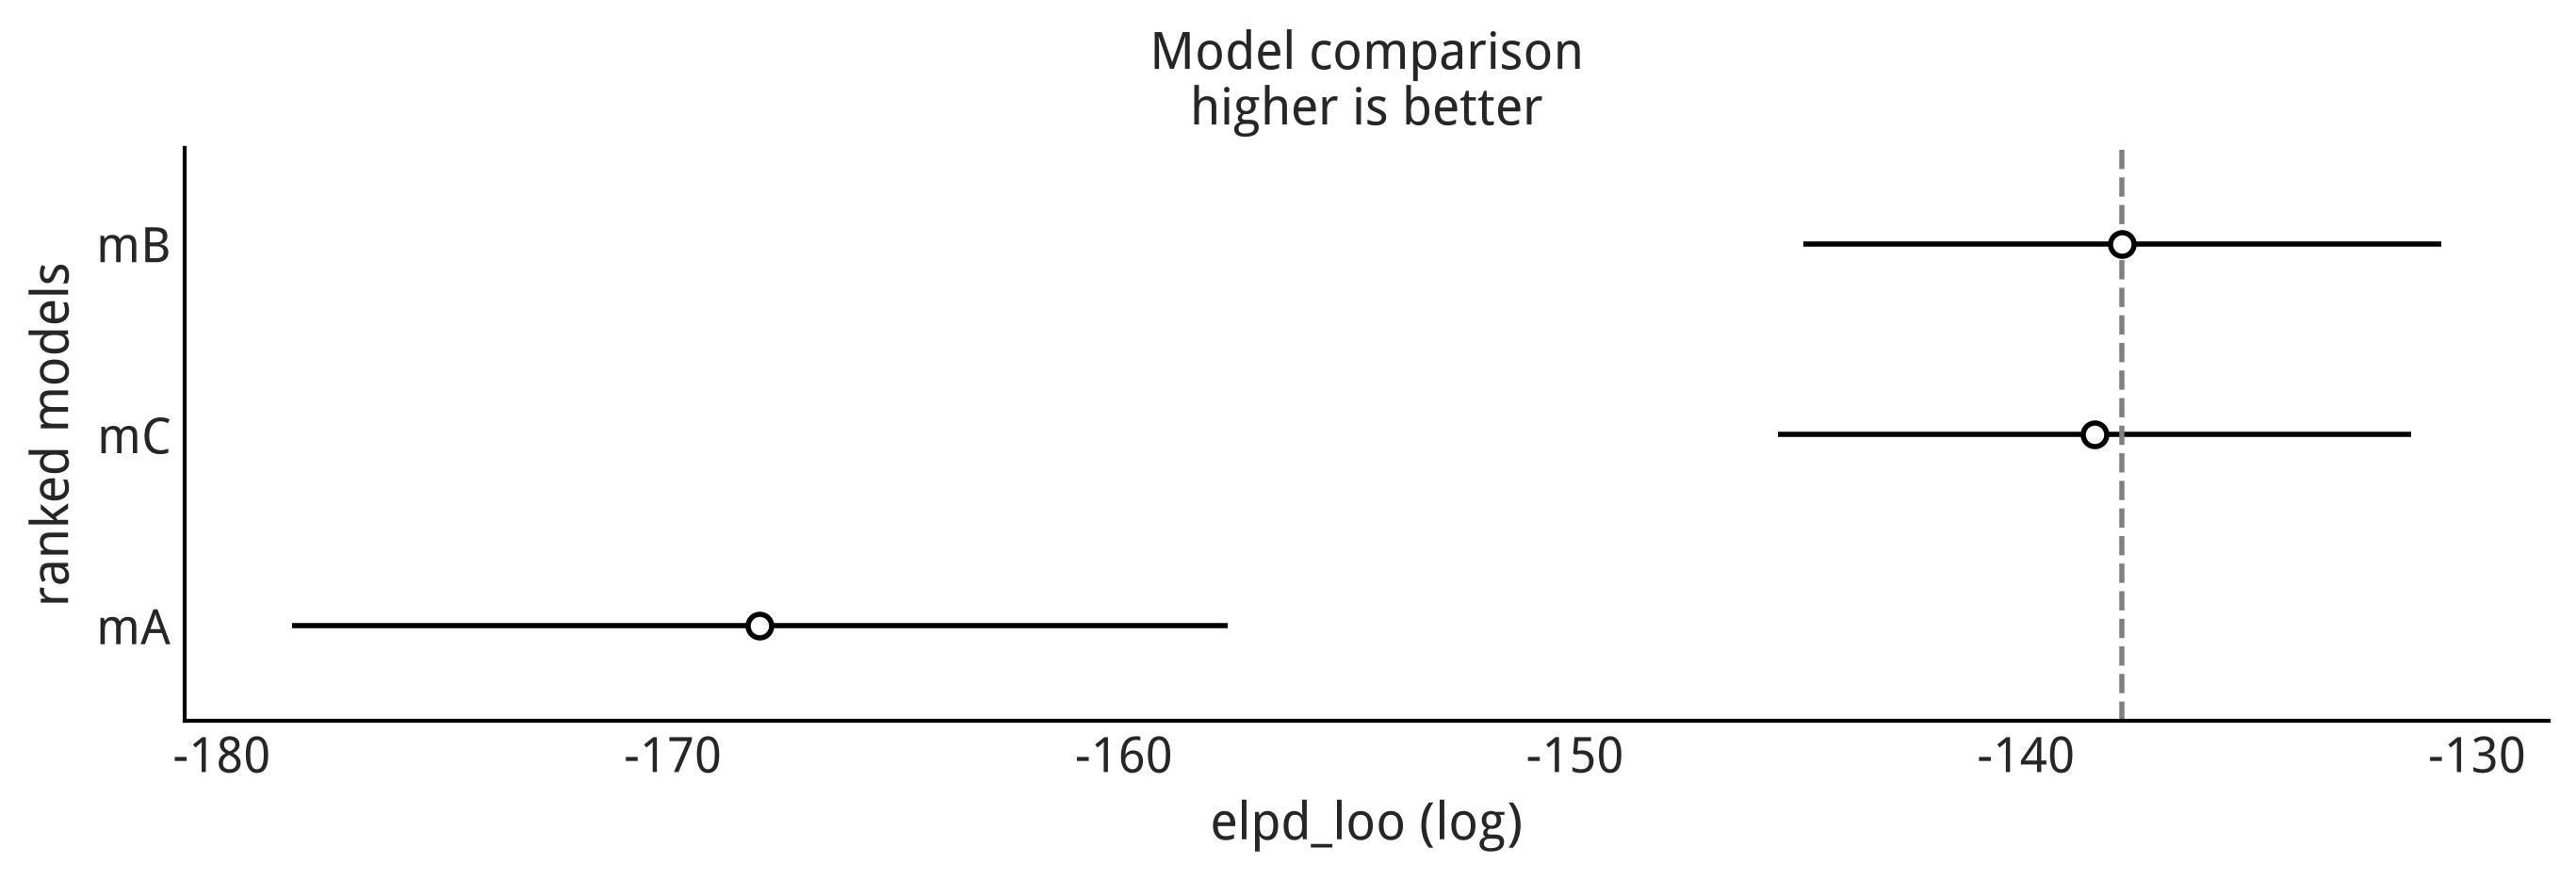

In [30]:
az.plot_compare(cmp, figsize=(9, 3))
plt.savefig("img/chp02/compare_dummy.png")



从上表和上图可以看到,模型 `mA` 排名最低,和另外两个模型明显拉开了差距。下面我们重点讨论
另外两个模型,因为它们之间的差异更微妙。`mB` 预测精度最高,但和 `mC` 相比差距可以忽略不计。
经验法则是:LOO 差值(`elpd_diff`)小于 4 就算是小差异。这两个模型的区别在于:`mB` 的均值固定
为 0,而 `mC` 的均值有自己的先验分布。LOO 会惩罚这种额外增加的先验灵活性——体现在 `mC` 的
`p_loo` 比 `mB` 更大,并且"黑点(未惩罚 ELPD)"与"空心点($\text{ELPD}_\text{LOO-CV}$)"
之间的距离,`mC` 也比 `mB` 更大。我们还能看到这两个模型的 `dse` 远小于它们各自的 `se`,说明
它们的预测高度相关。

鉴于 `mB` 和 `mC` 之间的差异如此之小,可以预期在略微不同的数据集上,这两个模型的排名可能会
互换,`mC` 变成排名最高的模型。权重的取值同样预计会发生变化(详见"模型平均"一节)。我们可以
换个随机种子多拟合几次模型,来验证这一点确实成立。

### 期望对数预测密度(逐点)

上一节我们为每个模型算出了一个全局性的 ELPD 数值,这样的比较把一个模型和数据都压缩成了单独
一个数字。但从前面的公式可以看到,LOO 是逐个观测值求和算出来的,因此我们同样可以做**局部**
比较。我们可以把单个观测值的 ELPD,理解为"模型预测这个特定观测值有多困难"的一个指标。

要基于逐点 ELPD 来比较模型,ArviZ 提供了 `az.plot_elpd(.)` 函数。下图展示了模型 `mA`、`mB`
和 `mC` 两两之间的比较。正值表示该观测点被第一个模型解析得比第二个模型更好。比如在第一幅图
(`mA - mB`)中,观测点 49 和 72 被模型 `mA` 解析得比模型 `mB` 更好,而观测点 75 和 95 则
恰好相反。可以看到前两幅图 `mA - mB` 和 `mA - mC` 非常相似,原因是模型 `mB` 和模型 `mC`
本身就彼此非常相似。下下图显示,观测点 34、49、72、75、82 正是最"极端"的 5 个观测值。


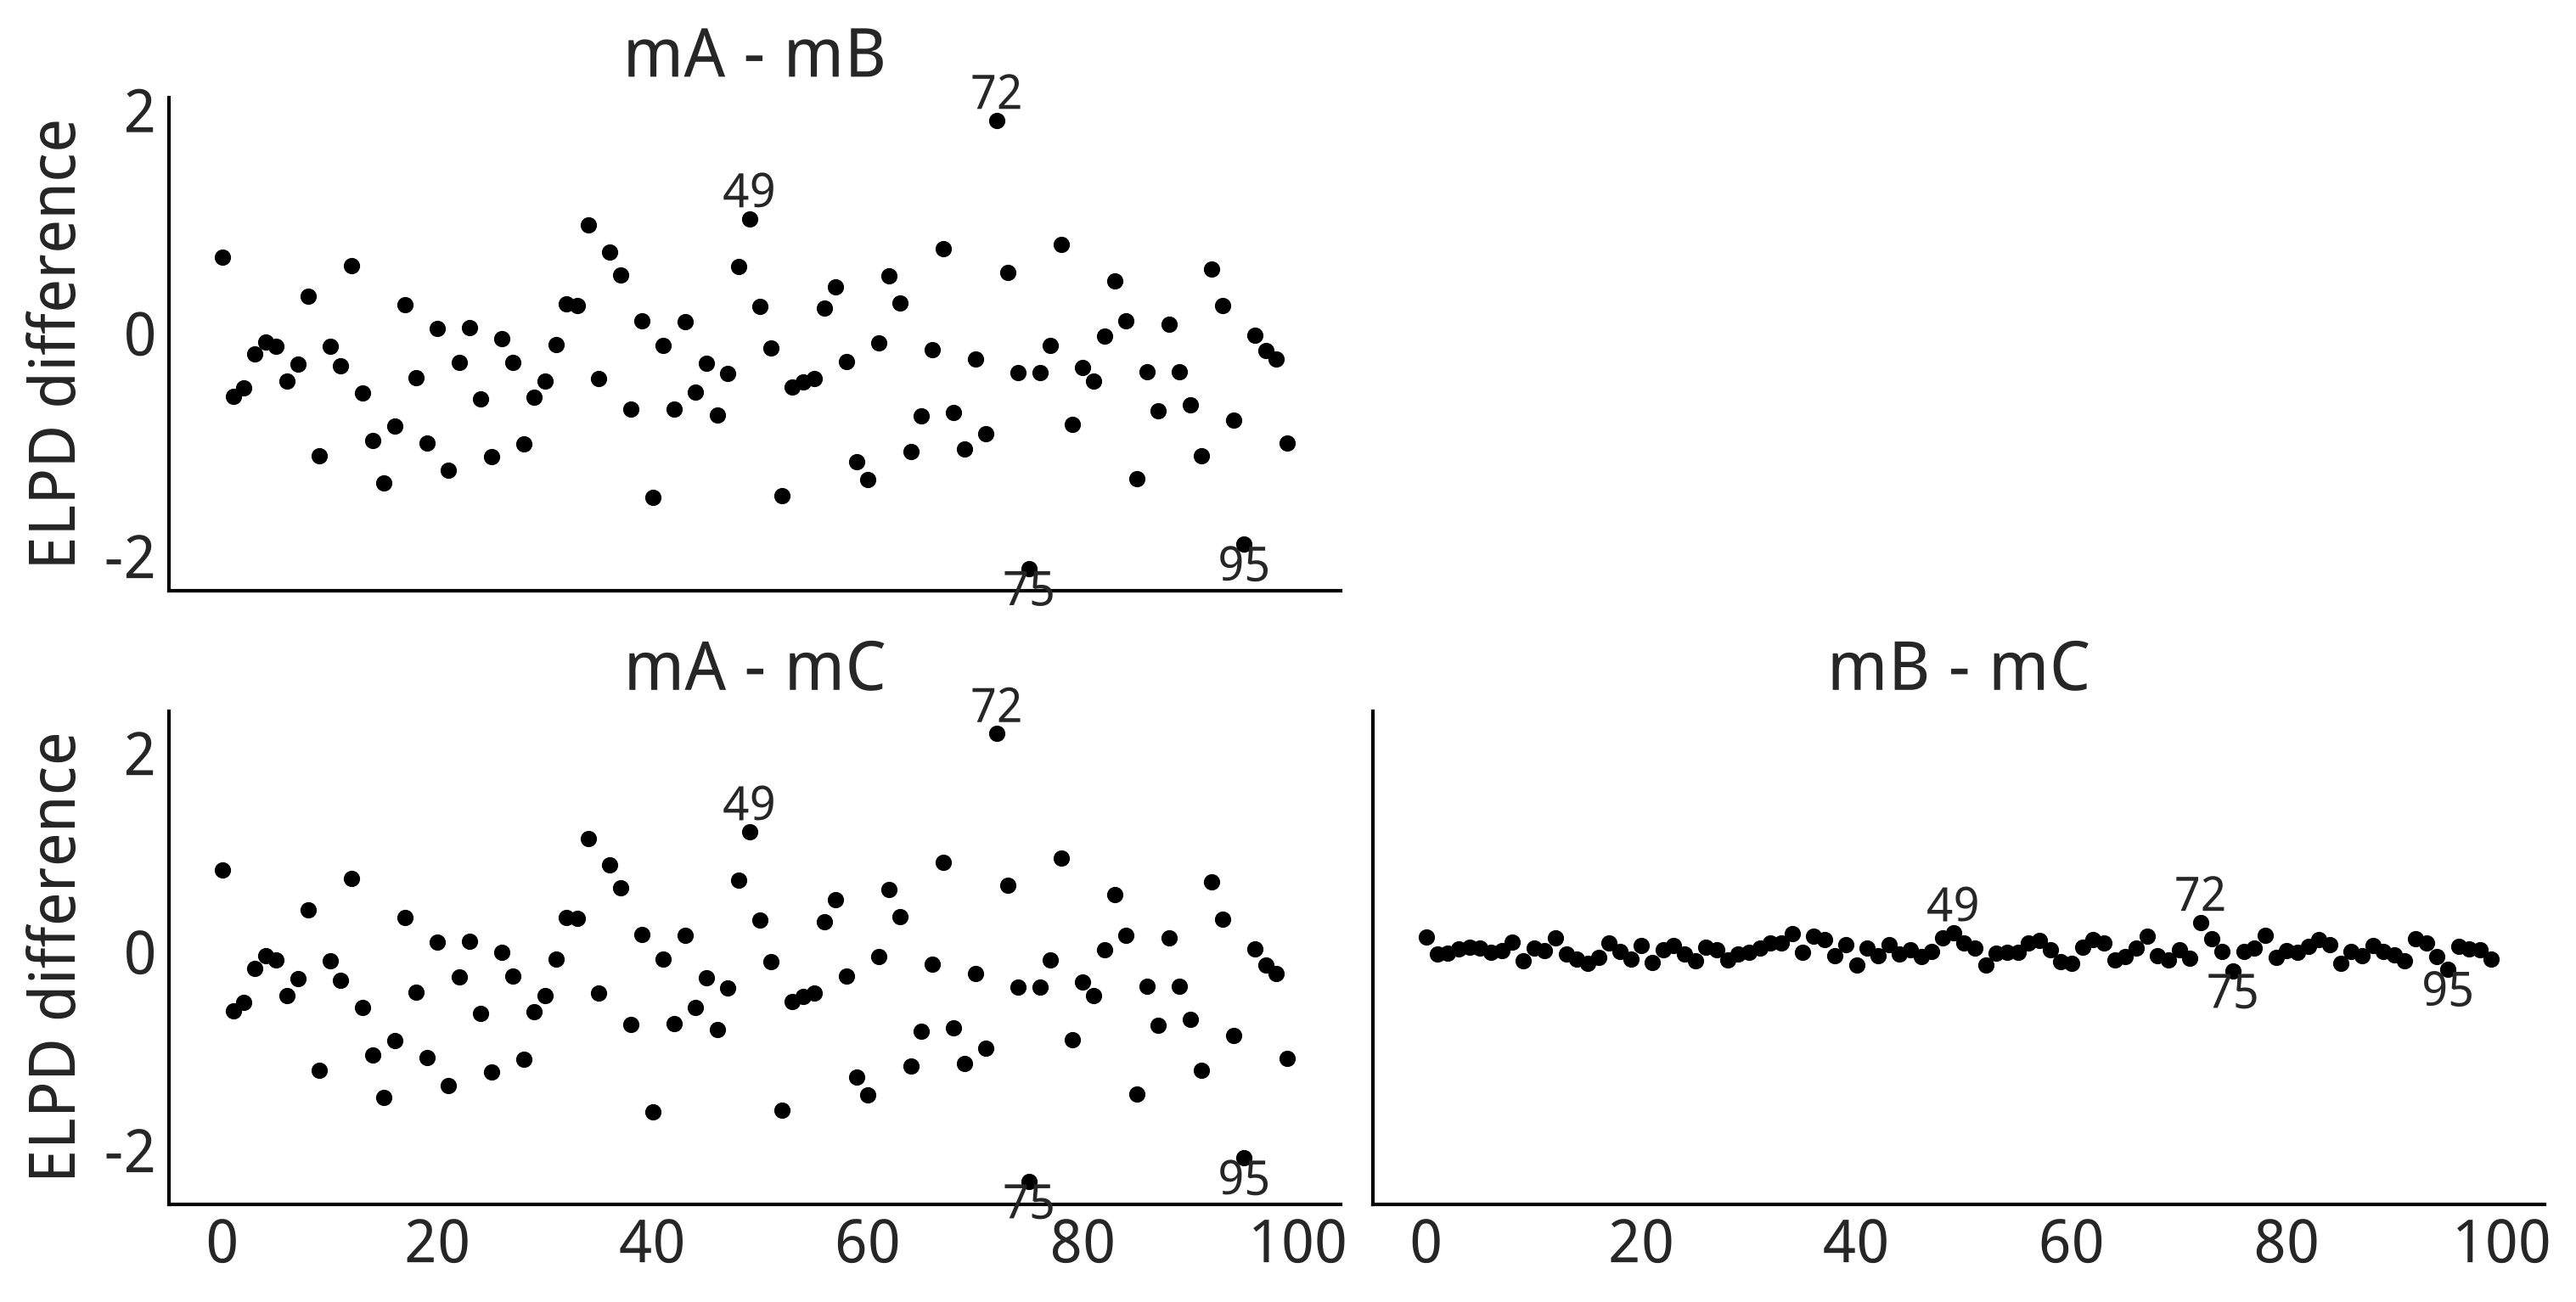

In [31]:
az.plot_elpd(idatas_cmp, figsize=(10, 5), plot_kwargs={"marker":"."}, threshold=2);
plt.savefig("img/chp02/elpd_dummy.png")



### Pareto 形状参数

前面提到过,LOO 是用来近似 $\text{ELPD}_\text{LOO-CV}$ 的。这个近似过程涉及对一个 Pareto
分布的估计,主要目的是获得更稳健的估计;这个计算过程的一个副产品,是该 Pareto 分布的参数
$\hat \kappa$ 可以用来检测**高影响力观测值**——也就是说,当这些观测值被排除时,会对预测
分布产生很大影响。一般来说,$\hat \kappa$ 值越高,越可能说明数据或模型存在问题,尤其是当
$\hat \kappa > 0.7$ 时。这种情况下的建议做法包括:

- 使用矩匹配(moment matching)方法 [^17]。通过一些额外计算,可以把 MCMC 后验抽样转换成
  更可靠的重要性采样估计。
- 对有问题的观测值执行精确的留一交叉验证,或者改用 k 折交叉验证。
- 换一个对异常观测更稳健的模型。

只要出现至少一个 $\hat \kappa > 0.7$ 的值,调用 `az.loo(.)` 或 `az.compare(.)` 就会给出
警告。下表(前面比较表格)中的 `warning` 列全部是 `False`,因为算出的所有 $\hat \kappa$ 值
都 $< 0.7$——我们可以从下图自行验证这一点。图中我们标注了 $\hat \kappa > 0.09$ 的观测点,
0.09 只是我们随便选的一个数字,你也可以换其他截断值试试看。对比下图与上一张逐点 ELPD 图可以
发现,$\hat \kappa$ 最高的观测点,不一定是 ELPD 最高(或最低)的观测点。


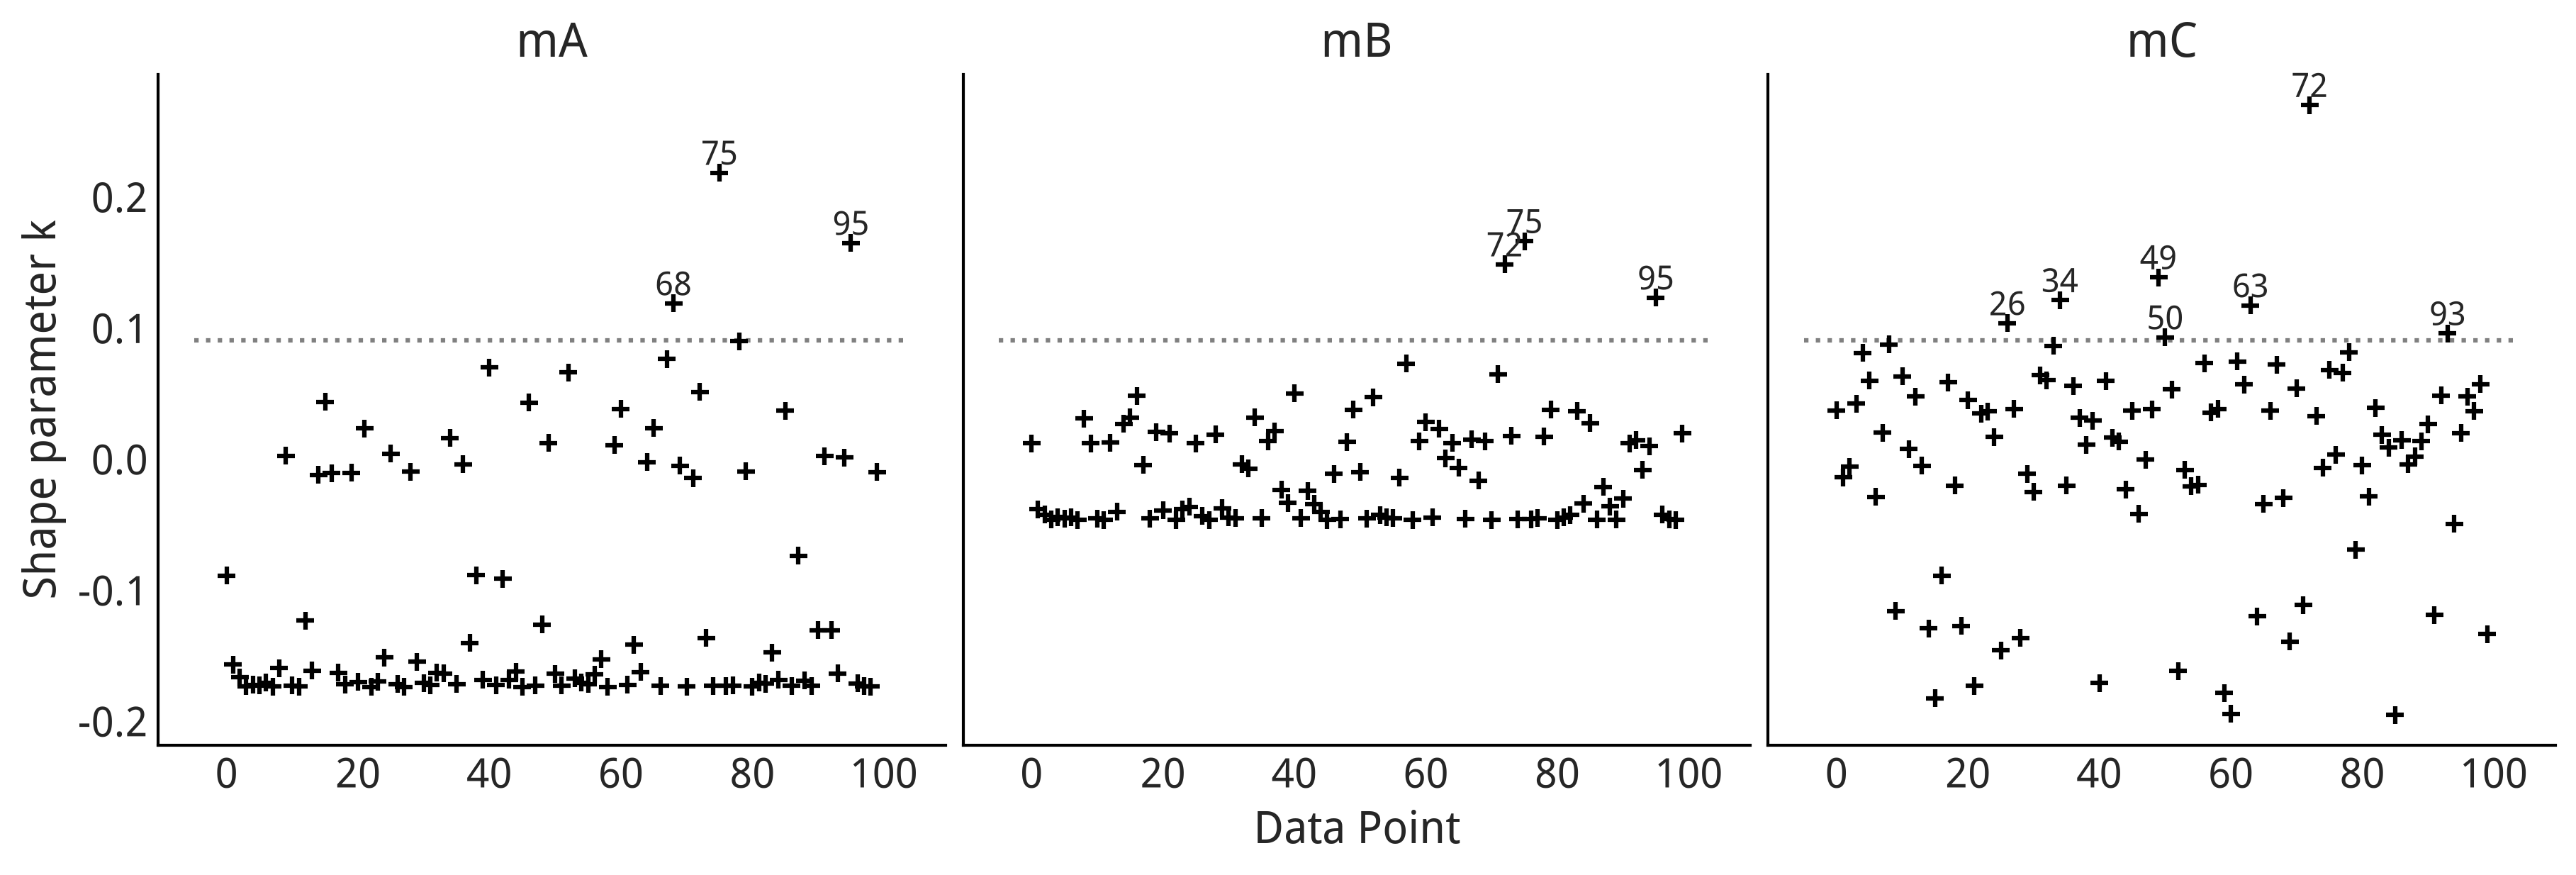

In [32]:
_, axes = plt.subplots(1, 3, figsize=(12, 4), sharey=True)
for idx, (model, ax) in enumerate(zip(("mA", "mB", "mC"), axes)):
    loo_ = az.loo(idatas_cmp[model], pointwise=True)
    az.plot_khat(loo_, ax=ax, threshold=0.09, show_hlines=True, hlines_kwargs={"hlines":0.09, "ls":"--"})
    ax.set_title(model)
    if idx:
        axes[idx].set_ylabel("")
    if not idx % 2:
        axes[idx].set_xlabel("")

plt.savefig("img/chp02/loo_k_dummy.png")


findfont: Failed to find font weight bold, now using 400.


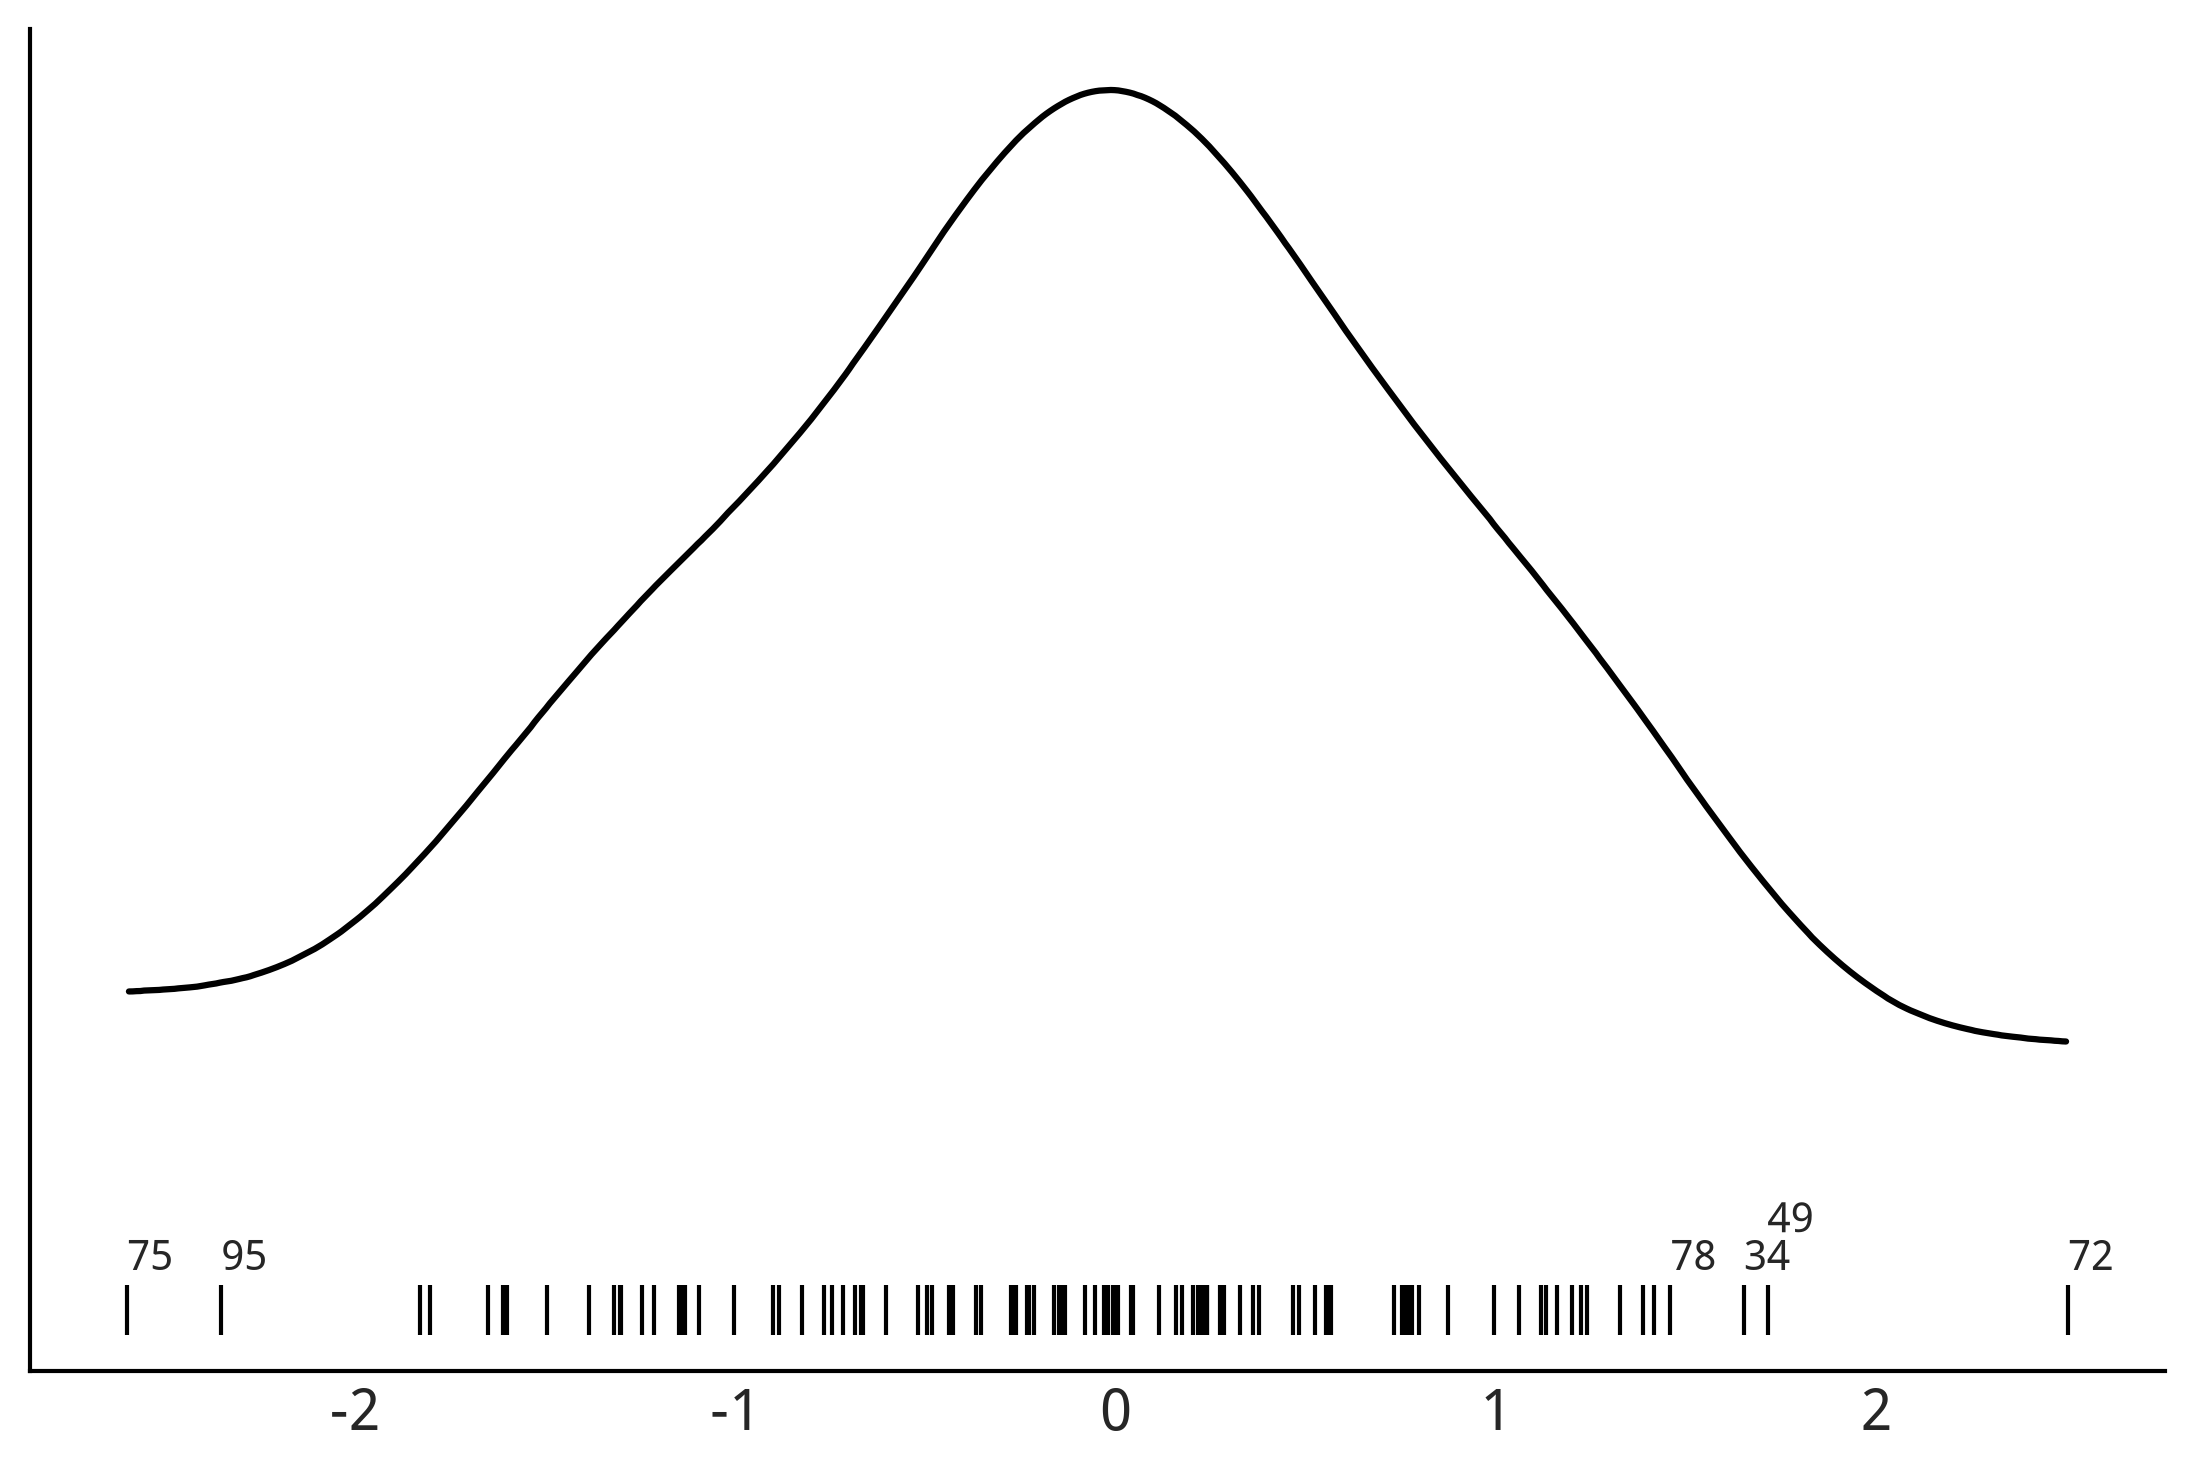

In [33]:
az.plot_kde(y_obs, rug=True)
plt.yticks([])
for da, loc in zip([34, 49, 72, 75, 95], [-0.065, -0.05, -0.065, -0.065, -0.065]):
    plt.text(y_obs[da], loc, f"{da}")

plt.text(y_obs[78], loc, "78", fontweight='bold');
plt.savefig("img/chp02/elpd_and_khat.png")



### 当 Pareto $\hat \kappa$ 较大时如何解读 p_loo

前面说过,p_loo 可以粗略地理解为模型的估计有效参数个数。不过对 $\hat \kappa$ 值较大的模型,
我们还能从中读出一些额外信息。如果 $\hat \kappa > 0.7$,那么把 p_loo 和实际参数个数 $p$
做对比,可以提供一些额外线索:

- 如果 $p\_loo \ll p$,模型很可能被误设了。通常在后验预测检验中也会看到问题——后验预测
  样本与观测值匹配得很差。
- 如果 $p\_loo < p$,且 $p$ 相对观测数量而言比较大(比如 $p > \frac{N}{5}$,$N$ 是观测总
  数),这通常说明模型过于灵活,或者先验信息量不足,导致很难预测被留出的那个观测值。
- 如果 $p\_loo > p$,模型同样可能存在严重的误设。如果参数个数 $p \ll N$,后验预测检验也
  很可能已经暴露出问题;但如果 $p$ 相对观测数而言较大(比如 $p > \frac{N}{5}$),后验预测
  检验就有可能看不出问题。

针对模型误设,可以尝试的一些启发式修复方式包括:为模型增加更多结构(比如加入非线性成分);
换一个不同的似然,比如用过离散(overdispersed)的负二项分布代替泊松分布;或者使用混合似然。

### LOO-PIT

正如我们在"期望对数预测密度"和"Pareto 形状参数"两节中看到的,模型比较、尤其是 LOO,不仅
可以用来判断"某个模型比另一个更好",也可以帮助我们更好地理解模型。随着模型复杂度提高,仅仅
看数学定义或实现代码,会越来越难以理解模型本身。因此,借助 LOO 或其他工具(比如后验预测
检验)来比较模型,能帮助我们更好地理解它们。

对后验预测检验的一个批评是:我们把数据用了两次——一次用来拟合模型,一次用来批判模型。
LOO-PIT 图正是为了回应这个担忧而设计的。它的核心思路是:用 LOO 作为交叉验证的一种快速、
可靠的近似,从而避免重复使用数据。"PIT"这部分,指的是概率积分变换(Probability Integral
Transform)[^19]——这是一种一维变换,如果用任意连续随机变量自身的 CDF 对其做变换,就能得到
一个 $\mathcal{U}(0, 1)$ 分布。在 LOO-PIT 中我们并不知道真实的 CDF,而是用经验 CDF 来近似
它。抛开这些数学细节不谈,划重点的结论是:对一个校准良好的模型,我们应该期望得到一个近似
均匀的分布。如果你有种似曾相识的感觉,不用担心,你没有特异功能,这也不是"母体故障"——这
听起来耳熟,是因为这其实正是我们在"理解你的预测"一节中,借助 `az.plot_bpv(idata,
kind="u_value")` 讨论过的同一个想法。

LOO-PIT 是通过比较观测数据 $y$ 和后验预测数据 $\tilde y$ 得到的,逐点比较:

$$
p_i = P(\tilde y_i \leq y_i \mid y_{-i})
$$

直观地说,LOO-PIT 计算的是:在去掉第 $i$ 个观测之后,后验预测数据 $\tilde y_i$ 小于观测值
$y_i$ 的概率。因此 `az.plot_bpv(idata, kind="u_value")` 和 LOO-PIT 的区别在于:后者近似
地避免了数据被使用两次,但两幅图的整体解读方式是一样的。

下图展示了模型 `mA`、`mB` 和 `mC` 的 LOO-PIT。可以看到,从模型 `mA` 的视角看,在取值较低的
区域观测数据比预期更多,而在取值较高的区域观测数据比预期更少——也就是说这个模型是有偏的。
相比之下,模型 `mB` 和 `mC` 看起来校准得相当好。


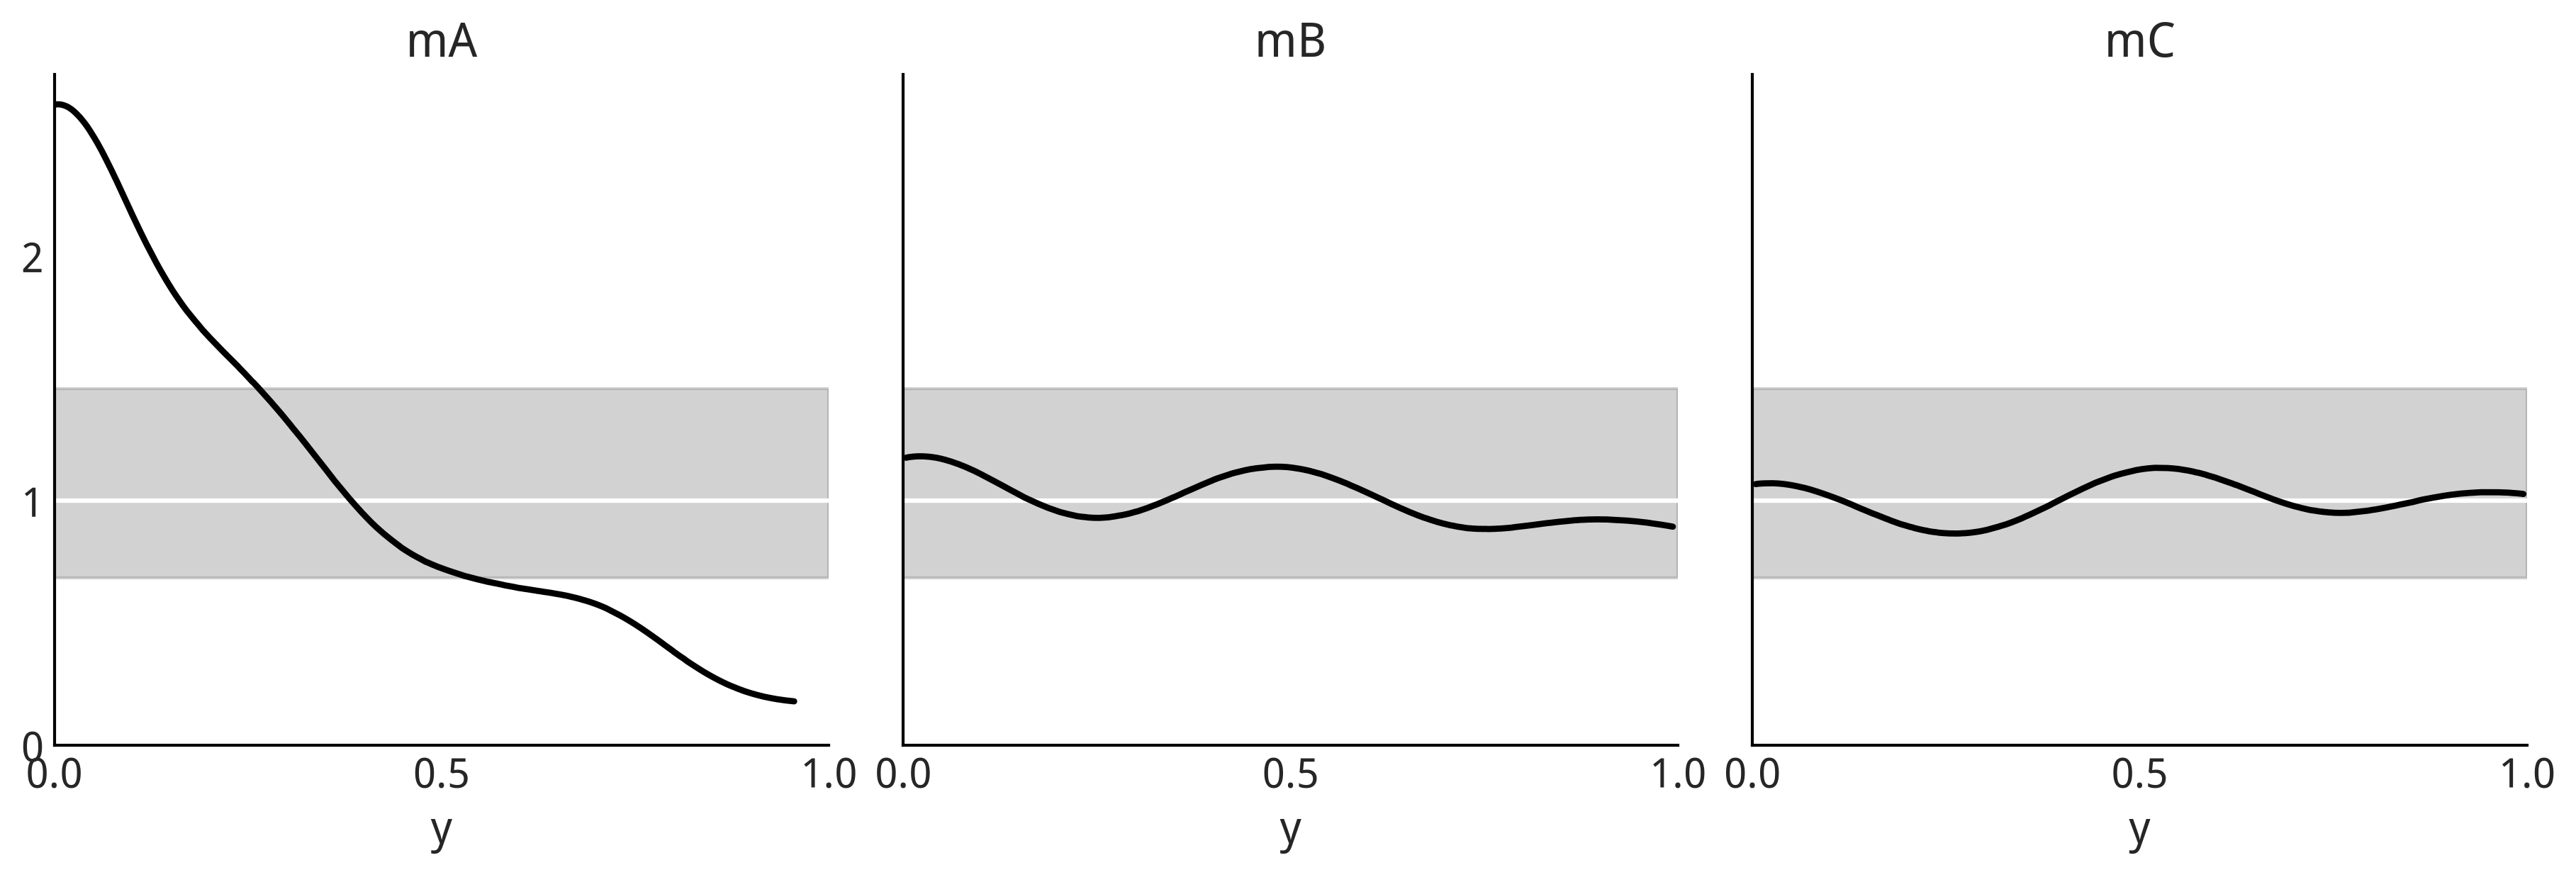

In [34]:
_, axes = plt.subplots(1, 3, figsize=(12, 4), sharey=True)
for model, ax in zip(("mA", "mB", "mC"), axes):
    az.plot_loo_pit(idatas_cmp[model], y="y", legend=False, use_hdi=True, ax=ax)
    ax.set_title(model)
    ax.set_xticks([0, 0.5, 1])
    ax.set_yticks([0, 1, 2])

plt.savefig("img/chp02/loo_pit_dummy.png")



### 模型平均

模型平均可以这样理解:既然我们对参数的不确定性采取贝叶斯的态度,那么对模型本身的不确定性,
同样也应该采取贝叶斯的态度。如果我们无法绝对确定某一个模型就是"真正的"模型(通常我们确实
无法确定),那么就应该以某种方式,把这种不确定性纳入分析。纳入模型不确定性的一种方式,是对
所有考虑过的模型做加权平均,给那些看起来更能解释或预测数据的模型分配更高的权重。

一种"自然"的加权方式,是按各模型的边际似然来加权,这被称为贝叶斯模型平均(Bayesian Model
Averaging)。这个想法在理论上很吸引人,但实践中存在问题(详见"边际似然"相关章节)。另一种
方案,是用 LOO 的取值来估计每个模型的权重,公式如下:

$$
w_i = \frac {e^{-\Delta_i }} {\sum_j^k e^{-\Delta_j }}
$$

其中 $\Delta_i$ 是第 $i$ 个模型的 LOO 值与最高 LOO 值之间的差(假设使用的是对数尺度,这也是
ArviZ 的默认设置)。

这种方法被称为**伪贝叶斯模型平均(pseudo Bayesian model averaging)**,或者类 Akaike
权重法 [^20],是一种从 LOO 出发、启发式地计算每个模型(在给定这一组模型的前提下)相对概率
的方法 [^21]。分母只是一个归一化项,确保权重加起来等于 1。上式给出的方案简单好用,但一个
主要的缺陷是:它没有考虑 LOO 计算本身的不确定性。我们可以在高斯近似下计算标准误,并相应地
修改上式,或者采用更稳健的做法,比如贝叶斯自助法(Bayesian Bootstrapping)。

另一种模型平均的方式,是对预测分布做**堆叠(stacking)**。核心思路是把多个模型组合成一个
元模型(meta-model),使元模型与"真实"生成模型之间的散度最小。在对数评分规则下,这等价于
计算:

$$
\max_{w} \frac{1}{n} \sum_{i=1}^{n}log\sum_{j=1}^{k} w_j p(y_i \mid y_{-i}, M_j)
$$

其中 $n$ 是数据点个数,$k$ 是模型个数。为了让解存在,我们约束 $w_j \ge 0$ 且
$\sum_{j=1}^{k} w_j = 1$。$p(y_i \mid y_{-i}, M_j)$ 是模型 $M_j$ 的留一预测分布。前面已经
说过,直接计算它可能代价过高,因此实践中我们可以用 LOO 来近似。

堆叠比伪贝叶斯模型平均拥有更有趣的性质。从二者的定义就能看出这一点:上面加权公式只是把每个
模型独立算出的权重做归一化;而堆叠公式中的权重,是通过最大化**组合**对数得分算出来的——也
就是说,即便各个模型是像伪贝叶斯模型平均那样被独立拟合的,权重的计算却会把所有模型放在一起
考虑。这也解释了为什么模型 `mB` 会得到权重 1、而 `mC` 得到权重 0(参见前面的比较表格),
尽管它们其实是非常相似的模型。为什么权重不是各占 0.5 左右呢?原因在于:按照堆叠的逻辑,一旦
`mB` 已经被纳入我们比较的模型集合,`mC` 就不再提供新的信息——换句话说,再把它包含进来纯属
多余。

> **中文版现代化说明**: 原书使用的 `pm.sample_posterior_predictive_w(.)` 已不在当前 PyMC 的
> 公共 API 中。现代做法是先让每个模型分别生成后验预测样本,再显式构造一个有限混合:按照
> `az.compare(., method="stacking")` 给出的权重选择模型,随后从该模型的后验预测样本中抽取一行。
> 这样既不依赖已移除的函数,也把“如何混合”这一统计操作写得更清楚。堆叠权重是为优化组合模型的
> 样本外预测表现而求得的系数,一般不应解释为模型为真的后验概率。


In [35]:
stacking_cmp = az.compare(idatas_cmp, method="stacking")
model_names = stacking_cmp.index.to_numpy()
stacking_weights = stacking_cmp["weight"].to_numpy(dtype=float, copy=True)
stacking_weights /= stacking_weights.sum()

rng = np.random.default_rng(RANDOM_SEED)
selected_models = rng.choice(
    model_names, size=PREDICTIVE_SAMPLES, p=stacking_weights)
ensemble_blocks = []
for model_name in model_names:
    block_size = int(np.count_nonzero(selected_models == model_name))
    if block_size == 0:
        continue
    predictions = az.extract(
        idatas_cmp[model_name], group="posterior_predictive",
        combined=True)["y"]
    prediction_array = np.moveaxis(
        predictions.values, predictions.get_axis_num("sample"), 0)
    draw_indices = rng.choice(
        prediction_array.shape[0], size=block_size, replace=True)
    ensemble_blocks.append(prediction_array[draw_indices])

stacked_posterior_predictive = np.concatenate(ensemble_blocks, axis=0)
rng.shuffle(stacked_posterior_predictive, axis=0)
stacked_posterior_predictive.shape


(1000, 100)


## 习题

**2E1.** 用你自己的话说说,先验预测检验和后验预测检验的主要区别是什么?这两种经验性评估
方式,分别和先验预测分布、后验预测分布的公式是怎么联系起来的?

**2E2.** 用你自己的话解释:ESS、$\hat R$ 和 MCSE。重点说明这些量分别在衡量什么,以及它们
分别能够识别出 MCMC 的哪些潜在问题。

**2E3.** ArviZ 内置了几个预先计算好的 `InferenceData` 对象。我们来加载一个基于贝叶斯统计
经典案例——"八校问题"(eight schools model)生成的 `InferenceData` 对象,其中包含先验样本、
先验预测样本和后验样本。可以用 `az.load_arviz_data("centered_eight")` 加载它。用 ArviZ:
1. 列出该 `InferenceData` 对象中所有可用的组(groups)。
2. 找出链数和后验样本总数。
3. 画出后验分布。
4. 画出后验预测分布。
5. 计算参数的估计均值和最高密度区间。

**2E4.** 加载 `az.load_arviz_data("non_centered_eight")`,它是上一题"centered_eight"模型
的重参数化版本。用 ArviZ 通过以下方式评估两个模型的 MCMC 采样收敛情况:自相关图、秩图、
$\hat R$ 值。重点关注 mu 和 tau 两个参数。这三种不同诊断分别显示了什么?把它们和
"centered_eight" 模型的结果做对比,这三种诊断在"哪个模型更好"这个问题上意见是否一致?哪个
模型的收敛诊断更好?

**2E5.** `InferenceData` 对象可以存储与采样算法相关的统计量,它们位于 `sample_stats` 组中,
包括发散信息(`diverging`):
1. 统计 "centered_eight" 和 "non_centered_eight" 模型各自的发散次数。
2. 用 `az.plot_parallel` 找出发散主要集中在参数空间的哪些区域。

**2E6.** 在 GitHub 仓库中,我们提供了一个包含泊松模型和负二项模型的 `InferenceData` 对象,
两个模型拟合的是同一份数据集。用 `az.from_netcdf(.)` 加载它们,然后用 ArviZ 回答以下问题:
1. 哪个模型对数据的拟合更好?用 `az.compare(.)` 和 `az.plot_compare(.)`。
2. 解释为什么一个模型比另一个拟合得更好。用 `az.plot_ppc(.)` 和 `az.plot_loo_pit(.)`。
3. 从逐点 ELPD 的角度比较两个模型,找出(绝对)差异最大的 5 个观测值,哪个模型对它们的预测
   更好?哪个模型的 p_loo 更接近实际参数个数?能解释原因吗?提示:泊松模型只有一个参数同时
   控制均值和方差,而负二项分布有两个参数。
4. 用 $\hat \kappa$ 值诊断 LOO,对这个具体案例,是否有理由担心 LOO 的精度?

**2E7.** 复现前面的后验预测检验多例子图,但把 `az.plot_bpv(.)` 换成
`az.plot_loo_pit(ecdf=True)`。解读结果。提示:使用 `ecdf=True` 选项时,得到的不是 LOO-PIT
的 KDE,而是 LOO-PIT 经验累积分布函数(ECDF)与均匀分布 CDF 之差的图。理想情况下这个差值
应该处处为零。

**2E8.** 用你自己的话解释,为什么 MCMC 后验估计方法需要收敛诊断。特别是把它和"共轭先验"
一节中介绍的、不需要这类诊断的共轭方法做对比。这两种推断方法有什么本质区别?

**2E9.** 访问 ArviZ 绘图图库(plot gallery)。你能找到哪些本章没有覆盖的诊断方法?根据文档,
这些诊断评估的是什么?

**2E10.** 列举贝叶斯工作流每个阶段中有用的图和数值量。解释它们是如何工作的、评估的是什么。
可以自由使用本章或 ArviZ 文档中见到的任何内容:
1. 先验选择。
2. MCMC 采样。
3. 后验预测。

**2M11.** 我们想为一个有 $N$ 支球队的足球联赛建模。像往常一样,先从更简单的版本开始:只
考虑单支球队。假设比分服从泊松分布,参数为得分率 $\mu$。我们选用先验 $\text{Gamma}(0.5,
0.00001)$,因为它有时被推荐为一种"客观"先验。

```python
with pm.Model() as model:
    μ = pm.Gamma("μ", 0.5, 0.00001)
    score = pm.Poisson("score", μ)
    trace = pm.sample_prior_predictive()
```

1. 生成并画出先验预测分布,在你看来它合理吗?
2. 运用你的体育常识来改进先验选择。
3. 假设现在你想建模的不是足球而是篮球,你能想出一个合理的先验吗?在模型中定义这个先验,
   生成先验预测分布来验证你的直觉。提示:你可以像上面代码那样用 rate 和 shape 参数化 Gamma
   分布,也可以改用均值和标准差来参数化。

**2M12.** 在第 1 章的 Metropolis-Hastings 代码里,修改 `can_sd` 的值并运行 Metropolis
采样器,尝试 0.2 和 1 这样的取值。
1. 用 ArviZ 比较采样结果,借助自相关图、迹图和 ESS,解释观察到的差异。
2. 修改代码,让你能得到不止一条独立的链。用 ArviZ 计算秩图和 $\hat R$。

**2M13.** 用 `np.random.binomial(n=1, p=0.5, size=200)` 生成一个随机样本,用 Beta-Binomial
模型拟合它。分别用 `pm.sample(., step=pm.Metropolis())`(Metropolis-Hastings 采样器)和
`pm.sample(.)`(标准采样器)采样,从 ESS、$\hat R$、自相关、迹图和秩图等方面比较结果。查看
PyMC 的日志信息,系统自动选用的是哪种采样器?你对这个采样器相对 Metropolis-Hastings 的表现
有什么结论?

**2M14.** 自己构造一个存在收敛问题的合成后验示例,称之为 `bad_chains3`。
1. 解释你生成的这个合成后验为什么是"差"的。在真实建模场景中,我们不希望看到它的哪些特征?
2. 对 `bad_chains3` 运行本书对 `bad_chains0` 和 `bad_chains1` 做过的同一套诊断。把你的结果
   和书中的结果对比,解释异同。
3. 这些诊断结果,是否让你重新思考了"为什么 `bad_chains3` 是差链"这个问题?

**2H15.** 用 `np.random.binomial(n=1, p=0.5, size=200)` 生成一个随机样本,用 Beta-Binomial
模型拟合它。
1. 检查 LOO-PIT 是否近似均匀。
2. 调整先验,使模型拟合变差,让 LOO-PIT 在取值接近零处偏低、接近一处偏高。为你的先验选择
   做出论证。
3. 调整先验,使模型拟合变差,让 LOO-PIT 在取值接近零处偏高、接近一处偏低。为你的先验选择
   做出论证。
4. 调整先验,使模型拟合变差,让 LOO-PIT 在取值接近 0.5 处偏高、接近零和一处偏低。你能做到
   吗?解释原因。

**2H16.** 用 PyMC 写一个正态似然的模型,分别用下面的随机样本作为数据、下面的先验作为均值的
先验,似然中的标准差固定为 1:
1. 从 $\mathcal{N}(0,1)$ 抽取的大小为 200 的随机样本,先验 $\mathcal{N}(0,20)$。
2. 从 $\mathcal{N}(0,1)$ 抽取的大小为 2 的随机样本,先验 $\mathcal{N}(0,20)$。
3. 从 $\mathcal{N}(0,1)$ 抽取的大小为 200 的随机样本,先验 $\mathcal{N}(20, 1)$。
4. 从 $\mathcal{U}(0,1)$ 抽取的大小为 200 的随机样本,先验 $\mathcal{N}(10, 20)$。
5. 从 $\mathcal{HN}(0,1)$ 抽取的大小为 200 的随机样本,先验 $\mathcal{N}(10,20)$。

用本书对 `bad_chains0` 和 `bad_chains1` 做过的同一套诊断评估收敛情况,并与书中结果对比,
解释异同。

**2H17.** 本章的四个小节——先验预测检验、后验预测检验、数值推断诊断、模型比较——分别对应
贝叶斯工作流中的一个具体步骤。用你自己的话解释每个步骤的目的是什么,以及如果省略这个步骤会
缺失什么。每个步骤分别告诉了我们关于统计模型的什么信息?

## 脚注

[^1]: 参见 <https://www.countbayesie.com/blog/2015/2/18/bayes-theorem-with-lego>。

[^2]: 这里我们省略了与数据采集本身相关的任务,但实验设计的重要性丝毫不亚于统计分析的其他
    方面,详见第 9 章。

[^3]: <https://arviz-devs.github.io/arviz/>

[^4]: 该例子改编自 <https://mc-stan.org/users/documentation/case-studies/golf.html> 以及
    <https://docs.pymc.io/notebooks/putting_workflow.html>。

[^5]: 该例子改编自参考文献 Gelman2020。

[^6]: 逻辑回归模型的细节见第 3 章。

[^7]: 后验预测检验是一个非常通用的思路,这些图并不是唯一的选择,只是 ArviZ 提供的部分选项。

[^8]: 除非你意识到需要重新收集数据,但那是另一个故事了。

[^9]: 可以试试 <https://www.timeanddate.com/sun/ecuador/quito>。

[^10]: 不要和均值 MCSE 的标准差混淆。

[^11]: 目前最常用、最有效的贝叶斯推断采样方法大多是 HMC 的变体,包括 PyMC 对连续变量默认
    使用的方法。

[^12]: 一个除零点外处处为零、在零点取值无穷大的函数。

[^13]: 对像序贯蒙特卡洛(SMC)这样的采样器而言,增加抽样数量同时也会增加粒子数,因此确实
    可能带来更好的收敛效果。

[^14]: 严格来说离散模型应该使用"概率"而不是"密度",但这个区分在实践中很快会变得繁琐。

[^15]: 在非贝叶斯语境下,$\boldsymbol{\theta}$ 是一个点估计,例如通过最大化似然得到。

[^16]: 我们同时也会计算后验预测分布的样本,用来计算 LOO-PIT。

[^17]: 在本书写作时,这个方法尚未在 ArviZ 中实现,但你阅读本书时它可能已经可用。

[^18]: 可参考案例研究 <https://avehtari.github.io/modelselection/roaches.html>。

[^19]: 关于概率积分变换更深入的介绍,请参阅相关章节。

[^20]: 赤池信息量准则(AIC)是泛化误差的一种估计量,在频率学派统计中很常用,但其假设通常
    不适合直接套用在贝叶斯模型上。

[^21]: 这个公式对 WAIC 等其他信息准则同样适用。
